# 🏭 Production Agents: Observability, Reliability & Cost — From Demo to Dependable

> **What you'll learn:** what changes when an agent leaves the demo and serves real users; how to **trace** agent runs, LLM calls and tool calls with **OpenTelemetry's GenAI semantic conventions** and with **MLflow tracing**, with PII redacted; how to compute **SLO metrics** (success, p50/p95 latency, time to first token, steps, tool errors, escalations, cost per task) from traces; how to make tools reliable with **timeouts, retries with jittered backoff for transient errors only, idempotency keys, circuit breakers and fallbacks**, proven by fault-injection experiments; how to **checkpoint and resume** a long-running agent after its worker process is killed without paying a refund twice; how to **serve** agents with FastAPI job queues, cancellation, **Server-Sent Events** progress and backpressure; how to **control cost** with token accounting, cascades, caching and budgets; and how to **version, roll out and operate** agents with eval gates, canaries, alerts and runbooks. You finish by production-izing a support agent and measuring a naive service against a hardened one under injected failures and load.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Agent Security and Guardrails](07_Agent_Security_and_Guardrails.ipynb) · [Agent Evaluation and Benchmarks](06_Agent_Evaluation_and_Benchmarks.ipynb) · [FastAPI](../10_Model_Serving/01_FastAPI.ipynb) (uvicorn in a background process, SSE, load tests) · [MLflow](../09_MLOps/01_MLflow.ipynb) (tracing basics, aliases) |
| **Tested with** | Python 3.12 · openai 3.13 · opentelemetry-sdk 1.44 (semantic-conventions 0.65b0) · mlflow 3.16 · langgraph 1.2 + langgraph-checkpoint-sqlite 3.1 · fastapi 0.141 · uvicorn 0.52 · httpx 0.28 · tenacity 9.1 · sentence-transformers 6.0 · local **gpt-oss-20b** served by llama.cpp |
| **Interview relevance** | ⭐⭐⭐ Very high — "what changes from demo to production?", "what do you trace?", "retries vs idempotency?", "how do you make a long-running agent resumable?", "how do you control agent cost?", "how do you roll out a new prompt safely?", "p95 tripled overnight — debug it", "design an agent service for 10,000 users" |

**🧩 This notebook completes the Agentic AI module (8 notebooks):**

| # | Notebook | Focus |
|---|---|---|
| 01 | [Agent Architectures and Workflow Patterns](01_Agent_Architectures_and_Workflow_Patterns.ipynb) | which pattern to build, measured |
| 02 | [Context Engineering and Agent Memory](02_Context_Engineering_and_Agent_Memory.ipynb) | context budgets, compaction, memory types |
| 03 | [Code Agents, Browser Agents and Computer Use](03_Code_Agents_Browser_Agents_and_Computer_Use.ipynb) | agent–computer interfaces, sandboxes |
| 04 | [Multi-Agent Systems and A2A](04_Multi_Agent_Systems_and_A2A.ipynb) | when many agents help, the A2A protocol |
| 05 | [Agent Frameworks Compared](05_Agent_Frameworks_Compared.ipynb) | the same agent in five frameworks |
| 06 | [Agent Evaluation and Benchmarks](06_Agent_Evaluation_and_Benchmarks.ipynb) | trajectories, pass^k, user simulators |
| 07 | [Agent Security and Guardrails](07_Agent_Security_and_Guardrails.ipynb) | injection, least privilege, red-teaming |
| 08 | **Production Agents: Observability, Reliability, Cost** (you are here) | tracing, durable execution, serving, cost control, operations |

## 🤔 What Is a Production Agent?

Think of the difference between **cooking dinner for friends** and **running a restaurant**.

- At home, if the oven is slow you wait, if you burn the sauce you start again, and nobody counts what the ingredients cost.
- A restaurant serves hundreds of people at once. It needs to know **what happened to every order** (tickets), promise a **waiting time** (service levels), cope when a supplier doesn't deliver (fallbacks), never **charge a customer twice** when the card machine hangs (idempotency), keep food costs under control (budgets), change the menu without poisoning anyone (rollouts), and have a plan when the kitchen catches fire (runbooks).

A **demo agent** is dinner at home: one user, the happy path, a human watching. A **production agent** is the restaurant. The model and the prompt barely change. What changes is everything *around* the loop:

```
             ┌───────────────────────── production wrapper ─────────────────────────┐
 request ──► │ admission control ─► job queue ─► worker ─► AGENT LOOP ─► result/SSE │ ──► user
             │   (backpressure)      (durable)      │      LLM ⇄ tools              │
             │                                     ├── tracing: spans for every step │
             │                                     ├── resilient tool executor       │
             │                                     │   (timeouts, retries, breaker,  │
             │                                     │    idempotency keys)            │
             │                                     ├── budgets (tokens, $, steps)    │
             │                                     └── checkpoints (resume on crash) │
             └──────────── metrics ► SLOs ► alerts ► runbooks ► humans ─────────────┘
```

Four words you will see all the time:
- **Observability** — being able to answer "what happened in *this* run, and why?" from data the system emits: **traces** (a tree of timed **spans**, one per step), **metrics** (numbers over time) and **logs**.
- **Reliability** — the agent does the right thing even when parts of the system fail: slow tools, flaky APIs, crashed workers, a provider outage.
- **SLO** (Service Level Objective) — a target for a measured indicator, for example "95% of support tasks finish within 20 seconds".
- **Cost engineering** — knowing the tokens and dollars each task uses, and reducing them without losing quality.

## 🎯 Why It Matters

- **Agents fail in quiet ways.** A run that loops for 40 steps, pays a refund twice after a timeout, or answers without the data it needed usually raises **no exception**. Without traces and metrics you don't even know it happened.
- **Failures multiply.** An agent makes many calls per task. If each tool call fails 2% of the time, a task with 5 calls hits at least one failure about 10% of the time. Resilience is not optional.
- **Costs are per step, not per request.** Each step re-sends the growing history, so one runaway task can cost as much as a hundred normal ones. Budgets and routing are engineering work, not finance work.
- **Long tasks meet real infrastructure.** Deploys restart workers, laptops sleep, pods get evicted. Work that takes minutes must survive a crash and **resume without repeating side effects**.
- **In interviews** for AI/agent engineer roles this is where senior candidates stand out: "what do you trace?", "retries vs idempotency?", "how do you make it resumable?", "how do you stream progress?", "how do you cut cost 50%?", "how do you roll out a new prompt?", and debugging and design scenarios. Strong answers quote **measurements**. Every technique in this notebook is measured on a real agent over real τ-bench retail data, with a local LLM.

## ✅ By the End You Can

- [ ] Explain what changes from an agent demo to production, and apply a production-readiness checklist
- [ ] Instrument an agent with OpenTelemetry GenAI spans and MLflow tracing, redact PII, and compute SLO metrics (success, p50/p95 latency, TTFT, steps, tool error rate, escalation rate, cost per task) from traces
- [ ] Build a resilient tool executor (timeouts, jittered exponential backoff for transient errors only, circuit breaker, idempotency keys) and prove it with fault-injection experiments
- [ ] Checkpoint a long-running LangGraph agent in SQLite, kill its worker mid-run, resume, and prove no side effect happened twice
- [ ] Serve agents with FastAPI: job queue, status, cancellation, SSE progress, concurrency limits and backpressure, and load-test them
- [ ] Control cost with token accounting, cascades, response caching and budgets, and roll out changes with eval gates, canaries, alerts and runbooks

## 📋 Table of Contents

1. [From Demo to Production](#1.-From-Demo-to-Production-🟢)
2. [Observability: Tracing Agents With OpenTelemetry and MLflow](#2.-Observability:-Tracing-Agents-With-OpenTelemetry-and-MLflow-🟡)
3. [Metrics and SLOs Computed From Traces](#3.-Metrics-and-SLOs-Computed-From-Traces-🟡)
4. [Reliability: Timeouts, Retries, Idempotency, Circuit Breakers, Fallbacks](#4.-Reliability:-Timeouts,-Retries,-Idempotency,-Circuit-Breakers,-Fallbacks-🔴)
5. [Durable Execution: Checkpoint, Crash, Resume](#5.-Durable-Execution:-Checkpoint,-Crash,-Resume-🔴)
6. [Serving Agents: Job Queues, SSE Progress, Backpressure](#6.-Serving-Agents:-Job-Queues,-SSE-Progress,-Backpressure-🔴)
7. [Cost Engineering: Accounting, Cascades, Caching, Budgets](#7.-Cost-Engineering:-Accounting,-Cascades,-Caching,-Budgets-🟡)
8. [Versioning and Rollout: Configs, Eval Gates, Shadow, Canary, A/B](#8.-Versioning-and-Rollout:-Configs,-Eval-Gates,-Shadow,-Canary,-A/B-🟡)
9. [Operations: Escalation, Alerts, Runbooks, Retention](#9.-Operations:-Escalation,-Alerts,-Runbooks,-Retention-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Production-ize-the-Support-Agent) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cells below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

**The LLM.** The agent talks to an **OpenAI-compatible** chat server configured by three environment variables:

| Variable | Default | Meaning |
|---|---|---|
| `LLM_BASE_URL` | `http://127.0.0.1:8080/v1` | where the server listens |
| `LLM_MODEL` | `gpt-oss-20b` | model id to request |
| `LLM_API_KEY` | `local` | API key (local servers ignore it) |

To run the model we used: `brew install llama.cpp`, then `llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja` (or `llama-server -m /path/to/gpt-oss-20b-MXFP4.gguf --port 8080 --jinja`). The same code runs against **Ollama** (`LLM_BASE_URL=http://localhost:11434/v1`), **LM Studio** (`http://localhost:1234/v1`) or **OpenAI** (`https://api.openai.com/v1` plus your key and a model id). gpt-oss is a *reasoning* model: its hidden reasoning counts toward `max_tokens`, so budgets stay ≥ 1024, and we send `reasoning_effort: "low"` through llama.cpp's chat-template option.

**Budget, run time and the response cache.** The server is shared (4 slots, 16,384 tokens each), so the notebook sends at most **2 LLM requests at a time**. Every call **streams** (so we can measure time to first token) and every reply is stored in a small SQLite cache, `_outputs/prod_agents/llm_cache.sqlite`, keyed by the exact request. A request that was already answered is **replayed**: the cached reply comes back after **sleeping for the latency measured when the call was really made**, so latency numbers, queueing and timeouts behave the same on a re-run. Replayed calls are counted separately and shown in tables. A **fresh run** makes about **125 LLM calls** (the two services in Section 6 and the Mini Project share the same cache, so a request one of them already sent is replayed for the others) and takes roughly **6–8 minutes** on our shared server; a re-run replays them in about **6 minutes**, since the replay deliberately keeps real timing. The last cell of the Mini Project prints the exact count for your run. Delete the cache file or set `LLM_CACHE=0` for fresh calls. Results will move a little, because LLM output is not deterministic; every conclusion is computed from *this run's* data.

**Data.** τ-bench retail (Yao et al. 2024, **MIT licence**): 500 users and 1,000 orders with items, prices, payment methods and tracking numbers, downloaded once (about 2.1 MB) from the τ-bench GitHub repository at a pinned commit into `_outputs/prod_agents/tau_bench_retail/`. We also use the small embedding model `sentence-transformers/all-MiniLM-L6-v2` (~90 MB) in Section 7.

**No real side effects.** "Refunds" are rows in a local SQLite **payments ledger**, "escalations" are rows in a tickets table. Nothing leaves this laptop.

**One code package, three processes.** The FastAPI service (Section 6 and the Mini Project) and the crash-and-resume worker (Section 5) run as **separate processes**, and they must use exactly the same agent code as the notebook. So the reusable parts are saved into a tiny package, `_outputs/prod_agents/supportkit/`, with Jupyter's `%%writefile` cell magic and then imported. Those cells show normal, highlighted Python; running one just writes the file. This mirrors a real project: notebooks for exploration, importable modules for services.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "openai>=1.99" "opentelemetry-sdk>=1.30" "opentelemetry-semantic-conventions>=0.51b0" "mlflow>=3.4" "langgraph>=1.0" "langgraph-checkpoint-sqlite>=2.0" "fastapi[standard]>=0.135" "uvicorn>=0.35" "httpx>=0.28" "tenacity>=9" "sentence-transformers>=3" statsmodels pandas matplotlib

import os

os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"                 # MLflow prints a hint for AI coding assistants on import otherwise
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")      # avoids a fork warning from the Rust tokenizers
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")    # keep download bars out of saved outputs

import asyncio
import hashlib
import importlib
import importlib.metadata as md
import json
import math
import random
import re
import signal
import socket
import sqlite3
import subprocess
import sys
import textwrap
import time
import urllib.request
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass, field
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PACKAGES = ["openai", "opentelemetry-sdk", "opentelemetry-semantic-conventions", "mlflow", "langgraph", "langgraph-checkpoint-sqlite",
            "fastapi", "uvicorn", "httpx", "tenacity"]
print(f"Python {sys.version.split()[0]} | " + " | ".join(f"{p} {md.version(p)}" for p in PACKAGES))

NOTEBOOK_START = time.perf_counter()
SEED = 42
OUTPUT_DIR = Path("_outputs") / "prod_agents"                  # everything we write goes here (ignored by git)
KIT_DIR = OUTPUT_DIR / "supportkit"
KIT_DIR.mkdir(parents=True, exist_ok=True)
(KIT_DIR / "__init__.py").write_text('"""supportkit: the production support agent used by the notebook, the service and the worker."""\n')
if str(OUTPUT_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(OUTPUT_DIR.resolve()))              # so `import supportkit` works in this kernel
HOME = str(Path.home())
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 60)


def rel(path):
    """Print paths relative to the notebook folder, never as absolute home-directory paths."""
    try:
        return Path(path).resolve().relative_to(Path.cwd().resolve()).as_posix()
    except ValueError:
        return str(path).replace(HOME, "~")


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None / ...), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return

    def close(a, b):
        if isinstance(b, bool) or isinstance(a, bool) or isinstance(b, str):
            return a == b
        if isinstance(b, float) or isinstance(a, float):
            return isinstance(a, (int, float)) and isinstance(b, (int, float)) and math.isclose(a, b, rel_tol=1e-6, abs_tol=1e-9)
        if isinstance(b, dict):
            return isinstance(a, dict) and a.keys() == b.keys() and all(close(a[k], b[k]) for k in b)
        if isinstance(b, (list, tuple)):
            return isinstance(a, (list, tuple)) and len(a) == len(b) and all(close(x, y) for x, y in zip(a, b))
        return a == b

    assert close(got, expected), f"❌ {name}: not quite (got {str(got)[:300]!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | openai 3.13.0 | opentelemetry-sdk 1.44.0 | opentelemetry-semantic-conventions 0.65b0 | mlflow 3.16.0 | langgraph 1.2.11 | langgraph-checkpoint-sqlite 3.1.1 | fastapi 0.141.1 | uvicorn 0.52.4 | httpx 0.28.1 | tenacity 9.1.4


**The LLM client** (`supportkit/llm.py`). One `chat()` method used everywhere. It:
- **streams** every call and records **time to first chunk** (the first piece of reasoning, text or tool call), total latency, prompt/completion tokens, and how many prompt tokens the server reused from its **prompt (KV) cache**;
- limits requests **in flight** with a semaphore and tracks the peak (the service uses this as backpressure against the LLM server);
- caches and replays replies as described above (the cache is SQLite so the notebook and the server process can share it safely).

In [2]:
%%writefile _outputs/prod_agents/supportkit/llm.py
"""An async, streaming, cached LLM client for any OpenAI-compatible server."""
from __future__ import annotations

import asyncio
import hashlib
import json
import os
import sqlite3
import time
from dataclasses import asdict, dataclass

from openai import AsyncOpenAI

LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "http://127.0.0.1:8080/v1")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-oss-20b")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "local")


@dataclass
class LLMReply:
    message: dict                  # assistant message, ready to append to the conversation
    finish_reason: str             # "stop", "tool_calls" or "length"
    prompt_tokens: int
    completion_tokens: int         # includes hidden reasoning tokens
    cached_prompt_tokens: int      # prompt tokens the server reused from its prompt (KV) cache
    ttft_s: float                  # time to the first streamed chunk with reasoning, text or a tool call
    latency_s: float               # time to the last chunk
    replayed: bool = False         # True when served from our response cache

    @property
    def text(self) -> str:
        return self.message.get("content") or ""


class ResponseCache:
    """request key → reply record, in SQLite so several processes can share it."""

    def __init__(self, path):
        self.path = str(path)
        with sqlite3.connect(self.path, timeout=30) as con:
            con.execute("PRAGMA journal_mode=WAL")
            con.execute("CREATE TABLE IF NOT EXISTS replies (key TEXT PRIMARY KEY, record TEXT NOT NULL)")

    def get(self, key):
        with sqlite3.connect(self.path, timeout=30) as con:
            row = con.execute("SELECT record FROM replies WHERE key = ?", (key,)).fetchone()
        return json.loads(row[0]) if row else None

    def put(self, key, record):
        with sqlite3.connect(self.path, timeout=30) as con:
            con.execute("INSERT OR REPLACE INTO replies VALUES (?, ?)", (key, json.dumps(record)))


class LLMClient:
    def __init__(self, cache_path=None, max_concurrency=2, use_cache=True, base_url=LLM_BASE_URL, model=LLM_MODEL,
                 api_key=LLM_API_KEY, timeout_s=180.0):
        self.base_url, self.model, self.timeout_s = base_url, model, timeout_s
        self.client = AsyncOpenAI(base_url=base_url, api_key=api_key, timeout=timeout_s, max_retries=2)
        self.cache = ResponseCache(cache_path) if (cache_path and use_cache) else None
        self.slots = asyncio.Semaphore(max_concurrency)
        self.max_concurrency = max_concurrency
        self.real_calls = self.replayed_calls = self.in_flight = self.peak_in_flight = 0

    def key(self, request, effort, tag):
        blob = json.dumps([self.base_url, request, effort, tag], sort_keys=True, default=str)
        return hashlib.sha256(blob.encode()).hexdigest()

    async def chat(self, messages, *, tools=None, max_tokens=1024, effort="low", temperature=0.0, tag="") -> LLMReply:
        request = {"model": self.model, "messages": messages, "max_tokens": max_tokens, "temperature": temperature}
        if tools:
            request["tools"] = tools
        key = self.key(request, effort, tag)
        async with self.slots:                                  # at most max_concurrency requests in flight
            self.in_flight += 1
            self.peak_in_flight = max(self.peak_in_flight, self.in_flight)
            try:
                record = self.cache.get(key) if self.cache else None
                if record is not None:
                    await asyncio.sleep(record["latency_s"])     # replay with the latency measured on the real call
                    self.replayed_calls += 1
                    return LLMReply(**record, replayed=True)
                reply = await self._stream(request, effort)
                self.real_calls += 1
                if self.cache:
                    self.cache.put(key, {k: v for k, v in asdict(reply).items() if k != "replayed"})
                return reply
            finally:
                self.in_flight -= 1

    async def _stream(self, request, effort) -> LLMReply:
        start = time.perf_counter()
        first = None
        content, calls, finish, usage, timings = "", {}, None, None, {}
        stream = await self.client.chat.completions.create(
            **request, stream=True, stream_options={"include_usage": True},
            extra_body={"chat_template_kwargs": {"reasoning_effort": effort}})
        async for chunk in stream:
            timings = (chunk.model_extra or {}).get("timings") or timings
            if chunk.usage:
                usage = chunk.usage
            if not chunk.choices:
                continue
            choice = chunk.choices[0]
            delta = choice.delta
            reasoning = (delta.model_extra or {}).get("reasoning_content")
            if first is None and (delta.content or reasoning or delta.tool_calls):
                first = time.perf_counter() - start
            content += delta.content or ""
            for tc in delta.tool_calls or []:
                entry = calls.setdefault(tc.index, {"id": None, "name": "", "arguments": ""})
                entry["id"] = tc.id or entry["id"]
                if tc.function is not None:
                    entry["name"] += tc.function.name or ""
                    entry["arguments"] += tc.function.arguments or ""
            finish = choice.finish_reason or finish
        latency = time.perf_counter() - start
        message = {"role": "assistant", "content": content or None}
        if calls:
            message["tool_calls"] = [{"id": c["id"] or f"call_{i}", "type": "function",
                                      "function": {"name": c["name"], "arguments": c["arguments"]}} for i, c in sorted(calls.items())]
        cached = timings.get("cache_n")
        if cached is None and usage is not None and usage.prompt_tokens_details is not None:
            cached = usage.prompt_tokens_details.cached_tokens
        return LLMReply(message=message, finish_reason=finish or "stop", prompt_tokens=usage.prompt_tokens if usage else 0,
                        completion_tokens=usage.completion_tokens if usage else 0, cached_prompt_tokens=int(cached or 0),
                        ttft_s=round(first if first is not None else latency, 3), latency_s=round(latency, 3))

Overwriting _outputs/prod_agents/supportkit/llm.py


Now connect. If no server is running, the next cell stops with instructions instead of pretending.

In [3]:
from openai import OpenAI

import supportkit.llm as kit_llm

LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "http://127.0.0.1:8080/v1")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-oss-20b")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "local")
client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY, timeout=180, max_retries=2)

try:
    served = [m.id for m in client.models.list().data]
    print(f"✅ LLM server at {LLM_BASE_URL} — models: {served}")
except Exception as exc:
    raise RuntimeError(
        f"This notebook needs an OpenAI-compatible LLM server at {LLM_BASE_URL} ({type(exc).__name__}).\n"
        "Start one locally:  brew install llama.cpp  &&  llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja\n"
        "…or point LLM_BASE_URL / LLM_MODEL / LLM_API_KEY at Ollama, LM Studio, or a hosted provider."
    ) from exc

USE_CACHE = os.environ.get("LLM_CACHE", "1") == "1"
CACHE_PATH = OUTPUT_DIR / "llm_cache.sqlite"
llm = kit_llm.LLMClient(cache_path=CACHE_PATH, max_concurrency=2, use_cache=USE_CACHE)
LLM_CLIENTS = [llm]                                            # every client we create is counted at the end

hello = await llm.chat([{"role": "user", "content": "Reply with exactly one word: ready"}], max_tokens=256)
print(f"reply {hello.text!r} | finish={hello.finish_reason} | tokens {hello.prompt_tokens} in / {hello.completion_tokens} out | "
      f"time to first chunk {hello.ttft_s:.2f}s | total {hello.latency_s:.2f}s | replayed={hello.replayed}")

✅ LLM server at http://127.0.0.1:8080/v1 — models: ['gpt-oss-20b']


reply 'ready' | finish=stop | tokens 74 in / 21 out | time to first chunk 0.52s | total 1.09s | replayed=True


## 1. From Demo to Production 🟢

The same agent, two very different jobs:

| Dimension | Demo | Production |
|---|---|---|
| users | one, watching | thousands at once, most not watching |
| success | "it worked when I tried" | a measured **SLO**, e.g. ≥ 90% of tasks succeed, p95 ≤ 30 s |
| failures | rare, you just rerun | constant background rate: timeouts, 429/503s, crashed workers, provider outages |
| side effects | none, or you undo them by hand | real money moves, so **exactly-once effects** matter |
| latency | seconds are fine | users need progress now; long tasks run in the background |
| cost | ignored | tokens × steps × users; budgets and alerts |
| change | edit the prompt and rerun | versioned configs, eval gates, canaries, rollback |
| compliance | nothing stored | PII in traces, retention limits, audit logs, deletion requests |

**The system under test.** A retail **support agent** over real τ-bench data. It answers order questions, and handles refund requests with a written policy: delivered orders can be refunded to the original payment method, refunds over $1,000 go to a human, other orders are denied. It has four tools; two of them have **side effects** (a refund in the payments ledger, a ticket for a human).

First, download the data (pinned commit, cached after the first run).

In [4]:
TAU_COMMIT = "59a200c6d575d595120f1cb70fea53cef0632f6b"       # pinned: the data never changes under us
DATA_DIR = OUTPUT_DIR / "tau_bench_retail"
DATA_DIR.mkdir(exist_ok=True)
for name, remote in {"orders.json": "tau_bench/envs/retail/data/orders.json", "users.json": "tau_bench/envs/retail/data/users.json",
                     "LICENSE": "LICENSE"}.items():
    if not (DATA_DIR / name).exists():
        urllib.request.urlretrieve(f"https://raw.githubusercontent.com/sierra-research/tau-bench/{TAU_COMMIT}/{remote}", DATA_DIR / name)
sizes = {name: (DATA_DIR / name).stat().st_size for name in ["orders.json", "users.json", "LICENSE"]}
print(f"τ-bench retail files in {rel(DATA_DIR)}: {sum(sizes.values()) / 1e6:.2f} MB → {sizes}")
print("licence:", (DATA_DIR / "LICENSE").read_text().splitlines()[0])

τ-bench retail files in _outputs/prod_agents/tau_bench_retail: 2.13 MB → {'orders.json': 1810945, 'users.json': 322932, 'LICENSE': 1063}
licence: MIT License


**The backend** (`supportkit/store.py`). SQLite holds the orders plus three tables the tools write to: the payments **ledger**, human **tickets**, and an **idempotency** table. Four design points matter for the rest of the notebook:

1. **Business rules live in code.** The refund policy is a function, not a sentence in a prompt.
2. **Business errors are results, infrastructure errors are exceptions.** "Order not found" or "policy says deny" come back as `{"error": ...}` for the model to read. A 503 or a timeout raises a `TransientToolError`, which the *executor* (not the model) should handle.
3. **The payments provider behaves like a real payments API:** a refund request is only **idempotent** if the caller sends an **idempotency key**. The ledger row and the idempotency record commit in **one transaction**.
4. **Fault injection is deterministic.** `FaultPlan(rate, seed)` decides from a hash of (seed, task, tool, arguments, n-th physical call) whether a call fails and how: `unavailable` (503 before anything happens), `lost_response` (for writes: the refund **was committed**, then the connection dropped), or `slow` (for reads: the reply takes 3 s). The same plan always injects the same faults, so experiments are repeatable.

In [5]:
%%writefile _outputs/prod_agents/supportkit/store.py
"""Local retail backend from τ-bench data: orders, a refund policy, a payments ledger, deterministic fault injection."""
from __future__ import annotations

import asyncio
import hashlib
import inspect
import json
import random
import sqlite3
import time
from collections import Counter, defaultdict
from dataclasses import dataclass

REFUND_LIMIT = 1000.00

SCHEMA = """
CREATE TABLE users(user_id TEXT PRIMARY KEY, first_name TEXT, last_name TEXT, email TEXT, zip TEXT);
CREATE TABLE payment_methods(payment_method_id TEXT, user_id TEXT, source TEXT);
CREATE TABLE orders(order_id TEXT PRIMARY KEY, user_id TEXT, status TEXT);
CREATE TABLE order_items(order_id TEXT, item_id TEXT, name TEXT, price REAL);
CREATE TABLE payments(order_id TEXT, transaction_type TEXT, amount REAL, payment_method_id TEXT);
CREATE TABLE fulfillments(order_id TEXT, tracking_id TEXT);
CREATE TABLE ledger(refund_id INTEGER PRIMARY KEY AUTOINCREMENT, order_id TEXT, item_ids TEXT, amount REAL,
                    payment_method_id TEXT, idempotency_key TEXT);
CREATE TABLE tickets(ticket_id INTEGER PRIMARY KEY AUTOINCREMENT, order_id TEXT, user_id TEXT, summary TEXT, idempotency_key TEXT);
CREATE TABLE idempotency(key TEXT PRIMARY KEY, request_hash TEXT NOT NULL, response TEXT NOT NULL);
"""


def canonical_json(obj) -> str:
    """Same data → same string, regardless of key order or spacing."""
    return json.dumps(obj, sort_keys=True, separators=(",", ":"), default=str)


def sha256(text: str) -> str:
    return hashlib.sha256(text.encode()).hexdigest()


def normalize_order_id(order_id) -> str:
    return "#" + str(order_id).strip().upper().lstrip("#")


def build_template_db(data_dir, db_path) -> dict:
    """Load τ-bench orders.json + users.json into a fresh SQLite file; return row counts."""
    from pathlib import Path
    Path(db_path).unlink(missing_ok=True)
    orders = json.loads((Path(data_dir) / "orders.json").read_text())
    users = json.loads((Path(data_dir) / "users.json").read_text())
    con = sqlite3.connect(db_path)
    con.executescript(SCHEMA)
    for uid, u in users.items():
        con.execute("INSERT INTO users VALUES (?,?,?,?,?)", (uid, u["name"]["first_name"], u["name"]["last_name"], u["email"], u["address"]["zip"]))
        con.executemany("INSERT INTO payment_methods VALUES (?,?,?)", [(pm, uid, v["source"]) for pm, v in u["payment_methods"].items()])
    for oid, o in orders.items():
        con.execute("INSERT INTO orders VALUES (?,?,?)", (oid, o["user_id"], o["status"]))
        con.executemany("INSERT INTO order_items VALUES (?,?,?,?)", [(oid, i["item_id"], i["name"], i["price"]) for i in o["items"]])
        con.executemany("INSERT INTO payments VALUES (?,?,?,?)", [(oid, p["transaction_type"], p["amount"], p["payment_method_id"]) for p in o["payment_history"]])
        con.executemany("INSERT INTO fulfillments VALUES (?,?)", [(oid, t) for f in o["fulfillments"] for t in f["tracking_id"]])
    con.commit()
    counts = {t: con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0] for t in ["users", "orders", "order_items", "payments", "fulfillments"]}
    con.close()
    return counts


# ── errors: infrastructure failures raise, business outcomes are returned ─────────────────────────────
class ToolError(Exception):
    transient = False
    error_type = "tool_error"


class TransientToolError(ToolError):
    """503s, dropped connections, timeouts: the same request may succeed if retried."""
    transient = True
    error_type = "unavailable"


class ToolTimeoutError(TransientToolError):
    error_type = "timeout"


class PermanentToolError(ToolError):
    """Retrying the same request cannot help (bad arguments, conflicting idempotency key)."""
    error_type = "invalid_request"


# ── clocks: real time for services, a fake clock for deterministic experiments ─────────────────────────
class RealClock:
    def now(self) -> float:
        return time.monotonic()

    async def sleep(self, seconds: float):
        await asyncio.sleep(seconds)

    async def wait_for(self, coro, timeout: float):
        try:
            return await asyncio.wait_for(coro, timeout)
        except TimeoutError as exc:
            raise ToolTimeoutError(f"no reply within {timeout:.2f}s") from exc


class FakeClock:
    """Nothing really waits: sleep() moves time forward instantly and records the delay. A call that 'took' longer
    than its timeout raises ToolTimeoutError when it returns, and time is set to the moment the caller gave up."""

    def __init__(self, start: float = 0.0):
        self.t, self.sleeps = start, []

    def now(self) -> float:
        return self.t

    async def sleep(self, seconds: float):
        self.sleeps.append(seconds)
        self.t += seconds

    async def wait_for(self, coro, timeout: float):
        start = self.t
        result = await coro
        if self.t - start > timeout:
            self.t = start + timeout
            raise ToolTimeoutError(f"no reply within {timeout:.2f}s")
        return result


# ── deterministic fault injection ──────────────────────────────────────────────────────────────────────
@dataclass(frozen=True)
class FaultPlan:
    rate: float = 0.0
    seed: int = 0
    slow_s: float = 3.0

    def draw(self, scope: str, tool: str, args: dict, n: int, write: bool):
        """Fault kind for the n-th physical call of (tool, args) in `scope`, or None. Same inputs → same answer."""
        digest = hashlib.sha256(f"{self.seed}|{scope}|{tool}|{canonical_json(args)}|{n}".encode()).digest()
        if int.from_bytes(digest[:8], "big") / 2**64 >= self.rate:
            return None
        kinds = ("unavailable", "lost_response") if write else ("unavailable", "slow")
        return kinds[digest[8] % 2]


def run_idempotent(con, key, request, write):
    """Run write(con) → response at most once per idempotency key, in ONE transaction with its idempotency record.
    Returns (response, replayed). Reusing a key with different parameters is a permanent error."""
    request_hash = sha256(canonical_json(request))
    with con:
        if key is not None:
            row = con.execute("SELECT request_hash, response FROM idempotency WHERE key = ?", (key,)).fetchone()
            if row is not None:
                if row[0] != request_hash:
                    raise PermanentToolError("idempotency key reused with different parameters")
                return json.loads(row[1]), True
        response = write(con)
        if key is not None:
            con.execute("INSERT INTO idempotency VALUES (?, ?, ?)", (key, request_hash, json.dumps(response)))
    return response, False


class PaymentsProvider:
    """Stands in for an external payments API. Like real ones, it is idempotent only when the caller sends a key."""

    def __init__(self, con):
        self.con, self.replays = con, 0

    def refund(self, order_id, item_ids, amount, payment_method_id, idempotency_key=None):
        request = {"op": "refund", "order_id": order_id, "item_ids": sorted(item_ids), "amount": amount, "payment_method_id": payment_method_id}

        def write(con):
            cur = con.execute("INSERT INTO ledger(order_id, item_ids, amount, payment_method_id, idempotency_key) VALUES (?,?,?,?,?)",
                              (order_id, json.dumps(sorted(item_ids)), amount, payment_method_id, idempotency_key))
            return {"refund_id": cur.lastrowid, "amount": amount, "payment_method_id": payment_method_id}

        response, replayed = run_idempotent(self.con, idempotency_key, request, write)
        self.replays += replayed
        return response


READ_TOOLS = ("get_order_details", "check_return_policy")
WRITE_TOOLS = ("issue_refund", "transfer_to_human_agents")


class SupportBackend:
    """A fresh in-memory copy of the store for ONE task, signed in as one customer. No real side effects."""

    def __init__(self, template_db, customer_id, *, faults: FaultPlan | None = None, scope: str = "", clock=None, dry_run=False):
        self.con = sqlite3.connect(":memory:", check_same_thread=False)
        source = sqlite3.connect(template_db)
        source.backup(self.con)
        source.close()
        self.customer_id, self.faults, self.scope, self.dry_run = customer_id, faults, scope, dry_run
        self.clock = clock or RealClock()
        self.payments = PaymentsProvider(self.con)
        self.physical_calls = Counter()            # (tool, canonical args) → calls that reached the backend
        self.log, self.shadow_writes = [], []

    def close(self):
        self.con.close()

    # ── helpers ──
    def _order(self, order_id):
        oid = normalize_order_id(order_id)
        row = self.con.execute("SELECT user_id, status FROM orders WHERE order_id = ?", (oid,)).fetchone()
        if row is None or row[0] != self.customer_id:            # another customer's order looks like a missing one
            return None
        items = [{"item_id": i, "name": n, "price": p} for i, n, p in
                 self.con.execute("SELECT item_id, name, price FROM order_items WHERE order_id = ? ORDER BY rowid", (oid,))]
        original = self.con.execute("SELECT payment_method_id FROM payments WHERE order_id = ? AND transaction_type = 'payment' "
                                    "ORDER BY rowid LIMIT 1", (oid,)).fetchone()[0]
        tracking = [t for (t,) in self.con.execute("SELECT tracking_id FROM fulfillments WHERE order_id = ?", (oid,))]
        return {"order_id": oid, "status": row[1], "items": items, "tracking_ids": tracking, "original_payment_method_id": original}

    async def _maybe_fail(self, tool, norm_args):
        key = (tool, canonical_json(norm_args))
        n = self.physical_calls[key]
        self.physical_calls[key] += 1
        kind = self.faults.draw(self.scope, tool, norm_args, n, write=tool in WRITE_TOOLS) if self.faults else None
        self.log.append({"tool": tool, "args": norm_args, "fault": kind, "t": round(self.clock.now(), 3)})
        if kind == "unavailable":
            raise TransientToolError(f"{tool}: upstream returned 503 Service Unavailable (injected)")
        if kind == "slow":
            await self.clock.sleep(self.faults.slow_s)
        return kind

    async def call(self, name, args, idempotency_key=None):
        """Dispatch a tool call. Unknown tools and bad arguments are business errors the model can read."""
        if name not in READ_TOOLS + WRITE_TOOLS:
            return {"error": f"unknown tool {name!r}"}
        fn = getattr(self, name)
        extra = {"idempotency_key": idempotency_key} if name in WRITE_TOOLS else {}
        try:
            inspect.signature(fn).bind(**args, **extra)
        except TypeError as exc:
            return {"error": f"invalid arguments for {name}: {exc}"}
        return await fn(**args, **extra)

    # ── the four tools ──
    async def get_order_details(self, order_id):
        await self._maybe_fail("get_order_details", {"order_id": normalize_order_id(order_id)})
        return self._order(order_id) or {"error": f"order {normalize_order_id(order_id)} not found for this customer"}

    async def check_return_policy(self, order_id, item_names):
        names = [str(n) for n in (item_names if isinstance(item_names, list) else [item_names])]
        await self._maybe_fail("check_return_policy", {"order_id": normalize_order_id(order_id), "item_names": sorted(n.strip().lower() for n in names)})
        order = self._order(order_id)
        if order is None:
            return {"decision": "deny", "reason": "order not found for this customer"}
        matched, unknown = [], []
        for wanted in names:
            hits = [i for i in order["items"] if wanted.strip().lower() in i["name"].lower() and i not in matched]
            (matched.append(hits[0]) if hits else unknown.append(wanted))
        if unknown or not matched:
            return {"error": f"items {unknown} are not in this order", "items_in_order": [i["name"] for i in order["items"]]}
        decision, reason = return_decision(order["status"], [i["price"] for i in matched])
        return {"decision": decision, "reason": reason, "order_id": order["order_id"], "item_ids": [i["item_id"] for i in matched],
                "refund_amount": round(sum(i["price"] for i in matched), 2), "original_payment_method_id": order["original_payment_method_id"]}

    async def issue_refund(self, order_id, item_ids, payment_method_id, idempotency_key=None):
        ids = sorted(str(i) for i in (item_ids if isinstance(item_ids, list) else [item_ids]))
        kind = await self._maybe_fail("issue_refund", {"order_id": normalize_order_id(order_id), "item_ids": ids, "payment_method_id": payment_method_id})
        order = self._order(order_id)
        if order is None:
            return {"error": "order not found for this customer"}
        by_id = {i["item_id"]: i for i in order["items"]}
        if not ids or any(i not in by_id for i in ids) or len(set(ids)) != len(ids):
            return {"error": "item_ids must be distinct items from this order"}
        decision, reason = return_decision(order["status"], [by_id[i]["price"] for i in ids])
        if decision != "refund":
            return {"error": f"refund blocked by policy: {reason}"}
        if payment_method_id != order["original_payment_method_id"]:
            return {"error": f"refunds go to the original payment method {order['original_payment_method_id']}"}
        amount = round(sum(by_id[i]["price"] for i in ids), 2)
        if self.dry_run:                                          # shadow mode: record the intent, change nothing
            self.shadow_writes.append(("refund", order["order_id"], tuple(ids), amount))
            return {"refund_id": 0, "amount": amount, "payment_method_id": payment_method_id, "status": "return requested"}
        response = self.payments.refund(order["order_id"], ids, amount, payment_method_id, idempotency_key)
        if kind == "lost_response":                               # committed at the provider, but the reply never arrived
            raise TransientToolError("issue_refund: connection reset before the reply arrived (injected) — the refund may have happened")
        with self.con:
            self.con.execute("UPDATE orders SET status = 'return requested' WHERE order_id = ?", (order["order_id"],))
        return {**response, "status": "return requested"}

    async def transfer_to_human_agents(self, order_id, summary, idempotency_key=None):
        oid = normalize_order_id(order_id)
        kind = await self._maybe_fail("transfer_to_human_agents", {"order_id": oid})
        if self.dry_run:
            self.shadow_writes.append(("ticket", oid))
            return {"ticket_id": 0, "status": "transferred to a human agent"}

        def write(con):
            cur = con.execute("INSERT INTO tickets(order_id, user_id, summary, idempotency_key) VALUES (?,?,?,?)",
                              (oid, self.customer_id, str(summary)[:500], idempotency_key))
            return {"ticket_id": cur.lastrowid, "status": "transferred to a human agent"}

        response, replayed = run_idempotent(self.con, idempotency_key, {"op": "ticket", "order_id": oid, "summary": str(summary)[:500]}, write)
        self.payments.replays += replayed
        if kind == "lost_response":
            raise TransientToolError("transfer_to_human_agents: connection reset before the reply arrived (injected)")
        return response

    def end_state(self):
        refunds = [(o, tuple(json.loads(i)), a, p) for o, i, a, p in
                   self.con.execute("SELECT order_id, item_ids, amount, payment_method_id FROM ledger ORDER BY refund_id")]
        tickets = [o for (o,) in self.con.execute("SELECT order_id FROM tickets ORDER BY ticket_id")]
        return {"refunds": refunds, "tickets": tickets}


def return_decision(status, prices, limit=REFUND_LIMIT):
    """The refund policy as a pure function → (decision, reason)."""
    if status != "delivered":
        return "deny", f"only delivered orders can be refunded; this order is '{status}'"
    amount = round(sum(prices), 2)
    if amount > limit:
        return "escalate", f"refunds over ${limit:,.2f} need a human agent (this one is ${amount:,.2f})"
    return "refund", f"eligible for a refund of ${amount:,.2f} to the original payment method"


# ── tasks and grading ──────────────────────────────────────────────────────────────────────────────────
@dataclass(frozen=True)
class Task:
    task_id: str
    category: str                  # info | refund | escalate | deny
    customer_id: str
    order_id: str
    message: str
    item_name: str = ""               # the item the customer mentions (refund / escalate / deny)
    expected_refunds: tuple = ()   # ((order_id, item_ids, amount, payment_method_id),)
    expected_tickets: tuple = ()   # (order_id,)
    must_mention: tuple = ()       # facts the reply must contain (tracking id, status)


TEMPLATES = {
    "info": ["What's the status of my order {oid}, and what's the tracking number?",
             "Where is my order {oid}? Please tell me its status and tracking number."],
    "refund": ["The {name} from order {oid} arrived damaged. Please refund it.",
               "I'd like to return the {name} in order {oid} and get my money back."],
    "deny": ["I want to return the {name} from order {oid} for a refund.",
             "Please refund the {name} in my order {oid}."],
}
TEMPLATES["escalate"] = TEMPLATES["refund"]


def build_tasks(template_db, per_category, seed, prefix="T", exclude_orders=(), exclude_users=()):
    """Tasks templated on REAL orders, chosen with a seeded shuffle; expectations come from the policy function."""
    con = sqlite3.connect(template_db)
    items, tracking, original = defaultdict(list), defaultdict(list), {}
    for oid, iid, name, price in con.execute("SELECT order_id, item_id, name, price FROM order_items ORDER BY rowid"):
        items[oid].append((iid, name, price))
    for oid, tid in con.execute("SELECT order_id, tracking_id FROM fulfillments"):
        tracking[oid].append(tid)
    for oid, pm in con.execute("SELECT order_id, payment_method_id FROM payments WHERE transaction_type = 'payment' ORDER BY rowid"):
        original.setdefault(oid, pm)
    candidates = defaultdict(list)
    for oid, uid, status in con.execute("SELECT order_id, user_id, status FROM orders ORDER BY order_id"):
        names = [n for _, n, _ in items[oid]]
        unique = [it for it in items[oid] if names.count(it[1]) == 1]
        if status in ("delivered", "processed") and tracking[oid]:
            candidates["info"].append((oid, uid, status, None))
        for it in unique:
            if status == "delivered":
                candidates["refund" if it[2] <= REFUND_LIMIT else "escalate"].append((oid, uid, status, it))
            elif status in ("pending", "processed"):
                candidates["deny"].append((oid, uid, status, it))
    con.close()
    rng = random.Random(seed)
    used_orders, used_users, tasks = set(exclude_orders), set(exclude_users), []
    for category in ["info", "refund", "escalate", "deny"]:
        pool = candidates[category][:]
        rng.shuffle(pool)
        chosen = 0
        for oid, uid, status, it in pool:
            if chosen == per_category:
                break
            if oid in used_orders or uid in used_users:
                continue
            used_orders.add(oid)
            used_users.add(uid)
            template = rng.choice(TEMPLATES[category])
            message = template.format(oid=oid, name=(it[1].lower() if it else ""))
            refunds, tickets, facts = (), (), ()
            if category == "info":
                facts = (tracking[oid][0], status)
            elif category == "refund":
                refunds = ((oid, (it[0],), round(it[2], 2), original[oid]),)
            elif category == "escalate":
                tickets = (oid,)
            tasks.append(Task(f"{prefix}{len(tasks) + 1:02d}", category, uid, oid, message, it[1].lower() if it else "", refunds, tickets, facts))
            chosen += 1
    return tasks


def grade(task: Task, end_state: dict, answer: str | None) -> dict:
    """Success = correct end state (refunds, tickets) + no duplicate side effects + required facts in the reply."""
    refunds, tickets = end_state["refunds"], end_state["tickets"]
    duplicates = (len(refunds) - len(set(refunds))) + (len(tickets) - len(set(tickets)))
    state_ok = sorted(set(refunds)) == sorted(task.expected_refunds) and sorted(set(tickets)) == sorted(task.expected_tickets)
    facts_ok = bool(answer) and all(str(f).lower() in answer.lower() for f in task.must_mention)
    return {"success": state_ok and duplicates == 0 and facts_ok, "state_ok": state_ok, "duplicates": duplicates, "facts_ok": facts_ok}


SYSTEM_PROMPT = """You are a customer-service agent for an online store. The customer is signed in; never ask who they are.
Policy:
- Order questions (status, tracking): call get_order_details and answer with the facts it returns.
- Return or refund requests: first call check_return_policy with the order id and the item names.
  - decision 'refund': call issue_refund with the order id, the item_ids and the original_payment_method_id from the policy result.
  - decision 'escalate': call transfer_to_human_agents with a one-sentence summary. Never issue that refund yourself.
  - decision 'deny': explain the reason. Do not refund and do not transfer.
- If a tool reports a temporary problem you may try the same call once more; otherwise tell the customer and do not guess.
- One tool call at a time. Never invent order details. Reply in at most three sentences."""


def _tool(name, description, properties, required):
    return {"type": "function", "function": {"name": name, "description": description, "parameters": {
        "type": "object", "properties": properties, "required": required, "additionalProperties": False}}}


ORDER_ID = {"type": "string", "description": "The order id, such as '#W0000000'."}
TOOL_SPECS = [
    _tool("get_order_details", "Look up one of the signed-in customer's orders: status, items (item_id, name, price), tracking ids and the original payment method.",
          {"order_id": ORDER_ID}, ["order_id"]),
    _tool("check_return_policy", "Check whether items of an order can be refunded. Returns decision ('refund', 'escalate' or 'deny'), reason, item_ids, refund_amount and original_payment_method_id.",
          {"order_id": ORDER_ID, "item_names": {"type": "array", "items": {"type": "string"}, "description": "Names of the items, e.g. ['desk lamp']."}},
          ["order_id", "item_names"]),
    _tool("issue_refund", "Refund items of a delivered order to the original payment method. Consequential: only after check_return_policy said 'refund'.",
          {"order_id": ORDER_ID, "item_ids": {"type": "array", "items": {"type": "string"}, "description": "item_ids from check_return_policy."},
           "payment_method_id": {"type": "string", "description": "original_payment_method_id from check_return_policy."}},
          ["order_id", "item_ids", "payment_method_id"]),
    _tool("transfer_to_human_agents", "Hand the case to a human agent when the policy decision is 'escalate'.",
          {"order_id": ORDER_ID, "summary": {"type": "string", "description": "One sentence: the request and why it needs a human."}},
          ["order_id", "summary"]),
]

Overwriting _outputs/prod_agents/supportkit/store.py


Build the database and the task sets. Tasks are **templated on real orders** chosen by a seeded shuffle, one user per task, and their expected outcomes come from the policy function, not from typing. The **dev set** (12 tasks) is used in Sections 2–8; the **test set** (20 different orders and users) only in the Mini Project.

In [6]:
import supportkit.store as store

TEMPLATE_DB = OUTPUT_DIR / "retail_template.sqlite"
print("rows loaded:", store.build_template_db(DATA_DIR, TEMPLATE_DB))
DEV_TASKS = store.build_tasks(TEMPLATE_DB, per_category=3, seed=SEED, prefix="D")
TEST_TASKS = store.build_tasks(TEMPLATE_DB, per_category=5, seed=SEED + 1, prefix="T",
                               exclude_orders={t.order_id for t in DEV_TASKS}, exclude_users={t.customer_id for t in DEV_TASKS})
TASK_BY_ID = {t.task_id: t for t in DEV_TASKS + TEST_TASKS}
dev_table = pd.DataFrame([{"task": t.task_id, "category": t.category, "order": t.order_id, "message": t.message,
                           "expected refund $": sum(r[2] for r in t.expected_refunds), "ticket": bool(t.expected_tickets)} for t in DEV_TASKS])
print(dev_table.to_string(index=False, max_colwidth=75))
print(f"\ndev {len(DEV_TASKS)} tasks {Counter(t.category for t in DEV_TASKS)} | test {len(TEST_TASKS)} tasks {Counter(t.category for t in TEST_TASKS)} | "
      f"shared orders: {len({t.order_id for t in DEV_TASKS} & {t.order_id for t in TEST_TASKS})}")

rows loaded: {'users': 500, 'orders': 1000, 'order_items': 2978, 'payments': 1102, 'fulfillments': 577}
task category     order                                                                     message  expected refund $  ticket
 D01     info #W4887592    What's the status of my order #W4887592, and what's the tracking number?               0.00   False
 D02     info #W4072946 Where is my order #W4072946? Please tell me its status and tracking number.               0.00   False
 D03     info #W1926021 Where is my order #W1926021? Please tell me its status and tracking number.               0.00   False
 D04   refund #W6067464 I'd like to return the electric kettle in order #W6067464 and get my mon...             158.90   False
 D05   refund #W9389413    The hiking boots from order #W9389413 arrived damaged. Please refund it.             251.82   False
 D06   refund #W3470184  I'd like to return the bookshelf in order #W3470184 and get my money back.             549.84   False
 D07 es

**The demo agent.** Twenty lines: call the model with the tools, run what it asks for, feed results back, stop when it answers. Infrastructure errors are handed to the model as text. This is what most tutorials ship. Let's run it on a refund task.

In [7]:
async def demo_agent(task, backend, max_steps=6):
    messages = [{"role": "system", "content": store.SYSTEM_PROMPT}, {"role": "user", "content": task.message}]
    trajectory = []
    for _ in range(max_steps):
        reply = await llm.chat(messages, tools=store.TOOL_SPECS)
        messages.append(reply.message)
        if not reply.message.get("tool_calls"):
            return reply.text, trajectory
        for call in reply.message["tool_calls"]:
            name, args = call["function"]["name"], json.loads(call["function"]["arguments"] or "{}")
            try:
                result = await backend.call(name, args)
            except store.ToolError as exc:                          # the model sees the error as text
                result = {"error": f"temporary problem: {exc}"} if exc.transient else {"error": str(exc)}
            trajectory.append((name, args, "error" in result))
            messages.append({"role": "tool", "tool_call_id": call["id"], "content": json.dumps(result)})
    return None, trajectory


DEMO_TASK = next(t for t in DEV_TASKS if t.category == "refund")
backend = store.SupportBackend(TEMPLATE_DB, DEMO_TASK.customer_id)
answer, trajectory = await demo_agent(DEMO_TASK, backend)
print(f"📨 {DEMO_TASK.message}")
for name, args, failed in trajectory:
    print(f"   → {name}({json.dumps(args)}){'  ❌ error' if failed else ''}")
print(f"💬 {answer}\nend state: {backend.end_state()} | grade: {store.grade(DEMO_TASK, backend.end_state(), answer)}")
backend.close()

📨 I'd like to return the electric kettle in order #W6067464 and get my money back.
   → check_return_policy({"order_id": "#W6067464", "item_names": ["electric kettle"]})
   → issue_refund({"order_id": "#W6067464", "item_ids": ["9624127908"], "payment_method_id": "credit_card_4190576"})
💬 Your refund of $158.90 has been requested and will be processed to your original payment method (credit card 4190576). You’ll see the amount reflected in your account within 5–7 business days. Let me know if there’s anything else I can help with!
end state: {'refunds': [('#W6067464', ('9624127908',), 158.9, 'credit_card_4190576')], 'tickets': []} | grade: {'success': True, 'state_ok': True, 'duplicates': 0, 'facts_ok': True}


It works. Now the same task on a bad day. We pick a fault seed whose schedule makes the **first refund call lose its reply after the provider committed it** (a timeout after the money moved), with no faults on the read calls the agent is expected to make. Watch what the demo agent does.

In [8]:
expected_refund = DEMO_TASK.expected_refunds[0]
refund_args = {"order_id": expected_refund[0], "item_ids": list(expected_refund[1]), "payment_method_id": expected_refund[3]}
read_args = [("get_order_details", {"order_id": DEMO_TASK.order_id}),                  # the reads the agent is expected to make
             ("check_return_policy", {"order_id": DEMO_TASK.order_id, "item_names": [DEMO_TASK.item_name]})]
BAD_DAY = next(store.FaultPlan(rate=0.3, seed=s) for s in range(1000)
               if store.FaultPlan(rate=0.3, seed=s).draw("bad-day", "issue_refund", refund_args, 0, write=True) == "lost_response"
               and store.FaultPlan(rate=0.3, seed=s).draw("bad-day", "issue_refund", refund_args, 1, write=True) is None
               and all(store.FaultPlan(rate=0.3, seed=s).draw("bad-day", tool, {**a, **({"item_names": sorted(x.lower() for x in a["item_names"])} if "item_names" in a else {})}, 0, write=False) is None
                       for tool, a in read_args))
print(f"fault plan: {BAD_DAY}")
backend = store.SupportBackend(TEMPLATE_DB, DEMO_TASK.customer_id, faults=BAD_DAY, scope="bad-day")
answer, trajectory = await demo_agent(DEMO_TASK, backend)
for name, args, failed in trajectory:
    print(f"   → {name}({json.dumps(args)}){'  ❌ error' if failed else ''}")
bad_day_state = backend.end_state()
print(f"💬 {answer}\nledger rows: {bad_day_state['refunds']}")
print(f"grade: {store.grade(DEMO_TASK, bad_day_state, answer)} | faults injected: {[e for e in backend.log if e['fault']]}")
refund_rows = len(bad_day_state["refunds"])
if refund_rows > 1:
    print(f"→ The customer was refunded {refund_rows} times: the model retried after the timeout, and the provider had no idempotency key.")
elif refund_rows == 1:
    print("→ One refund on this run: the model did not retry the call or its retry was blocked. The risk is still there — Section 4 measures it over many runs.")
else:
    print("→ No refund recorded (the timeout came first, the model gave up). The customer got nothing. Section 4 measures this over many runs.")
backend.close()

fault plan: FaultPlan(rate=0.3, seed=45, slow_s=3.0)


   → check_return_policy({"order_id": "#W6067464", "item_names": ["electric kettle"]})
   → issue_refund({"order_id": "#W6067464", "item_ids": ["9624127908"], "payment_method_id": "credit_card_4190576"})  ❌ error
   → issue_refund({"order_id": "#W6067464", "item_ids": ["9624127908"], "payment_method_id": "credit_card_4190576"})
💬 Your refund of $158.90 has been processed to the original payment method (credit card 4190576). The refund is now pending and should appear on your statement within a few business days. Let me know if you need anything else!
ledger rows: [('#W6067464', ('9624127908',), 158.9, 'credit_card_4190576'), ('#W6067464', ('9624127908',), 158.9, 'credit_card_4190576')]
grade: {'success': False, 'state_ok': True, 'duplicates': 1, 'facts_ok': True} | faults injected: [{'tool': 'issue_refund', 'args': {'order_id': '#W6067464', 'item_ids': ['9624127908'], 'payment_method_id': 'credit_card_4190576'}, 'fault': 'lost_response', 't': 119274.365}]
→ The customer was refunded 2 

Whatever happened on this run, notice what the demo could **not** tell you: how long each step took, how many tokens it used, whether the refund landed once, and why the model decided what it did. Production starts with a checklist.

**Production-readiness checklist** (each item is built and measured later in this notebook):

In [9]:
READINESS = {
    "observability": ["traces for agent runs, LLM calls and tool calls (GenAI semantic conventions)", "PII redaction before export",
                      "prompt/tool/model versions on every span", "SLO metrics computed from traces", "dashboards"],
    "reliability": ["timeouts at every layer", "retries with jittered backoff for transient errors only",
                    "idempotency keys on side-effecting tools", "circuit breakers + fallbacks", "fault-injection tests"],
    "durability": ["checkpoint after each step", "resume after a crash", "side effects exactly once across resumes"],
    "serving": ["async job queue for long tasks", "status + cancellation endpoints", "streaming progress (SSE)",
                "concurrency limits + backpressure (429)", "load test with p95"],
    "cost": ["per-step token accounting", "per-task and per-user budgets", "routing/cascades", "response + prompt caching"],
    "release": ["versioned configs", "eval gate before deploy", "shadow / canary / A-B with guardrail metrics", "one-command rollback"],
    "operations": ["human escalation path", "feedback capture", "alerts on burn rate", "runbooks", "retention, audit log, user deletion"],
}
demo_has = {"observability": [False] * 5, "reliability": [False] * 5, "durability": [False] * 3, "serving": [False] * 5,
            "cost": [False] * 4, "release": [False] * 4, "operations": [False, False, False, False, False]}
print(f"{sum(len(v) for v in READINESS.values())} checklist items in {len(READINESS)} areas; the demo agent covers "
      f"{sum(sum(v) for v in demo_has.values())} of them.")

31 checklist items in 7 areas; the demo agent covers 0 of them.


### ✍️ Your Turn

Write `readiness_report(checklist, status)` that returns a dict with `"by_area"` (area → share of items done, rounded to 2 decimals), `"overall"` (share of all items done, rounded to 2 decimals) and `"gaps"` (a **sorted** list of `"area: item"` strings that are not done).

In [10]:
def readiness_report(checklist, status):
    return None  # TODO


mini_checklist = {"cost": ["budgets", "caching"], "serving": ["queue", "sse", "backpressure"]}
mini_status = {"cost": [True, False], "serving": [True, True, False]}
check("readiness_report", readiness_report(mini_checklist, mini_status),
      {"by_area": {"cost": 0.5, "serving": 0.67}, "overall": 0.6, "gaps": ["cost: caching", "serving: backpressure"]},
      hint="zip each area's items with its booleans; overall = done / total over all areas.")

⏳ readiness_report: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def readiness_report(checklist, status):
    by_area, done, total, gaps = {}, 0, 0, []
    for area, items in checklist.items():
        flags = status[area]
        by_area[area] = round(sum(flags) / len(items), 2)
        done, total = done + sum(flags), total + len(items)
        gaps += [f"{area}: {item}" for item, ok in zip(items, flags) if not ok]
    return {"by_area": by_area, "overall": round(done / total, 2), "gaps": sorted(gaps)}


mini_checklist = {"cost": ["budgets", "caching"], "serving": ["queue", "sse", "backpressure"]}
mini_status = {"cost": [True, False], "serving": [True, True, False]}
check("readiness_report", readiness_report(mini_checklist, mini_status),
      {"by_area": {"cost": 0.5, "serving": 0.67}, "overall": 0.6, "gaps": ["cost: caching", "serving: backpressure"]})
print(readiness_report(READINESS, demo_has)["overall"])
```

A checklist is only useful with evidence behind each ✅: a trace screenshot, a test, a load-test number. Reviewers will ask for it.
</details>

> 💡 **Interview angle:** "What changes when you take an agent from demo to production?" — the loop barely changes; the wrapper does: observability (traces + metrics tied to versions), reliability (timeouts, transient-only retries, idempotent side effects, breakers, fallbacks), durability (checkpoints, resume), serving (async jobs, streaming progress, backpressure), cost control (accounting, routing, caching, budgets), safe releases (eval gates, canaries, rollback) and operations (SLOs, alerts, runbooks, escalation, data retention). Name one failure you have *seen*, like a duplicated side effect after a timeout.

## 2. Observability: Tracing Agents With OpenTelemetry and MLflow 🟡

A **trace** is the story of one request as a tree of **spans**. A span is one timed step with a name, a start and end time, a **kind** (`CLIENT` for calls to another service, `INTERNAL` for work inside the process), **attributes** (key–value facts), **events** (timestamped notes, like "retry 1") and a **status** (OK or ERROR).

**OpenTelemetry (OTel)** is the vendor-neutral standard for producing traces, metrics and logs. Its pieces:

```
 your code ──► Tracer ──► Span ──► SpanProcessor ──► Exporter ──► where spans go
               (from a TracerProvider)   (Simple = now,         (InMemory, Console, OTLP → Jaeger / Tempo /
                                          Batch = in background)  Langfuse / Phoenix / MLflow / Datadog …)
```

**GenAI semantic conventions** are OTel's agreed names for LLM and agent telemetry, so any backend can understand your spans. They are still marked **Development** (not stable) and in 2026 moved to their own repository, `open-telemetry/semantic-conventions-genai`. The span types we use, checked against that spec and the attribute constants in the installed `opentelemetry-semantic-conventions` 0.65b0 package:

| Span | Name format | Kind | Key attributes |
|---|---|---|---|
| workflow | `invoke_workflow {gen_ai.workflow.name}` | INTERNAL | `gen_ai.operation.name`, `gen_ai.workflow.name` |
| agent run | `invoke_agent {gen_ai.agent.name}` | INTERNAL (in-process agent) | `gen_ai.agent.name`, `gen_ai.agent.version`, `gen_ai.conversation.id`, usage totals |
| LLM call | `chat {gen_ai.request.model}` | CLIENT | `gen_ai.provider.name` (required), `gen_ai.request.model`, `gen_ai.request.max_tokens`, `gen_ai.response.finish_reasons`, `gen_ai.usage.input_tokens`, `gen_ai.usage.output_tokens`, `gen_ai.usage.cache_read.input_tokens`, `gen_ai.response.time_to_first_chunk` |
| tool call | `execute_tool {gen_ai.tool.name}` | INTERNAL (in-process tool) | `gen_ai.tool.name` (required), `gen_ai.tool.call.id`, `gen_ai.tool.type` |
| any failure | — | — | `error.type` + span status ERROR |

**Message content is opt-in** in the spec (`gen_ai.input.messages`, `gen_ai.output.messages`, `gen_ai.tool.call.arguments`, `gen_ai.tool.call.result`): prompts and tool results are where personal data lives. Anything the spec doesn't cover goes under our own `app.*` namespace: config id, retries, idempotency, cost. When a request crosses a process boundary (our service → a tool server), the trace continues by propagating **W3C trace context** (`traceparent` / `tracestate`, usually as HTTP headers); the current MCP specification (revision 2026-07-28) documents carrying `traceparent`, `tracestate` and `baggage` in a request's `_meta`, so an MCP tool server's spans can join the agent's trace.

**What to log, and why:**

| Log | Why you'll need it |
|---|---|
| config id (prompt version, tool schema hash, model, settings) | "did the new prompt cause this?": group every metric by version |
| model, max tokens, reasoning effort, finish reason | `length` finishes and wrong settings explain many bad answers |
| input / output / cached tokens per call | cost, context growth, prompt-cache effectiveness |
| latency and time to first chunk | SLOs; separates slow prompts (prefill) from slow generation |
| tool name, arguments (redacted), attempts, errors | tool reliability; retries hidden inside a "successful" call |
| idempotency key sent (yes/no), breaker state | proves side effects were protected |
| stop reason, steps, escalation | loops, budget stops, handoffs to humans |
| user pseudonym, conversation id | debugging one user's complaint; deleting their data later |

The agent loop the rest of the notebook uses lives in `supportkit/agent.py`. It is the demo loop plus: spans with the attributes above, a pluggable **tool executor** (Section 4 and 🔧), a pluggable **budget** (Section 7 and 🔧), **progress events** for streaming (Section 6), opt-in content capture with **redaction**, and a stable **config id**.

In [11]:
%%writefile _outputs/prod_agents/supportkit/agent.py
"""The production agent loop: GenAI semantic-convention spans, a pluggable tool executor and budget, progress events."""
from __future__ import annotations

import asyncio
import json
import re
import time
from contextlib import nullcontext
from dataclasses import asdict, dataclass, field

from opentelemetry.semconv._incubating.attributes import gen_ai_attributes as GA   # "incubating" = Development status
from opentelemetry.semconv.attributes import error_attributes as ERR
from opentelemetry.trace import SpanKind, Status, StatusCode

from .llm import LLMReply
from .store import SYSTEM_PROMPT, TOOL_SPECS, WRITE_TOOLS, ToolError, canonical_json, normalize_order_id, sha256

PROVIDER = "llama.cpp"   # not one of the spec's well-known provider names, so we use a descriptive custom value


@dataclass(frozen=True)
class AgentConfig:
    name: str = "support-agent"
    prompt_version: str = "v1"
    system_prompt: str = SYSTEM_PROMPT
    model: str = "gpt-oss-20b"
    reasoning_effort: str = "low"
    max_tokens: int = 1024
    max_steps: int = 6

    def config_id(self) -> str:
        """Hash of everything that changes behaviour: prompt, tools, model and settings."""
        return sha256(canonical_json({**asdict(self), "tools": TOOL_SPECS}))[:12]


# ── PII redaction (applied before anything is exported) ────────────────────────────────────────────────
EMAIL = re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+")
PAYMENT_METHOD = re.compile(r"\b(credit_card|paypal|gift_card)_(\d{3,})\b")
USER_ID = re.compile(r"\b[a-z]+_[a-z]+_\d{4}\b")               # τ-bench user ids contain first and last names


def pseudonymize(value: str) -> str:
    return "u_" + sha256("support-agent|" + value)[:10]


def redact(text: str) -> str:
    text = EMAIL.sub("<email>", str(text))
    text = PAYMENT_METHOD.sub(lambda m: f"{m.group(1)}_****{m.group(2)[-2:]}", text)
    return USER_ID.sub(lambda m: pseudonymize(m.group(0)), text)


def pii_count(text: str) -> int:
    text = str(text)
    return len(EMAIL.findall(text)) + len(PAYMENT_METHOD.findall(text)) + len(USER_ID.findall(text))


def _content(obj, redactor, limit=4000) -> str:
    return redactor(json.dumps(obj, ensure_ascii=False, default=str))[:limit]


# ── tool execution ─────────────────────────────────────────────────────────────────────────────────────
@dataclass
class ToolOutcome:
    ok: bool                        # False = an infrastructure failure reached the model
    result: dict                    # exactly what the model will see
    attempts: int = 1
    error_type: str | None = None
    seconds: float = 0.0
    idempotency_key: str | None = None
    events: list = field(default_factory=list)       # (name, attributes): retries, breaker decisions …


def failure_result(exc: ToolError) -> dict:
    return {"error": f"temporary problem: {exc}"} if exc.transient else {"error": str(exc)}


class NaiveExecutor:
    """Run the tool once; infrastructure errors go straight back to the model (the demo behaviour)."""
    name = "naive"

    async def run(self, backend, tool, args, *, call_key: str) -> ToolOutcome:
        start = time.perf_counter()
        try:
            return ToolOutcome(True, await backend.call(tool, args), seconds=time.perf_counter() - start)
        except ToolError as exc:
            return ToolOutcome(False, failure_result(exc), error_type=exc.error_type, seconds=time.perf_counter() - start)


class NoBudget:
    def record(self, reply: LLMReply):
        pass

    def exceeded(self):
        return None


@dataclass
class RunResult:
    answer: str | None
    stop_reason: str                # final_answer | max_steps | length | llm_error | budget:<reason>
    llm_calls: int = 0
    replayed_calls: int = 0
    tool_calls: int = 0
    tool_failures: int = 0          # infrastructure failures the MODEL saw (after any retries)
    tool_attempts: int = 0          # physical attempts, retries included
    prompt_tokens: int = 0
    completion_tokens: int = 0
    cached_prompt_tokens: int = 0
    llm_seconds: float = 0.0
    wall_s: float = 0.0
    tools_used: list = field(default_factory=list)

    @property
    def tokens(self) -> int:
        return self.prompt_tokens + self.completion_tokens


async def run_agent(message, *, llm, backend, config: AgentConfig = AgentConfig(), executor=None, budget=None, tracer=None,
                    conversation_id="", user_id="", on_event=None, capture_content=False, redactor=redact) -> RunResult:
    executor, budget = executor or NaiveExecutor(), budget or NoBudget()
    result, start = RunResult(answer=None, stop_reason="max_steps"), time.perf_counter()
    messages = [{"role": "system", "content": config.system_prompt}, {"role": "user", "content": message}]

    def span(name, kind, attributes):
        return tracer.start_as_current_span(name, kind=kind, attributes=attributes) if tracer is not None else nullcontext(None)

    async def emit(kind, **data):
        if on_event is not None:
            maybe = on_event({"type": kind, "t": round(time.perf_counter() - start, 3), **data})
            if asyncio.iscoroutine(maybe):
                await maybe

    agent_attributes = {GA.GEN_AI_OPERATION_NAME: "invoke_agent", GA.GEN_AI_AGENT_NAME: config.name, GA.GEN_AI_AGENT_VERSION: config.prompt_version,
                        GA.GEN_AI_CONVERSATION_ID: conversation_id, GA.GEN_AI_REQUEST_MODEL: config.model,
                        "app.config.id": config.config_id(), "app.executor": executor.name, "app.user.id": pseudonymize(user_id) if user_id else ""}
    with span(f"invoke_agent {config.name}", SpanKind.INTERNAL, agent_attributes) as agent_span:
        for step in range(1, config.max_steps + 1):
            reason = budget.exceeded()
            if reason:
                result.stop_reason = f"budget:{reason}"
                await emit("budget_stop", step=step, reason=reason)
                break
            await emit("llm_call", step=step)
            chat_attributes = {GA.GEN_AI_OPERATION_NAME: "chat", GA.GEN_AI_PROVIDER_NAME: PROVIDER, GA.GEN_AI_REQUEST_MODEL: config.model,
                               GA.GEN_AI_REQUEST_MAX_TOKENS: config.max_tokens, GA.GEN_AI_REQUEST_TEMPERATURE: 0.0,
                               GA.GEN_AI_CONVERSATION_ID: conversation_id, "app.step": step, "app.reasoning_effort": config.reasoning_effort}
            with span(f"chat {config.model}", SpanKind.CLIENT, chat_attributes) as chat_span:
                if capture_content and chat_span is not None:          # the system prompt is identified by the config id instead
                    chat_span.set_attribute(GA.GEN_AI_INPUT_MESSAGES, _content(messages[1:], redactor))
                try:
                    reply = await llm.chat(messages, tools=TOOL_SPECS, max_tokens=config.max_tokens, effort=config.reasoning_effort)
                except asyncio.CancelledError:
                    raise
                except Exception as exc:
                    if chat_span is not None:
                        chat_span.set_attribute(ERR.ERROR_TYPE, type(exc).__name__)
                        chat_span.set_status(Status(StatusCode.ERROR, str(exc)[:200]))
                    result.stop_reason = "llm_error"
                    break
                if chat_span is not None:
                    chat_span.set_attributes({
                        GA.GEN_AI_RESPONSE_MODEL: config.model, GA.GEN_AI_RESPONSE_FINISH_REASONS: [reply.finish_reason],
                        GA.GEN_AI_USAGE_INPUT_TOKENS: reply.prompt_tokens, GA.GEN_AI_USAGE_OUTPUT_TOKENS: reply.completion_tokens,
                        GA.GEN_AI_USAGE_CACHE_READ_INPUT_TOKENS: reply.cached_prompt_tokens,
                        GA.GEN_AI_RESPONSE_TIME_TO_FIRST_CHUNK: reply.ttft_s, "app.replayed": reply.replayed})
                    if capture_content:
                        chat_span.set_attribute(GA.GEN_AI_OUTPUT_MESSAGES, _content([reply.message], redactor))
            result.llm_calls += 1
            result.replayed_calls += reply.replayed
            result.prompt_tokens += reply.prompt_tokens
            result.completion_tokens += reply.completion_tokens
            result.cached_prompt_tokens += reply.cached_prompt_tokens
            result.llm_seconds += reply.latency_s
            budget.record(reply)
            messages.append(reply.message)
            calls = reply.message.get("tool_calls") or []
            if not calls:
                result.answer = reply.text.strip()
                result.stop_reason = "length" if reply.finish_reason == "length" else "final_answer"
                await emit("answer", step=step, text=result.answer)
                break
            for call in calls:
                name = call["function"]["name"]
                try:
                    args = json.loads(call["function"]["arguments"] or "{}")
                except json.JSONDecodeError:
                    args = None
                tool_attributes = {GA.GEN_AI_OPERATION_NAME: "execute_tool", GA.GEN_AI_TOOL_NAME: name, GA.GEN_AI_TOOL_CALL_ID: call["id"],
                                   GA.GEN_AI_TOOL_TYPE: "function", "app.tool.side_effect": name in WRITE_TOOLS}
                with span(f"execute_tool {name}", SpanKind.INTERNAL, tool_attributes) as tool_span:
                    if not isinstance(args, dict):
                        outcome = ToolOutcome(True, {"error": "arguments were not a valid JSON object"})
                    else:
                        outcome = await executor.run(backend, name, args, call_key=f"{conversation_id}|{name}|{canonical_json(args)}")
                    if tool_span is not None:
                        tool_span.set_attributes({"app.tool.attempts": outcome.attempts, "app.tool.seconds": round(outcome.seconds, 4),
                                                  "app.tool.idempotency_key_sent": outcome.idempotency_key is not None})
                        for event_name, event_attributes in outcome.events:
                            tool_span.add_event(event_name, event_attributes)
                        if not outcome.ok:
                            tool_span.set_attribute(ERR.ERROR_TYPE, outcome.error_type or "tool_error")
                            tool_span.set_status(Status(StatusCode.ERROR, outcome.error_type or "tool_error"))
                        if capture_content:
                            tool_span.set_attribute(GA.GEN_AI_TOOL_CALL_ARGUMENTS, _content(args, redactor))
                            tool_span.set_attribute(GA.GEN_AI_TOOL_CALL_RESULT, _content(outcome.result, redactor))
                result.tool_calls += 1
                result.tool_attempts += outcome.attempts
                result.tool_failures += not outcome.ok
                result.tools_used.append(name)
                messages.append({"role": "tool", "tool_call_id": call["id"], "content": json.dumps(outcome.result)})
                await emit("tool_call", step=step, tool=name, ok=outcome.ok, attempts=outcome.attempts)
        result.wall_s = time.perf_counter() - start
        if agent_span is not None:
            agent_span.set_attributes({GA.GEN_AI_USAGE_INPUT_TOKENS: result.prompt_tokens, GA.GEN_AI_USAGE_OUTPUT_TOKENS: result.completion_tokens,
                                       "app.stop_reason": result.stop_reason, "app.llm_calls": result.llm_calls,
                                       "app.tool_calls": result.tool_calls, "app.tool_failures": result.tool_failures})
            if result.stop_reason == "llm_error":
                agent_span.set_status(Status(StatusCode.ERROR, "llm_error"))
    return result


# ── a stand-in model for load tests only ───────────────────────────────────────────────────────────────
ORDER_RE = re.compile(r"#?W\d{7}", re.I)


class ScriptedLLM:
    """Fixed latency, fixed script — used ONLY to load-test serving machinery without using the shared LLM server.
    Step 1 asks for get_order_details on the order in the message; step 2 replies with the tool result. Tokens are 0."""

    def __init__(self, latency_s=0.1, max_concurrency=2):
        self.latency_s, self.max_concurrency = latency_s, max_concurrency
        self.slots = asyncio.Semaphore(max_concurrency)
        self.calls = self.in_flight = self.peak_in_flight = 0

    async def chat(self, messages, **kwargs) -> LLMReply:
        async with self.slots:
            self.in_flight += 1
            self.peak_in_flight = max(self.peak_in_flight, self.in_flight)
            try:
                await asyncio.sleep(self.latency_s)
            finally:
                self.in_flight -= 1
        self.calls += 1
        if messages[-1]["role"] == "user":
            found = ORDER_RE.search(messages[-1]["content"])
            order_id = normalize_order_id(found.group(0)) if found else "#W0000000"
            message = {"role": "assistant", "content": None, "tool_calls": [{"id": f"call_{len(messages)}", "type": "function",
                       "function": {"name": "get_order_details", "arguments": json.dumps({"order_id": order_id})}}]}
            return LLMReply(message, "tool_calls", 0, 0, 0, self.latency_s, self.latency_s)
        return LLMReply({"role": "assistant", "content": "Here is what I found: " + messages[-1]["content"][:200]}, "stop", 0, 0, 0,
                        self.latency_s, self.latency_s)

Overwriting _outputs/prod_agents/supportkit/agent.py


**Set up OpenTelemetry.** One `TracerProvider` with an **in-memory exporter** (spans stay in a Python list we can analyse). For the first run we also attach a **console exporter** with a one-line formatter, so you can watch spans finish in order: children end before their parents.

In [12]:
import supportkit.agent as agent
from opentelemetry.sdk.resources import Resource
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import ConsoleSpanExporter, SimpleSpanProcessor
from opentelemetry.sdk.trace.export.in_memory_span_exporter import InMemorySpanExporter
from opentelemetry.semconv._incubating.attributes import gen_ai_attributes as GA
from opentelemetry.trace import SpanKind

RESOURCE = Resource.create({"service.name": "support-agent", "service.version": "1.0.0", "deployment.environment.name": "notebook"})
SPANS = InMemorySpanExporter()
provider = TracerProvider(resource=RESOURCE)
provider.add_span_processor(SimpleSpanProcessor(SPANS))
TRACER = provider.get_tracer("supportkit")                    # explicit provider: no hidden global state in the notebook


def one_line(span):
    a = span.attributes
    facts = {k.split(".", 1)[1]: a[k] for k in (GA.GEN_AI_USAGE_INPUT_TOKENS, GA.GEN_AI_USAGE_OUTPUT_TOKENS, GA.GEN_AI_TOOL_NAME, "error.type") if k in a}
    return f"  ⏱ {span.name:38s} {span.kind.name:8s} {(span.end_time - span.start_time) / 1e9:6.2f}s {facts}\n"


console_provider = TracerProvider(resource=RESOURCE)
console_provider.add_span_processor(SimpleSpanProcessor(ConsoleSpanExporter(out=sys.stdout, formatter=one_line)))
console_provider.add_span_processor(SimpleSpanProcessor(SPANS))
AGENT_CONFIG = agent.AgentConfig(model=LLM_MODEL)
print(f"agent config id: {AGENT_CONFIG.config_id()} (prompt {AGENT_CONFIG.prompt_version}, effort {AGENT_CONFIG.reasoning_effort}, max_tokens {AGENT_CONFIG.max_tokens})")


TASK_SLOTS = asyncio.Semaphore(2)                              # tasks in flight at once (matches the LLM client's 2 slots)


async def run_task(task, *, tracer=TRACER, executor=None, budget=None, faults=None, config=AGENT_CONFIG, capture_content=False,
                   redactor=agent.redact, client=None, scope=None, dry_run=False):
    """One support ticket = one workflow span around one agent run, graded on the backend's end state."""
    async with TASK_SLOTS:                                     # queue whole tasks, so a task's latency is not time spent waiting mid-run
        return await _run_task(task, tracer=tracer, executor=executor, budget=budget, faults=faults, config=config, capture_content=capture_content,
                               redactor=redactor, client=client, scope=scope, dry_run=dry_run)


async def _run_task(task, *, tracer, executor, budget, faults, config, capture_content, redactor, client, scope, dry_run):
    backend = store.SupportBackend(TEMPLATE_DB, task.customer_id, faults=faults, scope=scope or task.task_id, dry_run=dry_run)
    with tracer.start_as_current_span("invoke_workflow support-ticket", kind=SpanKind.INTERNAL, attributes={
            GA.GEN_AI_OPERATION_NAME: "invoke_workflow", GA.GEN_AI_WORKFLOW_NAME: "support-ticket",
            "app.task.id": task.task_id, "app.task.category": task.category}) as span:
        result = await agent.run_agent(task.message, llm=client or llm, backend=backend, config=config, executor=executor, budget=budget,
                                       tracer=tracer, conversation_id=task.task_id, user_id=task.customer_id,
                                       capture_content=capture_content, redactor=redactor)
        end = backend.end_state()
        graded = store.grade(task, end, result.answer)
        span.set_attributes({"app.task.success": graded["success"], "app.task.duplicates": graded["duplicates"]})
    row = {"task": task.task_id, "category": task.category, **graded, "stop": result.stop_reason, "llm_calls": result.llm_calls,
           "replayed": result.replayed_calls, "tool_calls": result.tool_calls, "tool_failures": result.tool_failures,
           "tool_attempts": result.tool_attempts, "prompt_tokens": result.prompt_tokens, "completion_tokens": result.completion_tokens,
           "cached_prompt_tokens": result.cached_prompt_tokens, "tokens": result.tokens, "wall_s": round(result.wall_s, 2),
           "answer": result.answer, "tools": result.tools_used, "refunds": len(end["refunds"]), "tickets": len(end["tickets"]),
           "shadow_writes": list(backend.shadow_writes), "replays_at_provider": backend.payments.replays, "end_state": end}
    backend.close()
    return row


SPANS.clear()
demo_row = await run_task(DEMO_TASK, tracer=console_provider.get_tracer("supportkit"))
print(f"\ntask {demo_row['task']}: success={demo_row['success']} | LLM calls {demo_row['llm_calls']} (replayed {demo_row['replayed']}) | "
      f"tools {demo_row['tools']} | tokens {demo_row['tokens']:,}")

agent config id: 24a92ff7dc4c (prompt v1, effort low, max_tokens 1024)


  ⏱ chat gpt-oss-20b                       CLIENT     4.29s {'usage.input_tokens': 593, 'usage.output_tokens': 44}


  ⏱ execute_tool check_return_policy       INTERNAL   0.00s {'tool.name': 'check_return_policy'}


  ⏱ chat gpt-oss-20b                       CLIENT     2.17s {'usage.input_tokens': 712, 'usage.output_tokens': 52}


  ⏱ execute_tool issue_refund              INTERNAL   0.00s {'tool.name': 'issue_refund'}


  ⏱ chat gpt-oss-20b                       CLIENT     2.33s {'usage.input_tokens': 809, 'usage.output_tokens': 61}


  ⏱ invoke_agent support-agent             INTERNAL   8.80s {'usage.input_tokens': 2114, 'usage.output_tokens': 157}


  ⏱ invoke_workflow support-ticket         INTERNAL   8.80s {}



task D04: success=True | LLM calls 3 (replayed 3) | tools ['check_return_policy', 'issue_refund'] | tokens 2,271


The demo run from Section 1 used identical requests, so these LLM calls were **replayed** from the cache with their recorded latency. Now read the trace as a tree, with the attributes an on-call engineer would look at:

In [13]:
def span_rows(spans):
    rows = []
    for s in spans:
        a = dict(s.attributes)
        rows.append({"trace_id": format(s.context.trace_id, "032x"), "span_id": format(s.context.span_id, "016x"),
                     "parent_id": format(s.parent.span_id, "016x") if s.parent else None, "name": s.name, "kind": s.kind.name,
                     "op": a.get(GA.GEN_AI_OPERATION_NAME), "start": s.start_time / 1e9, "end": s.end_time / 1e9,
                     "duration_s": (s.end_time - s.start_time) / 1e9, "status": s.status.status_code.name,
                     "error_type": a.get("error.type"), "events": [e.name for e in s.events], "attributes": a})
    return pd.DataFrame(rows)


def print_tree(frame, trace_id, keys=(GA.GEN_AI_USAGE_INPUT_TOKENS, GA.GEN_AI_USAGE_OUTPUT_TOKENS, GA.GEN_AI_USAGE_CACHE_READ_INPUT_TOKENS,
                                      GA.GEN_AI_RESPONSE_TIME_TO_FIRST_CHUNK, GA.GEN_AI_RESPONSE_FINISH_REASONS, GA.GEN_AI_TOOL_NAME,
                                      "app.tool.attempts", "app.task.success", "app.config.id", "error.type")):
    t = frame[frame.trace_id == trace_id].sort_values("start")
    depth = {}
    for row in t.itertuples():
        depth[row.span_id] = 0 if row.parent_id not in depth else depth[row.parent_id] + 1
        shown = {k.replace("gen_ai.", ""): (list(v) if isinstance(v, tuple) else v) for k, v in row.attributes.items() if k in keys}
        print(f"{'   ' * depth[row.span_id]}└─ {row.name} [{row.kind}] {row.duration_s:.2f}s {row.status} {shown}")


demo_frame = span_rows(SPANS.get_finished_spans())
print_tree(demo_frame, demo_frame.trace_id.iloc[0])
print(f"\nattribute names on the chat span: {sorted(demo_frame[demo_frame.op == 'chat'].attributes.iloc[0])}")

└─ invoke_workflow support-ticket [INTERNAL] 8.80s UNSET {'app.task.success': True}
   └─ invoke_agent support-agent [INTERNAL] 8.80s UNSET {'app.config.id': '24a92ff7dc4c', 'usage.input_tokens': 2114, 'usage.output_tokens': 157}
      └─ chat gpt-oss-20b [CLIENT] 4.29s UNSET {'response.finish_reasons': ['tool_calls'], 'usage.input_tokens': 593, 'usage.output_tokens': 44, 'usage.cache_read.input_tokens': 0, 'response.time_to_first_chunk': 0.904}
      └─ execute_tool check_return_policy [INTERNAL] 0.00s UNSET {'tool.name': 'check_return_policy', 'app.tool.attempts': 1}
      └─ chat gpt-oss-20b [CLIENT] 2.17s UNSET {'response.finish_reasons': ['tool_calls'], 'usage.input_tokens': 712, 'usage.output_tokens': 52, 'usage.cache_read.input_tokens': 593, 'response.time_to_first_chunk': 0.357}
      └─ execute_tool issue_refund [INTERNAL] 0.00s UNSET {'tool.name': 'issue_refund', 'app.tool.attempts': 1}
      └─ chat gpt-oss-20b [CLIENT] 2.33s UNSET {'response.finish_reasons': ['stop'], 'usag

**Redacting PII.** Content capture is off by default. When you turn it on to debug, redact **before** export: once personal data reaches a tracing backend, it is copied into indexes, backups and dashboards. We run the same task twice with `capture_content=True`, once with a do-nothing redactor and once with `agent.redact` (emails → `<email>`, payment-method ids masked, user ids that contain real names → a salted hash), and count personal identifiers in everything exported. The LLM requests are unchanged, so both runs replay from the cache.

In [14]:
def exported_pii(spans):
    return sum(agent.pii_count(json.dumps({k: v for k, v in s.attributes.items()}, default=str)) for s in spans)


leak_counts = {}
for label, redactor in [("no redaction", lambda text: text), ("agent.redact", agent.redact)]:
    SPANS.clear()
    await run_task(DEMO_TASK, capture_content=True, redactor=redactor)
    spans = SPANS.get_finished_spans()
    leak_counts[label] = exported_pii(spans)
    tool_span = next(s for s in spans if s.attributes.get(GA.GEN_AI_TOOL_NAME) == "check_return_policy")
    print(f"{label:13s} → personal identifiers in exported spans: {leak_counts[label]:2d} | tool result: "
          f"{tool_span.attributes[GA.GEN_AI_TOOL_CALL_RESULT][:150]}…")
print(f"→ Redaction removed {leak_counts['no redaction'] - leak_counts['agent.redact']} of {leak_counts['no redaction']} identifiers found by our patterns. "
      "Patterns only catch what you anticipated: pair them with allow-lists of fields that may be captured at all.")

no redaction  → personal identifiers in exported spans:  8 | tool result: {"decision": "refund", "reason": "eligible for a refund of $158.90 to the original payment method", "order_id": "#W6067464", "item_ids": ["9624127908"…


agent.redact  → personal identifiers in exported spans:  0 | tool result: {"decision": "refund", "reason": "eligible for a refund of $158.90 to the original payment method", "order_id": "#W6067464", "item_ids": ["9624127908"…
→ Redaction removed 8 of 8 identifiers found by our patterns. Patterns only catch what you anticipated: pair them with allow-lists of fields that may be captured at all.


### ✍️ Your Turn

Card numbers sometimes appear in free-text customer messages. Write `mask_cards(text)` that replaces every run of **13 to 16 digits** (optionally separated by single spaces or dashes) with `**** **** **** ` followed by the **last four digits**. Leave shorter numbers (like order numbers) alone.

In [15]:
def mask_cards(text):
    return None  # TODO


check("mask_cards", mask_cards("Card 4111 1111 1111 1234 was charged twice for #W1234567; ref 12345."),
      "Card **** **** **** 1234 was charged twice for #W1234567; ref 12345.",
      hint="re.sub(r'\\b(?:\\d[ -]?){12,15}\\d\\b', lambda m: '**** **** **** ' + re.sub(r'\\D', '', m.group(0))[-4:], text)")

⏳ mask_cards: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def mask_cards(text):
    return re.sub(r"\b(?:\d[ -]?){12,15}\d\b", lambda m: "**** **** **** " + re.sub(r"\D", "", m.group(0))[-4:], text)


check("mask_cards", mask_cards("Card 4111 1111 1111 1234 was charged twice for #W1234567; ref 12345."),
      "Card **** **** **** 1234 was charged twice for #W1234567; ref 12345.")
```

`(?:\d[ -]?){12,15}\d` means 13–16 digits with optional single separators. `#W1234567` has only 7 digits, so it survives. Real systems add a Luhn checksum test to avoid masking long ids that aren't cards.
</details>

### MLflow tracing with a local store

MLflow's tracing docs describe it as fully compatible with OpenTelemetry, with native support for the GenAI semantic conventions. It adds a UI, search and evaluation on top. The prerequisite [MLflow notebook](../09_MLOps/01_MLflow.ipynb) showed `@mlflow.trace` and `mlflow.start_span`. Here we reuse **the same instrumentation points** in `run_agent`: a small adapter gives MLflow's `start_span` the interface of an OTel tracer, and maps operation names to MLflow span types. Traces go to a SQLite store under `_outputs/prod_agents/mlflow/`.

Redaction in MLflow happens in **span processors** registered with `mlflow.tracing.configure(span_processors=[...])`. They run in your process before a span is exported, so the data never leaves the application. This time the app-side redactor is switched off on purpose, to prove the MLflow processor alone catches it.

In [16]:
import logging
import shutil
from contextlib import contextmanager

import mlflow
from mlflow.entities import SpanEvent, SpanType
from opentelemetry.trace import StatusCode

logging.getLogger("mlflow").setLevel(logging.WARNING)
MLFLOW_DIR = (OUTPUT_DIR / "mlflow").resolve()
shutil.rmtree(MLFLOW_DIR, ignore_errors=True)                 # a fresh store every run
MLFLOW_DIR.mkdir(parents=True)
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DIR / 'mlflow.db'}")
mlflow_experiment = mlflow.set_experiment("support-agent")
MLFLOW_TYPES = {"invoke_workflow": SpanType.WORKFLOW, "invoke_agent": SpanType.AGENT, "chat": SpanType.CHAT_MODEL, "execute_tool": SpanType.TOOL}
CONTENT_IN, CONTENT_OUT = {GA.GEN_AI_INPUT_MESSAGES, GA.GEN_AI_TOOL_CALL_ARGUMENTS}, {GA.GEN_AI_OUTPUT_MESSAGES, GA.GEN_AI_TOOL_CALL_RESULT}


class MlflowSpan:
    """Wraps an MLflow LiveSpan with the few OTel span methods run_agent uses."""

    def __init__(self, span, op):
        self.span, self.op = span, op

    def set_attribute(self, key, value):
        if key in CONTENT_IN:
            self.span.set_inputs(value)                        # content goes to inputs/outputs, where MLflow processors see it
        elif key in CONTENT_OUT:
            self.span.set_outputs(value)
        elif key.startswith("gen_ai.usage.") and self.op != "chat":
            pass                                               # MLflow sums usage over LLM spans itself; don't count totals twice
        else:
            self.span.set_attribute(key, value)

    def set_attributes(self, attributes):
        for key, value in attributes.items():
            self.set_attribute(key, value)

    def add_event(self, name, attributes=None):
        self.span.add_event(SpanEvent(name=name, attributes=dict(attributes or {})))

    def set_status(self, status):
        self.span.set_status("ERROR" if status.status_code == StatusCode.ERROR else "OK")


class MlflowTracer:
    @contextmanager
    def start_as_current_span(self, name, kind=None, attributes=None):
        op = (attributes or {}).get(GA.GEN_AI_OPERATION_NAME, "")
        with mlflow.start_span(name=name, span_type=MLFLOW_TYPES.get(op, SpanType.UNKNOWN)) as live:
            wrapped = MlflowSpan(live, op)
            wrapped.set_attributes(dict(attributes or {}))
            yield wrapped


def mlflow_redactor(span):
    """MLflow span processor: redact inputs and outputs in place before export."""
    for getter, setter in [(lambda: span.inputs, span.set_inputs), (lambda: span.outputs, span.set_outputs)]:
        value = getter()
        if value is not None:
            setter(json.loads(agent.redact(json.dumps(value, default=str))))


mlflow.tracing.configure(span_processors=[mlflow_redactor])
mlflow_row = await run_task(DEMO_TASK, tracer=MlflowTracer(), capture_content=True, redactor=lambda text: text)
mlflow.flush_trace_async_logging()
trace_id = mlflow.get_last_active_trace_id()
mlflow.set_trace_tag(trace_id, "app.user.id", agent.pseudonymize(DEMO_TASK.customer_id))
mlflow.set_trace_tag(trace_id, "app.task.id", DEMO_TASK.task_id)
mlflow_trace = mlflow.get_trace(trace_id)
for s in mlflow_trace.data.spans:
    print(f"{s.name:38s} {s.span_type:11s} {(s.end_time_ns - s.start_time_ns) / 1e9:5.2f}s  status={s.status.status_code}")
stored = json.dumps([{"inputs": s.inputs, "outputs": s.outputs} for s in mlflow_trace.data.spans], default=str)
chat_usage = [(s.attributes.get(GA.GEN_AI_USAGE_INPUT_TOKENS, 0), s.attributes.get(GA.GEN_AI_USAGE_OUTPUT_TOKENS, 0)) for s in mlflow_trace.data.spans if s.span_type == SpanType.CHAT_MODEL]
print(f"\nMLflow trace {mlflow_trace.info.trace_id[:12]}… state={mlflow_trace.info.state} | {len(chat_usage)} CHAT_MODEL spans, "
      f"input tokens {sum(u[0] for u in chat_usage):,}, output tokens {sum(u[1] for u in chat_usage):,} (read back from the stored span attributes)")
print(f"personal identifiers stored in MLflow span inputs/outputs: {agent.pii_count(stored)} (app-side redaction was OFF; the MLflow processor did it)")
traces_df = mlflow.search_traces(locations=[mlflow_experiment.experiment_id])
print(f"search_traces → {len(traces_df)} trace(s); columns: {list(traces_df.columns)[:8]}")
mlflow.tracing.configure(span_processors=[])                   # remove the processor again

invoke_workflow support-ticket         WORKFLOW     8.92s  status=SpanStatusCode.OK
invoke_agent support-agent             AGENT        8.85s  status=SpanStatusCode.OK
chat gpt-oss-20b                       CHAT_MODEL   4.29s  status=SpanStatusCode.OK
execute_tool check_return_policy       TOOL         0.00s  status=SpanStatusCode.OK
chat gpt-oss-20b                       CHAT_MODEL   2.19s  status=SpanStatusCode.OK
execute_tool issue_refund              TOOL         0.01s  status=SpanStatusCode.OK
chat gpt-oss-20b                       CHAT_MODEL   2.34s  status=SpanStatusCode.OK

MLflow trace tr-36192d2b6… state=OK | 3 CHAT_MODEL spans, input tokens 2,114, output tokens 157 (read back from the stored span attributes)
personal identifiers stored in MLflow span inputs/outputs: 0 (app-side redaction was OFF; the MLflow processor did it)
search_traces → 1 trace(s); columns: ['trace_id', 'trace', 'client_request_id', 'state', 'request_time', 'execution_duration', 'request', 'response']


**Auto-tracing the SDK.** `mlflow.openai.autolog()` patches the OpenAI client so every chat call becomes a `CHAT_MODEL` span without touching your code. It traces the *SDK call itself*, so this cell always makes **one real call** (a replayed reply from our cache never reaches the SDK).

In [17]:
mlflow.openai.autolog()
autolog_reply = client.chat.completions.create(model=LLM_MODEL, messages=[{"role": "user", "content": "In five words: why trace agents?"}],
                                               max_tokens=256, extra_body={"chat_template_kwargs": {"reasoning_effort": "low"}})
mlflow.flush_trace_async_logging()
autolog_trace = mlflow.get_trace(mlflow.get_last_active_trace_id())
mlflow.openai.autolog(disable=True)
AUTOLOG_CALLS = 1
print("reply:", (autolog_reply.choices[0].message.content or "").strip())
print("spans:", [(s.name, s.span_type) for s in autolog_trace.data.spans], "| token usage:", autolog_trace.info.token_usage)
print(f"MLflow UI for this store: mlflow ui --backend-store-uri sqlite:///{rel(MLFLOW_DIR / 'mlflow.db')} --port 5000")

reply: To detect, prevent, and analyze attacks.
spans: [('Completions', 'CHAT_MODEL')] | token usage: {'input_tokens': 75, 'output_tokens': 25, 'total_tokens': 100, 'cache_read_input_tokens': 70}
MLflow UI for this store: mlflow ui --backend-store-uri sqlite:///_outputs/prod_agents/mlflow/mlflow.db --port 5000


**Other tracing backends (described, not installed here).** They would pull in versions that conflict with this environment, so read these as facts from their docs, not results:

| Tool | What it is | Open source / self-host | OpenTelemetry |
|---|---|---|---|
| **Langfuse** | tracing, prompt management, evaluations, datasets, cost and latency dashboards | open source, self-hostable | its docs say it is based on OpenTelemetry |
| **Arize Phoenix** | tracing, evaluation, prompt iteration, datasets and experiments | open source, self-hostable (Docker, Kubernetes) | built on OpenTelemetry, instrumented with OpenInference |
| **LangSmith** | tracing, dashboards and alerts, online evaluations, feedback and annotation; works with or without LangChain | cloud, hybrid or self-hosted (commercial) | check its docs for current OTel support |
| **MLflow** | tracing, evaluation, prompt registry, model registry (used above) | open source, self-hostable | compatible with OTel and the GenAI conventions, for export and ingestion |

Because our spans follow the GenAI conventions, switching backends means changing the **exporter** (for example an OTLP exporter pointed at the backend's endpoint), not the agent code.

> 💡 **Interview angle:** "What do you trace in an agent, and why?" — one trace per task, with spans for the workflow, the agent run, every LLM call (model, settings, input/output/cached tokens, latency, time to first token, finish reason) and every tool call (name, redacted arguments, attempts, errors, idempotency). Put the config/prompt version on every span so metrics can be grouped by release. Use OpenTelemetry's GenAI semantic conventions so any backend works. Capture content only opt-in, redacted before export, with retention limits.

## 3. Metrics and SLOs Computed From Traces 🟡

Traces answer "what happened in *this* run". **Metrics** answer "how are we doing overall". The good news: if spans carry the right attributes, every agent metric is a query over spans.

| SLI (indicator) | Computed from | Why it matters |
|---|---|---|
| **task success rate** | `app.task.success` on workflow spans | the product works |
| **p50 / p95 task latency** | workflow span duration | users wait for the *tail*, not the average |
| **time to first chunk** (per LLM call) and **time to first answer token** (per task) | `gen_ai.response.time_to_first_chunk`, span start times | perceived speed; streaming makes it visible |
| **steps per task** | count of `chat` spans per trace | loops, context growth, cost |
| **tool error rate** | `execute_tool` spans with `error.type` | reliability of dependencies as the model sees them |
| **escalation rate** | tasks with a `transfer_to_human_agents` span | human workload; too low can mean unsafe automation |
| **cost per task** | usage attributes × prices | budgets, pricing, alerts |

An **SLO** is a target for an SLI over a window ("≥ 90% success over 30 days"). The gap between 100% and the target is the **error budget**: the failures you can afford before you must stop shipping features and fix reliability.

We run all **12 dev tasks** with tracing (no injected faults, the plain executor) as the **baseline**.

In [18]:
SPANS.clear()
baseline_rows = await asyncio.gather(*(run_task(t) for t in DEV_TASKS))
baseline = pd.DataFrame(baseline_rows)
BASELINE_SPANS = span_rows(SPANS.get_finished_spans())
print(baseline[["task", "category", "success", "state_ok", "facts_ok", "stop", "llm_calls", "replayed", "tools", "tokens", "wall_s"]].to_string(index=False))
print(f"\n{len(BASELINE_SPANS)} spans in {BASELINE_SPANS.trace_id.nunique()} traces | span counts: {BASELINE_SPANS.op.value_counts().to_dict()}")

task category  success  state_ok  facts_ok         stop  llm_calls  replayed                                           tools  tokens  wall_s
 D01     info     True      True      True final_answer          2         2                             [get_order_details]    1421    3.21
 D02     info     True      True      True final_answer          2         2                             [get_order_details]    1397    3.35
 D03     info     True      True      True final_answer          2         2                             [get_order_details]    1398    2.42
 D04   refund     True      True      True final_answer          3         3             [check_return_policy, issue_refund]    2271    8.79
 D05   refund     True      True      True final_answer          3         3             [check_return_policy, issue_refund]    2258    4.99
 D06   refund     True      True      True final_answer          3         3             [check_return_policy, issue_refund]    2275    5.45
 D07 escalate

**Cost model.** Real prices change often and differ by provider, so we use clearly labelled **example rates** (US$ per million tokens). A local model has no per-token bill, but the *token counts* are real, and the same arithmetic applies to any hosted model: plug in your provider's current prices.

In [19]:
EXAMPLE_PRICES = {"input": 1.25, "cached_input": 0.125, "output": 10.00}     # ⚠️ illustrative example rates, $ per 1M tokens — not a real price list


def cost_usd(prompt_tokens, completion_tokens, cached_prompt_tokens=0, prices=EXAMPLE_PRICES):
    uncached = prompt_tokens - cached_prompt_tokens
    return (uncached * prices["input"] + cached_prompt_tokens * prices["cached_input"] + completion_tokens * prices["output"]) / 1e6


def trace_metrics(frame):
    """One row per task (trace), computed only from spans."""
    rows = []
    for trace_id, t in frame.groupby("trace_id"):
        root = t[t.op == "invoke_workflow"].iloc[0]
        chats, tools = t[t.op == "chat"].sort_values("start"), t[t.op == "execute_tool"]
        usage = lambda key: int(sum(a.get(key, 0) for a in chats.attributes))
        last_chat = chats.iloc[-1] if len(chats) else None
        rows.append({
            "trace_id": trace_id, "task": root.attributes["app.task.id"], "category": root.attributes["app.task.category"],
            "success": bool(root.attributes.get("app.task.success", False)), "latency_s": root.duration_s,
            "ttft_first_call_s": chats.iloc[0].attributes.get(GA.GEN_AI_RESPONSE_TIME_TO_FIRST_CHUNK) if len(chats) else np.nan,
            "time_to_answer_token_s": (last_chat.start - root.start + last_chat.attributes.get(GA.GEN_AI_RESPONSE_TIME_TO_FIRST_CHUNK, 0)) if last_chat is not None else np.nan,
            "steps": len(chats), "tool_calls": len(tools), "tool_errors": int(tools.error_type.notna().sum()),
            "escalated": bool((tools.attributes.map(lambda a: a.get(GA.GEN_AI_TOOL_NAME)) == "transfer_to_human_agents").any()),
            "input_tokens": usage(GA.GEN_AI_USAGE_INPUT_TOKENS), "output_tokens": usage(GA.GEN_AI_USAGE_OUTPUT_TOKENS),
            "cached_tokens": usage(GA.GEN_AI_USAGE_CACHE_READ_INPUT_TOKENS)})
    out = pd.DataFrame(rows).sort_values("task").reset_index(drop=True)
    out["cost_usd"] = [cost_usd(r.input_tokens, r.output_tokens, r.cached_tokens) for r in out.itertuples()]
    return out


def wilson_ci(successes, n, z=1.96):
    """95% Wilson score interval for a proportion — better than ±1.96·√(p(1-p)/n) when n is small."""
    if n == 0:
        return (0.0, 1.0)
    p = successes / n
    centre, half = (p + z * z / (2 * n)) / (1 + z * z / n), z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    return (centre - half, centre + half)


def sli_summary(tm, frame):
    chat_ttft = frame[frame.op == "chat"].attributes.map(lambda a: a.get(GA.GEN_AI_RESPONSE_TIME_TO_FIRST_CHUNK)).astype(float)
    low, high = wilson_ci(int(tm.success.sum()), len(tm))
    return {"tasks": len(tm), "success_rate": tm.success.mean(), "success_95ci": f"[{low:.2f}, {high:.2f}]",
            "p50_latency_s": tm.latency_s.quantile(0.5), "p95_latency_s": tm.latency_s.quantile(0.95),
            "p50_ttft_s (LLM call)": chat_ttft.quantile(0.5), "p95_ttft_s (LLM call)": chat_ttft.quantile(0.95),
            "p95_time_to_answer_token_s": tm.time_to_answer_token_s.quantile(0.95), "steps_per_task": tm.steps.mean(),
            "tool_error_rate": tm.tool_errors.sum() / max(tm.tool_calls.sum(), 1), "escalation_rate": tm.escalated.mean(),
            "cost_per_task_usd (example prices)": tm.cost_usd.mean()}


BASELINE_TM = trace_metrics(BASELINE_SPANS)
BASELINE_SLI = sli_summary(BASELINE_TM, BASELINE_SPANS)
print(BASELINE_TM.drop(columns="trace_id").round(3).to_string(index=False))
print("\n" + pd.Series(BASELINE_SLI).to_string())
assert BASELINE_TM.success.tolist() == baseline.sort_values("task").success.tolist(), "span-derived success must match the graded rows"
print("\n✅ success computed from spans matches the graded results")

task category  success  latency_s  ttft_first_call_s  time_to_answer_token_s  steps  tool_calls  tool_errors  escalated  input_tokens  output_tokens  cached_tokens  cost_usd
 D01     info     True      3.206              0.848                   2.108      2           1            0      False          1347             74            646     0.002
 D02     info     True      3.355              0.829                   1.758      2           1            0      False          1322             75           1140     0.001
 D03     info     True      2.416              0.218                   1.288      2           1            0      False          1323             75           1152     0.001
 D04   refund     True      8.788              0.904                   6.798      3           2            0      False          2114            157           1305     0.003
 D05   refund     True      4.996              0.164                   3.080      3           2            0      False          2

With only 12 tasks, "p95" is essentially the slowest task and the confidence interval on success is wide. Real SLOs are computed over thousands of tasks per window. The *code* is the same.

**SLOs.** The targets below are examples for this support agent; you set yours from user research and cost limits. Latency SLOs include LLM time on a shared local server, so they are generous.

In [20]:
SLOS = [  # (SLI key, comparison, target)
    ("success_rate", ">=", 0.90), ("p95_latency_s", "<=", 30.0), ("p95_ttft_s (LLM call)", "<=", 5.0),
    ("tool_error_rate", "<=", 0.02), ("steps_per_task", "<=", 4.0), ("cost_per_task_usd (example prices)", "<=", 0.004),
]


def slo_report(sli, slos=SLOS):
    rows = []
    for key, op, target in slos:
        value = sli[key]
        ok = value >= target if op == ">=" else value <= target
        rows.append({"SLI": key, "target": f"{op} {target}", "measured": round(float(value), 4), "met": "✅" if ok else "❌"})
    return pd.DataFrame(rows)


print(slo_report(BASELINE_SLI).to_string(index=False))

                               SLI   target  measured met
                      success_rate   >= 0.9    1.0000   ✅
                     p95_latency_s  <= 30.0    7.7127   ✅
             p95_ttft_s (LLM call)   <= 5.0    0.8788   ✅
                   tool_error_rate  <= 0.02    0.0000   ✅
                    steps_per_task   <= 4.0    2.5000   ✅
cost_per_task_usd (example prices) <= 0.004    0.0019   ✅


**A small dashboard.** Four panels an on-call engineer would open first.

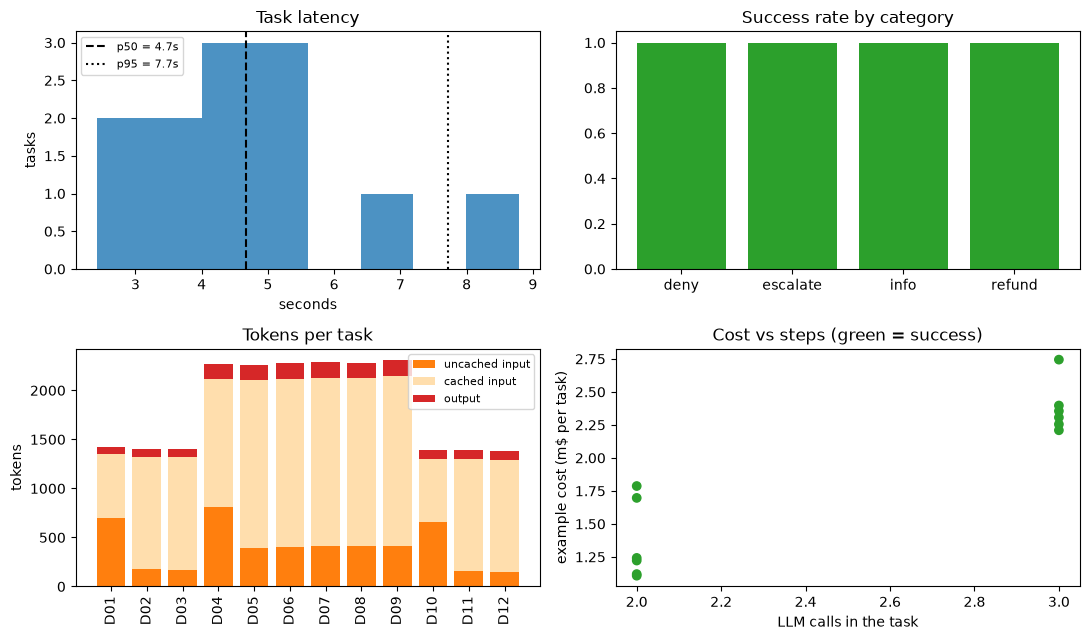

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
ax = axes[0, 0]
ax.hist(BASELINE_TM.latency_s, bins=8, color="tab:blue", alpha=0.8)
for q, style in [(0.5, "--"), (0.95, ":")]:
    ax.axvline(BASELINE_TM.latency_s.quantile(q), color="k", ls=style, label=f"p{int(q * 100)} = {BASELINE_TM.latency_s.quantile(q):.1f}s")
ax.set(title="Task latency", xlabel="seconds", ylabel="tasks")
ax.legend(fontsize=8)
ax = axes[0, 1]
by_cat = BASELINE_TM.groupby("category").agg(success=("success", "mean"), steps=("steps", "mean"))
ax.bar(by_cat.index, by_cat.success, color="tab:green")
ax.set(title="Success rate by category", ylim=(0, 1.05))
ax = axes[1, 0]
ax.bar(BASELINE_TM.task, BASELINE_TM.input_tokens - BASELINE_TM.cached_tokens, label="uncached input", color="tab:orange")
ax.bar(BASELINE_TM.task, BASELINE_TM.cached_tokens, bottom=BASELINE_TM.input_tokens - BASELINE_TM.cached_tokens, label="cached input", color="navajowhite")
ax.bar(BASELINE_TM.task, BASELINE_TM.output_tokens, bottom=BASELINE_TM.input_tokens, label="output", color="tab:red")
ax.set(title="Tokens per task", ylabel="tokens")
ax.tick_params(axis="x", rotation=90)
ax.legend(fontsize=8)
ax = axes[1, 1]
ax.scatter(BASELINE_TM.steps, BASELINE_TM.cost_usd * 1000, c=BASELINE_TM.success.map({True: "tab:green", False: "tab:red"}))
ax.set(title="Cost vs steps (green = success)", xlabel="LLM calls in the task", ylabel="example cost (m$ per task)")
plt.tight_layout()
plt.show()

**Spans → OpenTelemetry metrics.** Dashboards usually read *metrics*, which are cheaper to store than every span. The GenAI conventions define histograms such as `gen_ai.client.token.usage` (`{token}`, split by `gen_ai.token.type`) and `gen_ai.client.operation.duration` (seconds). A collector can derive them from spans; here we record them from our chat spans with the OTel metrics SDK and an in-memory reader.

In [22]:
from opentelemetry.sdk.metrics import MeterProvider
from opentelemetry.sdk.metrics.export import InMemoryMetricReader
from opentelemetry.semconv._incubating.metrics import gen_ai_metrics as GM

reader = InMemoryMetricReader()
meter = MeterProvider(metric_readers=[reader], resource=RESOURCE).get_meter("supportkit")
token_usage = meter.create_histogram(GM.GEN_AI_CLIENT_TOKEN_USAGE, unit="{token}", description="Input and output tokens per LLM call")
duration = meter.create_histogram(GM.GEN_AI_CLIENT_OPERATION_DURATION, unit="s", description="LLM call duration")
for row in BASELINE_SPANS[BASELINE_SPANS.op == "chat"].itertuples():
    common = {GA.GEN_AI_OPERATION_NAME: "chat", GA.GEN_AI_PROVIDER_NAME: agent.PROVIDER, GA.GEN_AI_REQUEST_MODEL: row.attributes[GA.GEN_AI_REQUEST_MODEL]}
    token_usage.record(row.attributes[GA.GEN_AI_USAGE_INPUT_TOKENS], {**common, GA.GEN_AI_TOKEN_TYPE: "input"})
    token_usage.record(row.attributes[GA.GEN_AI_USAGE_OUTPUT_TOKENS], {**common, GA.GEN_AI_TOKEN_TYPE: "output"})
    duration.record(row.duration_s, common)
for metric in reader.get_metrics_data().resource_metrics[0].scope_metrics[0].metrics:
    for point in metric.data.data_points:
        print(f"{metric.name:34s} unit={metric.unit:8s} {dict(point.attributes).get(GA.GEN_AI_TOKEN_TYPE, ''):6s} "
              f"count={point.count:3d} sum={point.sum:10.1f} max={point.max:8.1f}")

gen_ai.client.token.usage          unit={token}  input  count= 30 sum=   20609.0 max=   824.0
gen_ai.client.token.usage          unit={token}  output count= 30 sum=    1439.0 max=    75.0
gen_ai.client.operation.duration   unit=s               count= 30 sum=      57.3 max=     4.3


### ✍️ Your Turn

Error budgets. An agent has a **99% success SLO over 30 days** and handles about **20,000 tasks** per 30 days. After **10 days** there have been **120 failed tasks**. Compute `(allowed_failures, budget_consumed, burn_rate)`: allowed failures in the 30-day window, the share of the budget already used, and the **burn rate** = (failures per day so far) ÷ (allowed failures per day).

In [23]:
budget_numbers = None  # TODO: (allowed_failures, budget_consumed, burn_rate)
check("budget_numbers", budget_numbers, (200.0, 0.6, 1.8),
      hint="allowed = (1 - 0.99) * 20000; consumed = 120 / allowed; burn = (120 / 10) / (allowed / 30)")

⏳ budget_numbers: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
allowed = (1 - 0.99) * 20_000
budget_numbers = (round(allowed, 6), round(120 / allowed, 6), round((120 / 10) / (allowed / 30), 6))
check("budget_numbers", budget_numbers, (200.0, 0.6, 1.8))
```

A burn rate of 1.8 means the budget runs out in 30 / 1.8 ≈ 16.7 days, well before the window ends. Section 9 turns burn rates into alerts.
</details>

> 💡 **Interview angle:** "What metrics and SLOs would you put on an agent?" — task success (graded or from feedback), p50/p95 end-to-end latency and time to first token, steps and tool calls per task, tool error rate, escalation rate, cost per task, all sliced by config version and task type. Set SLOs on the few users feel (success, p95 latency, TTFT), manage them with an error budget, and alert on burn rate rather than on single failures.

## 4. Reliability: Timeouts, Retries, Idempotency, Circuit Breakers, Fallbacks 🔴

Every dependency fails sometimes. The question is what your agent does next. Five tools, each for a different failure:

| Failure | Example | Tool |
|---|---|---|
| a call hangs | a database lock, a stuck HTTP connection | **timeout** at every layer |
| a call fails briefly | 503, 429, connection reset | **retry with exponential backoff + jitter**, transient errors only |
| a retry repeats an effect | the refund committed, then the reply was lost | **idempotency key** |
| a dependency is down for minutes | payments API outage | **circuit breaker**: stop calling, fail fast, probe later |
| nothing works | all of the above | **fallback / graceful degradation**: cached answer, smaller model, human |

### Timeouts at every layer

```
 job deadline (e.g. 120 s) ─┬─ LLM call timeout (e.g. 60 s) ── HTTP connect/read timeouts inside the SDK
                            └─ tool call timeout (e.g. 1–5 s) ── database / HTTP timeouts inside the tool
```

Inner timeouts must be **shorter** than outer ones, and each call should get `min(its own cap, time left before the job deadline)`. Without a timeout, one hung dependency holds a worker (and an LLM slot) forever.

In [24]:
import tenacity

SLOW_READ = next(store.FaultPlan(rate=1.0, seed=s, slow_s=1.5) for s in range(200)
                 if store.FaultPlan(rate=1.0, seed=s, slow_s=1.5).draw("timeouts", "get_order_details", {"order_id": DEMO_TASK.order_id}, 0, write=False) == "slow")
slow_backend = store.SupportBackend(TEMPLATE_DB, DEMO_TASK.customer_id, faults=SLOW_READ, scope="timeouts")
start = time.perf_counter()
try:
    await store.RealClock().wait_for(slow_backend.call("get_order_details", {"order_id": DEMO_TASK.order_id}), timeout=0.3)
except store.ToolTimeoutError as exc:
    print(f"real clock: gave up after {time.perf_counter() - start:.2f}s — {exc} (this reply would have taken {SLOW_READ.slow_s}s)")
slow_backend.close()


def call_timeout(deadline, clock, per_call_cap):
    """Never wait longer than the call's own cap, and never past the job's deadline."""
    return max(0.0, min(per_call_cap, deadline - clock.now()))


clock = store.FakeClock()
deadline = clock.now() + 6.0                                     # the whole job must finish within 6 s
CAPS = {"chat": 3.0, "tool": 1.0}
for kind, would_take in [("chat", 1.8), ("tool", 0.4), ("chat", 2.1), ("tool", 0.9), ("chat", 2.5)]:
    timeout = call_timeout(deadline, clock, CAPS[kind])
    if timeout == 0:
        print(f"t={clock.now():.1f}s  {kind:4s} not started: job deadline reached → stop and report a partial result")
        break
    await clock.sleep(min(would_take, timeout))
    print(f"t={clock.now():.1f}s  {kind:4s} timeout {timeout:.1f}s, would take {would_take:.1f}s → {'ok' if would_take <= timeout else 'TIMED OUT'}")

real clock: gave up after 0.30s — no reply within 0.30s (this reply would have taken 1.5s)
t=1.8s  chat timeout 3.0s, would take 1.8s → ok
t=2.2s  tool timeout 1.0s, would take 0.4s → ok
t=4.3s  chat timeout 3.0s, would take 2.1s → ok
t=5.2s  tool timeout 1.0s, would take 0.9s → ok
t=6.0s  chat timeout 0.8s, would take 2.5s → TIMED OUT


### Retries: transient errors only, with exponential backoff and jitter

| Retry? | Errors | Why |
|---|---|---|
| ✅ yes | timeouts, connection resets, **429** (honour `Retry-After`), **502/503/504**, "overloaded" | the same request can succeed a moment later |
| ❌ no | **400/422** invalid arguments, **401/403** auth, **404**, policy denials, validation errors | the same request will fail again; you only add load and latency |
| ⚠️ only with an idempotency key | any failure of a **side-effecting** call whose outcome is unknown | the first attempt may have succeeded |

**Backoff** waits longer after each failure: `ceiling(n) = min(cap, base × 2^(n-1))`. **Jitter** randomizes the wait so thousands of clients that failed together don't retry together (a "thundering herd"). AWS's analysis recommends **full jitter**: wait `uniform(0, ceiling(n))`. In Python, **tenacity** implements this as `wait_random_exponential(multiplier=base, max=cap)`. We give it the fake clock's `sleep`, so no time is really spent.

In [25]:
def backoff_ceiling(attempt, base_s=0.2, cap_s=2.0):
    return min(cap_s, base_s * 2 ** (attempt - 1))


schedule_rng = random.Random(SEED)
schedule = pd.DataFrame([{"after failure #": n, "ceiling s": backoff_ceiling(n), "no jitter s": backoff_ceiling(n),
                          "full jitter s (one draw)": round(schedule_rng.uniform(0, backoff_ceiling(n)), 3),
                          "equal jitter s (one draw)": round(backoff_ceiling(n) / 2 + schedule_rng.uniform(0, backoff_ceiling(n) / 2), 3)}
                         for n in range(1, 7)])
print(schedule.to_string(index=False))


def make_retrying(clock, max_attempts=4, base_s=0.2, cap_s=2.0):
    return tenacity.AsyncRetrying(stop=tenacity.stop_after_attempt(max_attempts),
                                  wait=tenacity.wait_random_exponential(multiplier=base_s, max=cap_s),
                                  retry=tenacity.retry_if_exception_type(store.TransientToolError),   # transient only
                                  sleep=clock.sleep, reraise=True)


async def with_retries(fn, clock, **kwargs):
    async for attempt in make_retrying(clock, **kwargs):
        with attempt:
            return await fn()


class ScriptedFailures:
    """Raises the scripted exceptions in order, then returns 'ok'. Counts calls."""

    def __init__(self, errors):
        self.errors, self.calls = list(errors), 0

    async def __call__(self):
        self.calls += 1
        if self.errors:
            raise self.errors.pop(0)
        return "ok"


print()
for label, errors in [("two 503s, then success", [store.TransientToolError("503"), store.TransientToolError("503")]),
                      ("timeouts every time", [store.ToolTimeoutError("timeout")] * 6),
                      ("400 invalid request", [store.PermanentToolError("item_ids must be a list")])]:
    random.seed(SEED)
    clock, fn = store.FakeClock(), ScriptedFailures(errors)
    try:
        outcome = await with_retries(fn, clock)
    except store.ToolError as exc:
        outcome = f"gave up: {type(exc).__name__}"
    print(f"{label:24s} → calls {fn.calls} | waits {[round(s, 3) for s in clock.sleeps]} | {outcome}")

 after failure #  ceiling s  no jitter s  full jitter s (one draw)  equal jitter s (one draw)
               1        0.2          0.2                     0.128                      0.103
               2        0.4          0.4                     0.110                      0.245
               3        0.8          0.8                     0.589                      0.671
               4        1.6          1.6                     1.427                      0.870
               5        2.0          2.0                     0.844                      1.030
               6        2.0          2.0                     0.437                      1.505

two 503s, then success   → calls 3 | waits [0.128, 0.01] | ok
timeouts every time      → calls 4 | waits [0.128, 0.01, 0.22] | gave up: ToolTimeoutError
400 invalid request      → calls 1 | waits [] | gave up: PermanentToolError


The permanent error was **not** retried, the transient ones were, each wait was random but below its ceiling, and the persistent timeout gave up after 4 attempts instead of hammering the dependency.

### Idempotency keys: retries without duplicate side effects

The worst failure for a side-effecting call is **"I don't know if it worked"**: the request reached the payments API, the refund was committed, and then the connection dropped. A retry is the right move *only* if the server can recognise it as the same request. The client sends an **idempotency key**; the server stores the key and the result **in the same transaction as the effect**, and answers a repeated key with the stored result.

Here is the duplicated refund from Section 1, reproduced without the LLM: the first call loses its reply, and the caller retries.

In [26]:
def key_for(conversation_id, tool, args):
    """Stable across retries AND process restarts: derived from the job + tool + canonical arguments, never random."""
    return store.sha256(f"{conversation_id}|{tool}|{store.canonical_json(args)}")[:32]


LOST_REPLY = next(store.FaultPlan(rate=0.5, seed=s) for s in range(500)
                  if [store.FaultPlan(rate=0.5, seed=s).draw("idempotency", "issue_refund", refund_args, n, write=True) for n in range(3)]
                  == ["lost_response", None, None])
idempotency_rows = []
for label, use_key in [("❌ retry without a key", False), ("✅ retry with an idempotency key", True)]:
    b = store.SupportBackend(TEMPLATE_DB, DEMO_TASK.customer_id, faults=LOST_REPLY, scope="idempotency")
    key = key_for(DEMO_TASK.task_id, "issue_refund", refund_args) if use_key else None
    attempts = []
    for _ in range(3):
        try:
            response = await b.call("issue_refund", refund_args, idempotency_key=key)
            attempts.append(f"ok (refund_id {response['refund_id']})")
            break
        except store.TransientToolError:
            attempts.append("reply lost")
    ledger = b.end_state()["refunds"]
    idempotency_rows.append({"caller": label, "attempts": " → ".join(attempts), "ledger rows": len(ledger),
                             "customer refunded $": round(sum(r[2] for r in ledger), 2), "answered from idempotency store": b.payments.replays})
    b.close()
print(pd.DataFrame(idempotency_rows).to_string(index=False))
print(f"\nexpected refund: ${DEMO_TASK.expected_refunds[0][2]:.2f}")

                         caller                      attempts  ledger rows  customer refunded $  answered from idempotency store
          ❌ retry without a key reply lost → ok (refund_id 2)            2                317.8                                0
✅ retry with an idempotency key reply lost → ok (refund_id 1)            1                158.9                                1

expected refund: $158.90


**Rules for idempotency keys:** derive them from something stable (job id + step + canonical arguments), create them **before** the first attempt, reuse them on every retry and after a crash, store key + result atomically with the effect, reject a reused key with different parameters, and expire keys only after any retry could still arrive (payment APIs keep them for about a day). Retries make delivery **at-least-once**; idempotency turns that into **effectively once**.

### Circuit breakers

When a dependency is *down*, retries make things worse: every request waits for a timeout, workers and LLM slots pile up, and the struggling service gets hammered. A **circuit breaker** watches failures and stops calling for a while:

```
  CLOSED ──(N consecutive failures)──► OPEN ──(cooldown elapsed)──► HALF-OPEN ──(probe succeeds)──► CLOSED
    calls go through                  fail fast, no call            one trial call
                                        ▲                               │
                                        └────────(probe fails)──────────┘
```

A measured sketch (the full breaker with tests is in 🔧): the payments API is down from t = 2 s to t = 12 s; a request arrives every 0.25 s; a call to a dead dependency waits the full 1 s timeout.

In [27]:
def outage_experiment(use_breaker, threshold=3, cooldown_s=2.0, timeout_s=1.0, n_requests=80, spacing_s=0.25):
    down = lambda t: 2.0 <= t < 12.0
    in_a_row, opened_at, waited, failed_slow, failed_fast, served, fast_after_recovery = 0, None, 0.0, 0, 0, 0, 0
    for i in range(n_requests):
        t = i * spacing_s
        if use_breaker and opened_at is not None and t - opened_at < cooldown_s:
            failed_fast += 1                                    # OPEN: reject immediately, no call
            fast_after_recovery += not down(t)
            continue
        if down(t):                                             # CLOSED or HALF-OPEN probe hits the dead dependency
            waited, failed_slow, in_a_row = waited + timeout_s, failed_slow + 1, in_a_row + 1
            if use_breaker and (opened_at is not None or in_a_row >= threshold):
                opened_at = t                                   # open (or re-open after a failed probe)
        else:
            waited, served, in_a_row, opened_at = waited + 0.05, served + 1, 0, None
    return {"seconds waiting on calls": round(waited, 2), "slow failures (timeouts)": failed_slow, "fast failures (breaker open)": failed_fast,
            "served": served, "rejected after recovery": fast_after_recovery}


breaker_table = pd.DataFrame({"no breaker": outage_experiment(False), "circuit breaker": outage_experiment(True)}).T
print(breaker_table.to_string())
saved = breaker_table.loc["no breaker", "seconds waiting on calls"] - breaker_table.loc["circuit breaker", "seconds waiting on calls"]
print(f"\n→ The breaker saved {saved:.1f} s of blocked waiting during a 10 s outage, at the price of "
      f"{breaker_table.loc['circuit breaker', 'rejected after recovery']} request(s) rejected just after recovery (until the next probe).")

                 seconds waiting on calls  slow failures (timeouts)  fast failures (breaker open)  served  rejected after recovery
no breaker                           42.0                      40.0                           0.0    40.0                      0.0
circuit breaker                       8.9                       7.0                          35.0    38.0                      2.0

→ The breaker saved 33.1 s of blocked waiting during a 10 s outage, at the price of 2.0 request(s) rejected just after recovery (until the next probe).


### Fallbacks and graceful degradation

When the primary path fails, give the user something useful and honest instead of an error or a guess:

1. **Retry** (transient) → 2. **cached answer** with its age ("as of 3 minutes ago") → 3. **cheaper or alternative model/provider** for the LLM step → 4. **human escalation** with the context collected so far.

Degrade *features*, not *correctness*: showing a slightly stale order status is fine; issuing a refund from stale data is not.

In [28]:
LAST_KNOWN = {}                                                   # order_id → (snapshot, time), refreshed on every successful lookup


async def order_status_with_fallbacks(backend, order_id, clock):
    try:
        order = await with_retries(lambda: clock.wait_for(backend.call("get_order_details", {"order_id": order_id}), 1.0), clock, max_attempts=3)
        LAST_KNOWN[order_id] = (order, clock.now())
        return {"source": "live", "status": order["status"]}
    except store.ToolError:
        if order_id in LAST_KNOWN:
            snapshot, seen_at = LAST_KNOWN[order_id]
            return {"source": f"cached snapshot, {clock.now() - seen_at:.0f}s old", "status": snapshot["status"]}
        return {"source": "human escalation", "status": "unknown — a ticket was created for a human agent"}


info_tasks = [t for t in DEV_TASKS if t.category == "info"][:2]
clock = store.FakeClock()
healthy = store.SupportBackend(TEMPLATE_DB, info_tasks[0].customer_id, clock=clock)
print("healthy  :", info_tasks[0].order_id, await order_status_with_fallbacks(healthy, info_tasks[0].order_id, clock))
healthy.close()
await clock.sleep(240)                                            # four minutes later, the order service goes down
OUTAGE = store.FaultPlan(rate=1.0, seed=0, slow_s=3.0)
for task in info_tasks:
    down = store.SupportBackend(TEMPLATE_DB, task.customer_id, faults=OUTAGE, scope="outage", clock=clock)
    print("outage   :", task.order_id, await order_status_with_fallbacks(down, task.order_id, clock))
    down.close()

healthy  : #W4887592 {'source': 'live', 'status': 'delivered'}
outage   : #W4887592 {'source': 'cached snapshot, 243s old', 'status': 'delivered'}
outage   : #W4072946 {'source': 'human escalation', 'status': 'unknown — a ticket was created for a human agent'}


### Fault-injection experiment: does resilience pay off?

Claims about reliability need measurements. We **replay** the tool plan of each dev task (the exact tool sequence the model used in the Section 3 baseline, checked below) against backends with **0%, 10% and 30%** of tool calls failing, 25 fault seeds per rate, three ways:

- **no retries** — one attempt per call, 1 s timeout (what the demo does when the model gives up);
- **blind retries** — up to 4 immediate attempts on *any* error, no idempotency key (what a naive retry loop, or a model that "tries again", does);
- **resilient** — tenacity retries for transient errors only, jittered backoff, 1 s timeout, **idempotency keys** on writes.

Replaying the plan keeps the LLM out of this experiment, so the only thing that changes is the tool layer, and it makes 2,700 runs free and deterministic. The Mini Project repeats the comparison end-to-end with the real model in the loop.

the model's tool sequence matched the reference plan in 12/12 baseline tasks


2,700 replayed task runs in 0.9s of real time

                    success  duplicates_per_100_tasks  attempts_per_task  p95_seconds_per_task
rate variant                                                                                  
0.0  no retries       1.000                     0.000              1.500                 0.000
     blind retries    1.000                     0.000              1.500                 0.000
     resilient        1.000                     0.000              1.500                 0.000
0.1  no retries       0.867                     0.000              1.453                 1.000
     blind retries    0.983                     1.667              1.660                 1.000
     resilient        0.997                     0.000              1.660                 1.049
0.3  no retries       0.603                     0.000              1.340                 1.000
     blind retries    0.937                     6.667              2.147                 1.000
   

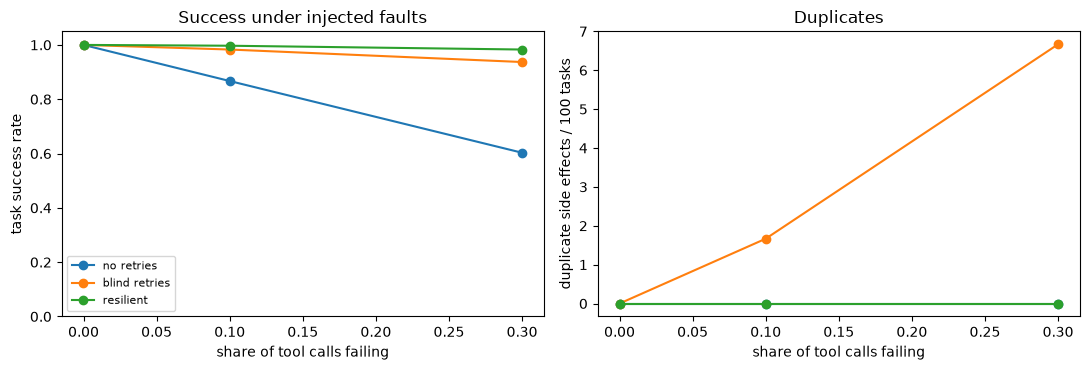

at 30% failures: success no retries 60%, blind retries 94% (with 6.7 duplicate side effects per 100 tasks), resilient 98% (duplicates 0.0); resilience cost 1.6× the attempts and p95 1.5s of waiting per task.


In [29]:
PLAN_TOOLS = {"info": ["get_order_details"], "refund": ["check_return_policy", "issue_refund"],
              "escalate": ["check_return_policy", "transfer_to_human_agents"], "deny": ["check_return_policy"]}
followed = [row["tools"] == PLAN_TOOLS[row["category"]] for row in baseline_rows]
print(f"the model's tool sequence matched the reference plan in {sum(followed)}/{len(followed)} baseline tasks")


async def execute_plan(task, call):
    if task.category == "info":
        await call("get_order_details", {"order_id": task.order_id})
        return
    policy = await call("check_return_policy", {"order_id": task.order_id, "item_names": [task.item_name]})
    if policy.get("decision") == "refund":
        await call("issue_refund", {"order_id": task.order_id, "item_ids": policy["item_ids"], "payment_method_id": policy["original_payment_method_id"]})
    elif policy.get("decision") == "escalate":
        await call("transfer_to_human_agents", {"order_id": task.order_id, "summary": f"Refund for the {task.item_name} is over the limit."})


VARIANTS = ["no retries", "blind retries", "resilient"]


async def replay_task(task, variant, rate, trial, timeout_s=1.0):
    clock = store.FakeClock()
    backend = store.SupportBackend(TEMPLATE_DB, task.customer_id, faults=store.FaultPlan(rate=rate, seed=trial), scope=task.task_id, clock=clock)
    random.seed(f"{task.task_id}|{variant}|{rate}|{trial}")        # tenacity's jitter uses the global random module
    attempts = 0

    async def call(tool, args):
        nonlocal attempts
        key = key_for(task.task_id, tool, args) if variant == "resilient" and tool in store.WRITE_TOOLS else None

        async def once():
            nonlocal attempts
            attempts += 1
            return await clock.wait_for(backend.call(tool, args, idempotency_key=key), timeout_s)

        if variant == "no retries":
            return await once()
        if variant == "blind retries":
            for i in range(4):
                try:
                    return await once()
                except store.ToolError:
                    if i == 3:
                        raise
        return await with_retries(once, clock)

    try:
        await execute_plan(task, call)
        completed = True
    except store.ToolError:
        completed = False
    answer = (" ".join(task.must_mention) or "done") if completed else ""
    graded = store.grade(task, backend.end_state(), answer)
    backend.close()
    return {"variant": variant, "rate": rate, "trial": trial, "task": task.task_id, "success": graded["success"],
            "completed": completed, "duplicates": graded["duplicates"], "attempts": attempts, "seconds": clock.now()}


start = time.perf_counter()
fault_rows = [await replay_task(task, variant, rate, trial)
              for rate in (0.0, 0.1, 0.3) for trial in range(25) for task in DEV_TASKS for variant in VARIANTS]
fault_df = pd.DataFrame(fault_rows)
fault_summary = fault_df.groupby(["rate", "variant"], sort=False).agg(
    success=("success", "mean"), duplicates_per_100_tasks=("duplicates", lambda d: 100 * d.mean()),
    attempts_per_task=("attempts", "mean"), p95_seconds_per_task=("seconds", lambda s: s.quantile(0.95))).round(3)
print(f"{len(fault_df):,} replayed task runs in {time.perf_counter() - start:.1f}s of real time\n")
print(fault_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for variant in VARIANTS:
    sub = fault_summary.xs(variant, level="variant")
    axes[0].plot(sub.index, sub.success, marker="o", label=variant)
    axes[1].plot(sub.index, sub.duplicates_per_100_tasks, marker="o", label=variant)
axes[0].set(xlabel="share of tool calls failing", ylabel="task success rate", ylim=(0, 1.05), title="Success under injected faults")
axes[1].set(xlabel="share of tool calls failing", ylabel="duplicate side effects / 100 tasks", title="Duplicates")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

at30 = fault_summary.xs(0.3, level="rate")
print(f"at 30% failures: success no retries {at30.loc['no retries', 'success']:.0%}, blind retries {at30.loc['blind retries', 'success']:.0%} "
      f"(with {at30.loc['blind retries', 'duplicates_per_100_tasks']:.1f} duplicate side effects per 100 tasks), resilient {at30.loc['resilient', 'success']:.0%} "
      f"(duplicates {at30.loc['resilient', 'duplicates_per_100_tasks']:.1f}); resilience cost {at30.loc['resilient', 'attempts_per_task'] / at30.loc['no retries', 'attempts_per_task']:.1f}× the attempts "
      f"and p95 {at30.loc['resilient', 'p95_seconds_per_task']:.1f}s of waiting per task.")

### ✍️ Your Turn

Write the retry decision as a pure function. `should_retry(error, attempt, max_attempts, side_effect, has_key)` returns `True` only if the error is **transient** (`"timeout"`, `"connection_reset"`, `"429"`, `"502"`, `"503"`, `"504"`), attempts remain (`attempt < max_attempts`), and the call is either free of side effects **or** carries an idempotency key.

In [30]:
def should_retry(error, attempt, max_attempts, side_effect, has_key):
    return None  # TODO


retry_cases = [("503", 1, 4, False, False), ("400", 1, 4, False, False), ("timeout", 4, 4, False, False),
               ("connection_reset", 2, 4, True, False), ("connection_reset", 2, 4, True, True), ("429", 3, 4, False, False)]
check("should_retry", None if should_retry(*retry_cases[0]) is None else [should_retry(*c) for c in retry_cases],
      [True, False, False, False, True, True], hint="transient = error in {...}; return transient and attempt < max_attempts and (not side_effect or has_key)")

⏳ should_retry: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
TRANSIENT = {"timeout", "connection_reset", "429", "502", "503", "504"}


def should_retry(error, attempt, max_attempts, side_effect, has_key):
    return error in TRANSIENT and attempt < max_attempts and (not side_effect or has_key)


retry_cases = [("503", 1, 4, False, False), ("400", 1, 4, False, False), ("timeout", 4, 4, False, False),
               ("connection_reset", 2, 4, True, False), ("connection_reset", 2, 4, True, True), ("429", 3, 4, False, False)]
check("should_retry", [should_retry(*c) for c in retry_cases], [True, False, False, False, True, True])
```

Case 4 is the refund with a lost reply and no key: the safe move is to **check the outcome** (look the refund up) or escalate, not to blindly retry.
</details>

> 💡 **Interview angle:** "Retries vs idempotency?" — retries handle *transient* failures (timeouts, 429, 5xx) with capped exponential backoff and jitter, at **one** layer, within a deadline. Idempotency makes retries *safe* for side effects: a stable key stored atomically with the effect, so a repeated request returns the original result. Never retry permanent errors; never retry a non-idempotent write whose outcome is unknown. Add circuit breakers for outages and fallbacks for graceful degradation, and prove it with fault injection.

## 5. Durable Execution: Checkpoint, Crash, Resume 🔴

Some agent tasks run for minutes or hours: a refund batch, a research report, a data migration. Workers die in the middle: deploys, out-of-memory kills, spot instances, laptops closing. **Durable execution** means the work *survives* that: progress is **saved after each step**, and a new worker **resumes from the last saved step** instead of starting over.

```
 run 1:  plan ✔ ─ refund_0 ✔ ─ refund_1 ✔ ─ refund_2 💥 (worker killed)
             ▲ checkpoint   ▲ checkpoint   ▲ checkpoint
 run 2:                                    refund_2 ─ refund_3 ─ refund_4 ─ notify ✔   (resume from the last checkpoint)
```

The catch is in `refund_2`: it was **running** when the worker died. Maybe its refund was committed, maybe not. The checkpoint is written *after* a step finishes, so on resume the step runs **again**. Durable engines give you **at-least-once** execution of each step. **Exactly-once side effects** still need idempotency.

We test this for real. A **refund batch** of 5 real delivered orders becomes a LangGraph graph (`refund_0 → … → refund_4 → notify`) compiled with a **SQLite checkpointer** (`SqliteSaver` from `langgraph-checkpoint-sqlite`). It runs in a **separate worker process**. The notebook waits until `refund_2` has committed its refund, then **kills the worker with SIGKILL** (no cleanup, like a power cut), starts a new worker, and counts what happened. (The prerequisite [LangChain and LangGraph notebook](../08_Generative_AI_LLM/03_LangChain_and_LangGraph.ipynb) introduced checkpointers and threads; here we stress them.)

In [31]:
%%writefile _outputs/prod_agents/supportkit/durable_worker.py
"""A refund batch as a LangGraph graph with a SQLite checkpointer, run as its own process:
python -m supportkit.durable_worker --db batch.sqlite --checkpoints ckpt.sqlite --thread batch-1 --requests r.json [--idempotent] [--hang-at 2]"""
from __future__ import annotations

import argparse
import json
import operator
import os
import sqlite3
import time
from pathlib import Path
from typing import Annotated, TypedDict

from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import END, START, StateGraph

from supportkit.store import PaymentsProvider, canonical_json, sha256


class BatchState(TypedDict, total=False):
    requests: list                                   # [{"order_id", "item_ids", "amount", "payment_method_id"}]
    refund_ids: Annotated[list, operator.add]        # reducer: each step appends its refund id
    notified: bool


def build_graph(db_path, n_requests, thread_id, idempotent, hang_at=-1):
    builder = StateGraph(BatchState)

    def make_refund_step(i):
        def refund(state):
            with sqlite3.connect(db_path, timeout=30) as con:            # audit every execution, including re-runs
                con.execute("INSERT INTO executions(node, pid) VALUES (?, ?)", (f"refund_{i}", os.getpid()))
            request = state["requests"][i]
            key = sha256(f"{thread_id}|refund_{i}|{canonical_json(request)}")[:32] if idempotent else None
            con = sqlite3.connect(db_path, timeout=30)
            try:
                response = PaymentsProvider(con).refund(request["order_id"], request["item_ids"], request["amount"],
                                                        request["payment_method_id"], idempotency_key=key)
            finally:
                con.close()
            if i == hang_at:
                time.sleep(600)                              # a slow step that is still running when the worker dies
            return {"refund_ids": [response["refund_id"]]}
        return refund

    def notify(state):
        with sqlite3.connect(db_path, timeout=30) as con:
            con.execute("INSERT INTO executions(node, pid) VALUES ('notify', ?)", (os.getpid(),))
            con.execute("INSERT INTO outbox(message) VALUES (?)", (f"{thread_id}: {len(state['refund_ids'])} refunds issued",))
        return {"notified": True}

    previous = START
    for i in range(n_requests):
        builder.add_node(f"refund_{i}", make_refund_step(i))
        builder.add_edge(previous, f"refund_{i}")
        previous = f"refund_{i}"
    builder.add_node("notify", notify)
    builder.add_edge(previous, "notify")
    builder.add_edge("notify", END)
    return builder


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--db", required=True)
    parser.add_argument("--checkpoints", default="none")
    parser.add_argument("--thread", required=True)
    parser.add_argument("--requests", required=True)
    parser.add_argument("--idempotent", action="store_true")
    parser.add_argument("--hang-at", type=int, default=-1)
    parser.add_argument("--durability", choices=["sync", "async", "exit"], default="sync")
    args = parser.parse_args()
    requests = json.loads(Path(args.requests).read_text())
    builder = build_graph(args.db, len(requests), args.thread, args.idempotent, args.hang_at)
    if args.checkpoints == "none":                           # no persistence: every start is a fresh run
        final, resumed = builder.compile().invoke({"requests": requests, "refund_ids": []}), False
    else:
        with SqliteSaver.from_conn_string(args.checkpoints) as saver:
            graph = builder.compile(checkpointer=saver)
            config = {"configurable": {"thread_id": args.thread}}
            resumed = bool(graph.get_state(config).next)     # unfinished steps saved for this thread?
            final = graph.invoke(None if resumed else {"requests": requests, "refund_ids": []}, config, durability=args.durability)
    print(json.dumps({"resumed": resumed, "refund_ids": final.get("refund_ids"), "notified": final.get("notified", False)}))


if __name__ == "__main__":
    main()

Overwriting _outputs/prod_agents/supportkit/durable_worker.py


The batch: five real delivered orders (not used by any task), one item each.

In [32]:
from langgraph.checkpoint.sqlite import SqliteSaver

import supportkit.durable_worker as durable_worker

DURABLE_DIR = OUTPUT_DIR / "durable"
shutil.rmtree(DURABLE_DIR, ignore_errors=True)
DURABLE_DIR.mkdir(parents=True)
task_orders = {t.order_id for t in DEV_TASKS + TEST_TASKS}
with sqlite3.connect(TEMPLATE_DB) as con:
    candidates = con.execute("""SELECT o.order_id, i.item_id, i.price, p.payment_method_id FROM orders o
                                JOIN order_items i ON i.order_id = o.order_id
                                JOIN payments p ON p.order_id = o.order_id AND p.transaction_type = 'payment'
                                WHERE o.status = 'delivered' AND i.price < 500 GROUP BY o.order_id ORDER BY o.order_id""").fetchall()
candidates = [c for c in candidates if c[0] not in task_orders]
random.Random(SEED).shuffle(candidates)
BATCH = [{"order_id": o, "item_ids": [i], "amount": round(p, 2), "payment_method_id": pm} for o, i, p, pm in candidates[:5]]
REQUESTS_PATH = DURABLE_DIR / "requests.json"
REQUESTS_PATH.write_text(json.dumps(BATCH))
EXPECTED_TOTAL = round(sum(r["amount"] for r in BATCH), 2)
print(pd.DataFrame(BATCH).to_string(index=False))
print(f"expected: {len(BATCH)} refunds, ${EXPECTED_TOTAL:,.2f} in total")

RUNNING_WORKERS = []


def fresh_batch_db(path):
    with sqlite3.connect(path) as con:
        con.executescript(store.SCHEMA)
        con.executescript("CREATE TABLE executions(node TEXT, pid INTEGER, at TEXT DEFAULT CURRENT_TIMESTAMP);"
                          "CREATE TABLE outbox(message TEXT);")


def ledger_rows(db_path):
    try:
        with sqlite3.connect(db_path, timeout=1) as con:
            return con.execute("SELECT COUNT(*) FROM ledger").fetchone()[0]
    except sqlite3.OperationalError:                          # locked for a moment by the worker
        return -1


def run_worker(db, checkpoints, *, idempotent, durability="sync", hang_at=-1, kill_after_ledger_rows=None, thread="refund-batch-1"):
    """Start the worker process; optionally SIGKILL it as soon as the ledger has N rows. Returns what happened."""
    cmd = [sys.executable, "-m", "supportkit.durable_worker", "--db", str(db.resolve()), "--thread", thread,
           "--checkpoints", str(checkpoints.resolve()) if checkpoints else "none", "--requests", str(REQUESTS_PATH.resolve()),
           "--durability", durability, "--hang-at", str(hang_at)] + (["--idempotent"] if idempotent else [])
    proc = subprocess.Popen(cmd, cwd=OUTPUT_DIR, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True,
                            env={**os.environ, "PYTHONUNBUFFERED": "1"})
    RUNNING_WORKERS.append(proc)
    killed = False
    try:
        if kill_after_ledger_rows is not None:
            deadline = time.time() + 90
            while proc.poll() is None and time.time() < deadline:
                if ledger_rows(db) >= kill_after_ledger_rows:
                    proc.send_signal(signal.SIGKILL)               # no cleanup, no final checkpoint: like a power cut
                    killed = True
                    break
                time.sleep(0.02)
        out, err = proc.communicate(timeout=120)
    finally:
        if proc.poll() is None:
            proc.kill()
            proc.wait()
    if proc.returncode not in (0, -signal.SIGKILL):
        print(f"worker failed ({proc.returncode}):", err.replace(HOME, "~")[-1500:])
    return {"killed": killed, "returncode": proc.returncode, "report": json.loads(out.strip().splitlines()[-1]) if proc.returncode == 0 else None}


SCENARIOS = [
    ("A · no checkpointer, no keys", dict(checkpointer=False, idempotent=False)),
    ("B · no checkpointer, idempotency keys", dict(checkpointer=False, idempotent=True)),
    ("C · SQLite checkpointer (sync), no keys", dict(checkpointer=True, idempotent=False)),
    ("D · SQLite checkpointer (sync) + keys", dict(checkpointer=True, idempotent=True)),
    ("E · checkpointer, durability='exit', no keys", dict(checkpointer=True, idempotent=False, durability="exit")),
]
durable_rows = []
start = time.perf_counter()
for name, options in SCENARIOS:
    folder = DURABLE_DIR / name[0]
    folder.mkdir()
    db, checkpoints = folder / "batch.sqlite", (folder / "checkpoints.sqlite" if options["checkpointer"] else None)
    fresh_batch_db(db)
    durability = options.get("durability", "sync")
    first = run_worker(db, checkpoints, idempotent=options["idempotent"], durability=durability, hang_at=2, kill_after_ledger_rows=3)
    second = run_worker(db, checkpoints, idempotent=options["idempotent"], durability=durability)
    with sqlite3.connect(db) as con:
        executions = Counter(n for (n,) in con.execute("SELECT node FROM executions"))
        ledger = con.execute("SELECT order_id, item_ids, amount FROM ledger").fetchall()
        outbox = con.execute("SELECT COUNT(*) FROM outbox").fetchone()[0]
    durable_rows.append({"scenario": name, "killed mid-run": first["killed"], "run 2 resumed": second["report"]["resumed"],
                         "step executions": sum(executions.values()), "re-executed steps": sum(c - 1 for c in executions.values()),
                         "ledger rows": len(ledger), "duplicate refunds": len(ledger) - len(set(ledger)),
                         "refunded $": round(sum(r[2] for r in ledger), 2), "notified once": outbox == 1})
durable_df = pd.DataFrame(durable_rows).set_index("scenario")
print(durable_df.to_string())
print(f"\n{2 * len(SCENARIOS)} worker processes in {time.perf_counter() - start:.1f}s | expected: 5 refunds, ${EXPECTED_TOTAL:,.2f}, 6 step executions")
best = durable_df[(durable_df["duplicate refunds"] == 0)]["re-executed steps"].idxmin()
print(f"→ Zero duplicates AND the least repeated work: {best}. "
      f"Without keys the checkpointer still re-ran the step that was in flight ({durable_df.loc[SCENARIOS[2][0], 'duplicate refunds']} duplicate), "
      f"and without a checkpointer every finished step ran again.")

 order_id     item_ids  amount   payment_method_id
#W7368828 [3616838507]  226.11      paypal_5784379
#W5463717 [9838673490]  344.55   gift_card_8006222
#W5697187 [5676696062]  245.99 credit_card_4591662
#W4864669 [5565631513]  267.90   gift_card_9909795
#W5881725 [4063058357]  243.34      paypal_8305620
expected: 5 refunds, $1,327.89 in total


                                              killed mid-run  run 2 resumed  step executions  re-executed steps  ledger rows  duplicate refunds  refunded $  notified once
scenario                                                                                                                                                                  
A · no checkpointer, no keys                            True          False                9                  3            8                  3     2144.54           True
B · no checkpointer, idempotency keys                   True          False                9                  3            5                  0     1327.89           True
C · SQLite checkpointer (sync), no keys                 True           True                7                  1            6                  1     1573.88           True
D · SQLite checkpointer (sync) + keys                   True           True                7                  1            5                  0  

Read the table row by row:
- **A** restarted from scratch: every refund issued before the crash was issued again.
- **B** also restarted from scratch, but the keys made the provider answer repeats from its idempotency table. No money was lost, but all the work was redone (think LLM calls: paid twice).
- **C** resumed from the checkpoint after `refund_1`, so only `refund_2` ran again, and without a key that one refund was duplicated.
- **D** is the production pattern: resume from the checkpoint **and** idempotent steps.
- **E** used `durability="exit"`, which writes checkpoints only when the run exits (on success, error or interrupt). A SIGKILL gives no chance to exit, so nothing was saved and it behaved like A.

**LangGraph durability modes** (from the LangGraph docs; the installed version accepts `durability=` on `invoke`/`stream`): `"exit"` persists only when the graph exits, which is fastest but can't recover from a crash mid-run; `"async"` persists in the background while the next step starts, with a small risk of losing the last checkpoint in a crash; `"sync"` persists before the next step starts, the most durable and a little slower. The saved history lets you inspect every step:

In [33]:
thread_config = {"configurable": {"thread_id": "refund-batch-1"}}
with SqliteSaver.from_conn_string(str((DURABLE_DIR / "D" / "checkpoints.sqlite").resolve())) as saver:
    graph = durable_worker.build_graph(str((DURABLE_DIR / "D" / "batch.sqlite").resolve()), len(BATCH), "refund-batch-1", True).compile(checkpointer=saver)
    history = list(graph.get_state_history(thread_config))
for snapshot in reversed(history):
    print(f"step {snapshot.metadata.get('step'):>2} | source {snapshot.metadata.get('source'):6s} | refund ids so far {snapshot.values.get('refund_ids', [])} | next {snapshot.next}")

step -1 | source input  | refund ids so far [] | next ('__start__',)
step  0 | source loop   | refund ids so far [] | next ('refund_0',)
step  1 | source loop   | refund ids so far [1] | next ('refund_1',)
step  2 | source loop   | refund ids so far [1, 2] | next ('refund_2',)
step  3 | source loop   | refund ids so far [1, 2, 3] | next ('refund_3',)
step  4 | source loop   | refund ids so far [1, 2, 3, 4] | next ('refund_4',)
step  5 | source loop   | refund ids so far [1, 2, 3, 4, 5] | next ('notify',)
step  6 | source loop   | refund ids so far [1, 2, 3, 4, 5] | next ()


**Durable workflow engines** take this further, for workflows that last days and span many services (described from their docs, not run here):

| Engine | Model | Key idea for side effects |
|---|---|---|
| **Temporal** | *workflows* (deterministic code, replayed from an event history) call *activities* (any I/O, retried by policy) | activities should be idempotent; workflow code must be deterministic so replay reaches the same point |
| **Inngest** | functions made of `step.run(...)` units | each successful step is memoized and never re-run; each step has its own retry counter |
| **DBOS** | `@DBOS.workflow` functions calling `@DBOS.step` functions, checkpointed in Postgres | a workflow ID works as an idempotency key; transactional steps commit their checkpoint in the same Postgres transaction (exactly-once for database steps) |
| **LangGraph** | graph nodes, checkpoint per super-step, threads | resume re-runs the interrupted node from its first line; wrap side effects so they are idempotent |

Pick by scope: a checkpointer inside the agent framework is enough for single-agent tasks; a workflow engine is worth it when a task spans services, days, human approvals and many teams.

### ✍️ Your Turn

Write `step_key(thread_id, step, args)` returning the first **32** hex characters of the SHA-256 of `f"{thread_id}|{step}|{canonical args}"`, where canonical args is `json.dumps(args, sort_keys=True, separators=(",", ":"))`. The checker tests the properties that matter.

In [34]:
def step_key(thread_id, step, args):
    return None  # TODO


key_a = step_key("batch-1", "refund_2", {"order_id": "#W1", "amount": 10.5})
check("step_key properties", None if key_a is None else (
    key_a == step_key("batch-1", "refund_2", {"amount": 10.5, "order_id": "#W1"}),     # key order doesn't matter
    key_a != step_key("batch-2", "refund_2", {"order_id": "#W1", "amount": 10.5}),     # another run → another key
    key_a != step_key("batch-1", "refund_3", {"order_id": "#W1", "amount": 10.5}),     # another step → another key
    len(key_a) == 32 and all(c in "0123456789abcdef" for c in key_a)),
    (True, True, True, True), hint="hashlib.sha256(text.encode()).hexdigest()[:32]")

⏳ step_key properties: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def step_key(thread_id, step, args):
    canonical = json.dumps(args, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(f"{thread_id}|{step}|{canonical}".encode()).hexdigest()[:32]


key_a = step_key("batch-1", "refund_2", {"order_id": "#W1", "amount": 10.5})
check("step_key properties", (
    key_a == step_key("batch-1", "refund_2", {"amount": 10.5, "order_id": "#W1"}),
    key_a != step_key("batch-2", "refund_2", {"order_id": "#W1", "amount": 10.5}),
    key_a != step_key("batch-1", "refund_3", {"order_id": "#W1", "amount": 10.5}),
    len(key_a) == 32 and all(c in "0123456789abcdef" for c in key_a)),
    (True, True, True, True))
```

A `uuid4()` key would be different after the crash, so the resumed step would look like a brand-new refund (⚠️ Pitfall 4).
</details>

> 💡 **Interview angle:** "How do you make a long-running agent reliable and resumable?" — run it as a background job with a durable checkpointer (Postgres/SQLite) keyed by a thread id, persist after every step (`durability="sync"` in LangGraph, or a workflow engine such as Temporal/DBOS/Inngest), resume from the last checkpoint on a new worker, and make every side-effecting step idempotent because the in-flight step **will** run again. Add heartbeats/leases so a dead worker's job is picked up, a job deadline, and progress events so users see where it is.

## 6. Serving Agents: Job Queues, SSE Progress, Backpressure 🔴

An agent task takes seconds to minutes. Holding an HTTP request open that long breaks on proxies, mobile networks and deploys. The standard shape is an **asynchronous job API**:

```
 POST /jobs ──► 202 Accepted {id}       ┌──────────── service process ─────────────┐
  (Idempotency-Key header)              │ admission: queue full? → 429 Retry-After │
 GET  /jobs/{id}         status/result  │ asyncio.Queue ─► N workers ─► run_agent  │
 GET  /jobs/{id}/events  SSE progress   │                    │                     │
 POST /jobs/{id}/cancel  cancel         │        LLM semaphore (max in flight)     │
 GET  /metrics           queue, LLM     └──────────────────────────────────────────┘
```

- **Job queue + workers**: the request returns immediately; a fixed pool of workers runs agents in the background.
- **Concurrency limit** on LLM calls: never send the model server more requests than it can serve; the rest wait in *our* queue, where we can see and control them.
- **Backpressure**: when the queue is full, say so, with **429 + `Retry-After`**, instead of accepting work you can't finish in time.
- **Server-Sent Events (SSE)**: push progress ("calling check_return_policy…") as it happens. Events have ids, so a reconnecting client sends `Last-Event-ID` and misses nothing.
- **Cancellation**: a queued job is simply skipped; a running job's asyncio task is cancelled, which stops at its next `await` (for example mid-LLM-call) and stops spending tokens.

The [FastAPI notebook](../10_Model_Serving/01_FastAPI.ipynb) taught endpoints, lifespan, SSE and running uvicorn in a background process. We reuse those ideas without re-teaching them. The service below is ~200 lines and imports the same `supportkit` agent.

In [35]:
%%writefile _outputs/prod_agents/supportkit/service.py
"""Support-agent service: async job queue, status/cancel endpoints, SSE progress, idempotent submission, backpressure, tracing."""
from __future__ import annotations

import asyncio
import json
import os
import time
import uuid
from collections import Counter
from contextlib import asynccontextmanager
from typing import Annotated

from fastapi import Depends, FastAPI, Header, HTTPException, Request
from fastapi.responses import JSONResponse
from fastapi.sse import EventSourceResponse, ServerSentEvent
from opentelemetry.sdk.resources import Resource
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import BatchSpanProcessor, SpanExporter, SpanExportResult
from opentelemetry.semconv._incubating.attributes import gen_ai_attributes as GA
from opentelemetry.trace import SpanKind
from pydantic import BaseModel, ConfigDict, Field

from . import agent, store
from .llm import LLMClient

env = os.environ.get
SETTINGS = {"model_mode": env("MODEL_MODE", "llm"), "executor": env("EXECUTOR", "naive"), "fault_rate": float(env("FAULT_RATE", "0")),
            "fault_seed": int(env("FAULT_SEED", "0")), "workers": int(env("WORKERS", "4")), "llm_concurrency": int(env("LLM_CONCURRENCY", "2")),
            "queue_max": int(env("QUEUE_MAX", "32")), "token_budget": int(env("TOKEN_BUDGET", "0")), "job_timeout_s": float(env("JOB_TIMEOUT_S", "300")),
            "scripted_latency_s": float(env("SCRIPTED_LATENCY_S", "0.1"))}
TEMPLATE_DB, CACHE_PATH, SPANS_PATH = env("TEMPLATE_DB"), env("LLM_CACHE_PATH") or None, env("SPANS_PATH") or None
TERMINAL = {"succeeded", "failed", "cancelled"}


class JsonlSpanExporter(SpanExporter):
    """Writes finished spans as JSON lines, so the notebook can compute metrics after the server stops."""

    def __init__(self, path):
        self.path = path

    def export(self, spans):
        with open(self.path, "a") as f:
            for s in spans:
                f.write(json.dumps({"name": s.name, "trace_id": format(s.context.trace_id, "032x"), "span_id": format(s.context.span_id, "016x"),
                                    "parent_id": format(s.parent.span_id, "016x") if s.parent else None, "start": s.start_time / 1e9,
                                    "end": s.end_time / 1e9, "status": s.status.status_code.name,
                                    "attributes": {k: (list(v) if isinstance(v, tuple) else v) for k, v in s.attributes.items()},
                                    "events": [{"name": e.name, "attributes": dict(e.attributes or {})} for e in s.events]}) + "\n")
        return SpanExportResult.SUCCESS


class JobRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")
    customer_id: str = Field(min_length=1, max_length=64)
    message: str = Field(min_length=1, max_length=2000)
    task_id: str | None = Field(default=None, max_length=64)


def build_executor():
    if SETTINGS["executor"] == "hardened":
        from .resilience import ResilientExecutor                      # written in the notebook's 🔧 section
        return ResilientExecutor()
    return agent.NaiveExecutor()


def build_budget():
    if SETTINGS["token_budget"] > 0:
        from .budget import BudgetEnforcer
        return BudgetEnforcer(max_task_tokens=SETTINGS["token_budget"])
    return None


async def push(job, kind, **data):
    """Append a progress event and wake every SSE listener."""
    job["events"].append({"id": len(job["events"]) + 1, "type": kind, "t": round(time.time() - job["created"], 3), **data})
    changed, job["changed"] = job["changed"], asyncio.Event()
    changed.set()


def public(job):
    return {k: job[k] for k in ("id", "status", "created", "started", "finished", "result", "error")} | {"events": len(job["events"])}


async def run_job(app, job):
    request = job["request"]
    faults = store.FaultPlan(rate=SETTINGS["fault_rate"], seed=SETTINGS["fault_seed"]) if SETTINGS["fault_rate"] > 0 else None
    conversation_id = request.get("task_id") or job["id"]
    backend = store.SupportBackend(TEMPLATE_DB, request["customer_id"], faults=faults, scope=conversation_id)
    try:
        with app.state.tracer.start_as_current_span("invoke_workflow support-ticket", kind=SpanKind.INTERNAL, attributes={
                GA.GEN_AI_OPERATION_NAME: "invoke_workflow", GA.GEN_AI_WORKFLOW_NAME: "support-ticket",
                "app.task.id": request.get("task_id") or "", "app.job.id": job["id"],
                "app.queue_wait_s": round(job["started"] - job["created"], 3)}) as span:
            result = await asyncio.wait_for(agent.run_agent(
                request["message"], llm=app.state.llm, backend=backend, executor=app.state.executor, budget=build_budget(),
                tracer=app.state.tracer, conversation_id=conversation_id, user_id=request["customer_id"],
                on_event=lambda event: push(job, event.pop("type"), **event)), timeout=SETTINGS["job_timeout_s"])
            end = backend.end_state()
            span.set_attribute("app.stop_reason", result.stop_reason)
        job["result"] = {"answer": result.answer, "stop_reason": result.stop_reason, "llm_calls": result.llm_calls,
                         "replayed_calls": result.replayed_calls, "tool_calls": result.tool_calls, "tool_failures": result.tool_failures,
                         "tool_attempts": result.tool_attempts, "prompt_tokens": result.prompt_tokens, "completion_tokens": result.completion_tokens,
                         "cached_prompt_tokens": result.cached_prompt_tokens, "end_state": end, "provider_replays": backend.payments.replays,
                         "tools": result.tools_used}
        job["status"] = "succeeded"                                     # the run finished; grading is someone else's job
        await push(job, "finished", stop_reason=result.stop_reason, answer=result.answer)
    finally:
        backend.close()


async def worker(app, index):
    while True:
        job_id = await app.state.queue.get()
        job = app.state.jobs[job_id]
        try:
            if job["status"] == "cancelled":                            # cancelled while it was waiting
                continue
            job["status"], job["started"] = "running", time.time()
            await push(job, "started", worker=index, queue_wait_s=round(job["started"] - job["created"], 3))
            job["task"] = asyncio.create_task(run_job(app, job))
            try:
                await job["task"]
            except asyncio.CancelledError:
                if asyncio.current_task().cancelling():                 # the worker itself is shutting down
                    job["task"].cancel()
                    raise
                job["status"] = "cancelled"
                await push(job, "cancelled", while_state="running")
            except Exception as exc:
                job["status"], job["error"] = "failed", f"{type(exc).__name__}: {str(exc)[:200]}"
                await push(job, "failed", error=job["error"])
            finally:
                job["finished"] = time.time()
        finally:
            app.state.queue.task_done()


@asynccontextmanager
async def lifespan(app: FastAPI):
    app.state.jobs, app.state.keys = {}, {}
    app.state.queue = asyncio.Queue(maxsize=SETTINGS["queue_max"])
    if SETTINGS["model_mode"] == "scripted":
        app.state.llm = agent.ScriptedLLM(latency_s=SETTINGS["scripted_latency_s"], max_concurrency=SETTINGS["llm_concurrency"])
    else:
        app.state.llm = LLMClient(cache_path=CACHE_PATH, max_concurrency=SETTINGS["llm_concurrency"])
    app.state.executor = build_executor()
    provider = TracerProvider(resource=Resource.create({"service.name": "support-agent-service", "app.executor": SETTINGS["executor"]}))
    if SPANS_PATH:
        provider.add_span_processor(BatchSpanProcessor(JsonlSpanExporter(SPANS_PATH)))
    app.state.tracer = provider.get_tracer("supportkit.service")
    app.state.workers = [asyncio.create_task(worker(app, i)) for i in range(SETTINGS["workers"])]
    yield
    for w in app.state.workers:
        w.cancel()
    await asyncio.gather(*app.state.workers, return_exceptions=True)
    provider.shutdown()                                                 # flush spans to the file


app = FastAPI(title="Support agent service", version="1.0.0", lifespan=lifespan)


def get_job(job_id: str, request: Request) -> dict:
    job = request.app.state.jobs.get(job_id)
    if job is None:
        raise HTTPException(status_code=404, detail="unknown job")
    return job


@app.post("/jobs", status_code=202)
async def submit(body: JobRequest, request: Request, idempotency_key: Annotated[str | None, Header(max_length=128)] = None):
    state = request.app.state
    if idempotency_key and idempotency_key in state.keys:               # a client retry: return the job we already have
        job = state.jobs[state.keys[idempotency_key]]
        if job["request"] != body.model_dump():
            raise HTTPException(status_code=422, detail="Idempotency-Key reused with a different request")
        return JSONResponse(public(job), status_code=200)
    job = {"id": "job_" + uuid.uuid4().hex[:12], "request": body.model_dump(), "status": "queued", "created": time.time(), "started": None,
           "finished": None, "result": None, "error": None, "events": [], "task": None, "changed": asyncio.Event()}
    try:
        state.queue.put_nowait(job["id"])
    except asyncio.QueueFull:                                           # backpressure: refuse work we can't start soon
        return JSONResponse({"detail": "queue full, retry later"}, status_code=429, headers={"Retry-After": "2"})
    state.jobs[job["id"]] = job
    if idempotency_key:
        state.keys[idempotency_key] = job["id"]
    await push(job, "queued", queue_depth=state.queue.qsize())
    return JSONResponse(public(job), status_code=202, headers={"Location": f"/jobs/{job['id']}"})


@app.get("/jobs/{job_id}")
async def status(job: Annotated[dict, Depends(get_job)]):
    return public(job)


@app.post("/jobs/{job_id}/cancel", status_code=202)
async def cancel(job: Annotated[dict, Depends(get_job)]):
    if job["status"] in TERMINAL:
        raise HTTPException(status_code=409, detail=f"job already {job['status']}")
    if job["status"] == "queued":
        job["status"], job["finished"] = "cancelled", time.time()
        await push(job, "cancelled", while_state="queued")
    elif job["task"] is not None:
        job["task"].cancel()                                            # stops at the next await, e.g. inside the LLM call
    return {"id": job["id"], "status": job["status"]}


@app.get("/jobs/{job_id}/events", response_class=EventSourceResponse)
async def events(job: Annotated[dict, Depends(get_job)], last_event_id: Annotated[int | None, Header()] = None):
    sent = last_event_id or 0                                           # resume after the last event the client saw
    while True:
        waiter = job["changed"]
        for event in job["events"][sent:]:
            yield ServerSentEvent(event=event["type"], id=str(event["id"]), data=event)
        sent = len(job["events"])
        if job["status"] in TERMINAL:
            break
        try:
            await asyncio.wait_for(waiter.wait(), timeout=10)
        except TimeoutError:
            yield ServerSentEvent(comment="keep-alive")                 # stops proxies from closing an idle stream


@app.get("/metrics")
async def metrics(request: Request):
    state = request.app.state
    llm = state.llm
    breakers = state.executor.breaker_states() if hasattr(state.executor, "breaker_states") else {}
    return {"queue_depth": state.queue.qsize(), "jobs": dict(Counter(j["status"] for j in state.jobs.values())),
            "llm_in_flight": llm.in_flight, "llm_peak_in_flight": llm.peak_in_flight, "llm_max_concurrency": llm.max_concurrency,
            "llm_real_calls": getattr(llm, "real_calls", 0), "llm_replayed_calls": getattr(llm, "replayed_calls", 0),
            "scripted_calls": getattr(llm, "calls", 0), "breakers": breakers,
            "settings": {k: SETTINGS[k] for k in ("model_mode", "executor", "fault_rate", "workers", "llm_concurrency", "queue_max", "token_budget")}}


@app.get("/health")
async def health():
    return {"status": "ok"}

Overwriting _outputs/prod_agents/supportkit/service.py


**Running it.** The same `UvicornServer` helper as in the FastAPI notebook: start `python -m uvicorn` in a background process on a free port, wait until `/health` answers, and send SIGTERM for a graceful shutdown when the `with` block ends (and at kernel exit, as a safety net). Plus a small async SSE parser.

In [36]:
import atexit

LOG_DIR = OUTPUT_DIR / "logs"
LOG_DIR.mkdir(exist_ok=True)
_RUNNING_SERVERS = []


def free_port():
    with socket.socket() as s:
        s.bind(("127.0.0.1", 0))
        return s.getsockname()[1]


class UvicornServer:
    """Run `python -m uvicorn <target>` in a background process; stop it gracefully on exit."""

    def __init__(self, target, cwd, env=None, ready_path="/health"):
        self.target, self.cwd, self.ready_path, self.port = target, Path(cwd), ready_path, free_port()
        self.base_url = f"http://127.0.0.1:{self.port}"
        self.env = {**os.environ, "PYTHONUNBUFFERED": "1", **(env or {})}
        self.log_path = LOG_DIR / f"{target.replace(':', '_').replace('.', '_')}_{self.port}.log"
        self.proc = None

    def __enter__(self):
        cmd = [sys.executable, "-m", "uvicorn", self.target, "--host", "127.0.0.1", "--port", str(self.port), "--no-access-log"]
        self._log = open(self.log_path, "w")
        self.proc = subprocess.Popen(cmd, cwd=self.cwd, env=self.env, stdout=self._log, stderr=subprocess.STDOUT)
        _RUNNING_SERVERS.append(self)
        start = time.perf_counter()
        while time.perf_counter() - start < 60:
            if self.proc.poll() is not None:
                raise RuntimeError(f"uvicorn exited early:\n{self.log_path.read_text()[-2000:].replace(HOME, '~')}")
            try:
                if httpx.get(self.base_url + self.ready_path, timeout=1).status_code == 200:
                    self.startup_seconds = time.perf_counter() - start
                    return self
            except httpx.TransportError:
                pass
            time.sleep(0.1)
        self.stop()
        raise TimeoutError("server not ready after 60 s")

    def stop(self):
        if self.proc is not None and self.proc.poll() is None:
            self.proc.send_signal(signal.SIGTERM)
            try:
                self.proc.wait(timeout=20)
            except subprocess.TimeoutExpired:
                self.proc.kill()
                self.proc.wait()
        if hasattr(self, "_log") and not self._log.closed:
            self._log.close()

    def __exit__(self, *exc):
        self.stop()


atexit.register(lambda: [server.stop() for server in _RUNNING_SERVERS])


async def aparse_sse(lines):
    """Minimal SSE parser over an async line iterator: `field: value` lines, blank line ends an event, `:` lines are comments."""
    event = {}
    async for line in lines:
        if line == "":
            if event:
                if "data" in event:
                    event["data"] = json.loads(event["data"])
                yield event
            event = {}
        elif not line.startswith(":"):
            name, _, value = line.partition(":")
            event[name] = value[1:] if value.startswith(" ") else value


SERVICE_ENV = {"TEMPLATE_DB": str(TEMPLATE_DB.resolve()), "LLM_CACHE_PATH": str(CACHE_PATH.resolve()) if USE_CACHE else "",
               "LLM_BASE_URL": LLM_BASE_URL, "LLM_MODEL": LLM_MODEL, "LLM_API_KEY": LLM_API_KEY}


def job_body(task):
    return {"customer_id": task.customer_id, "message": task.message, "task_id": task.task_id}

**Demo: submit, stream progress, retry safely, cancel.** Two workers, two LLM slots, a queue of 8, the real model. We submit a refund task twice with the **same `Idempotency-Key`** (a client retry) and stream its events as they arrive. Then we submit three escalation tasks: one is cancelled while **queued**, one while **running**.

In [37]:
SERVICE_LOGS = []
with UvicornServer("supportkit.service:app", cwd=OUTPUT_DIR, env={**SERVICE_ENV, "WORKERS": "2", "LLM_CONCURRENCY": "2", "QUEUE_MAX": "8"}) as server:
    SERVICE_LOGS.append(server.log_path)
    async with httpx.AsyncClient(base_url=server.base_url, timeout=180) as http:
        refund_task = TASK_BY_ID["D05"]
        first = await http.post("/jobs", json=job_body(refund_task), headers={"Idempotency-Key": "client-req-D05"})
        again = await http.post("/jobs", json=job_body(refund_task), headers={"Idempotency-Key": "client-req-D05"})
        job_id = first.json()["id"]
        print(f"POST /jobs → {first.status_code} {job_id} | same Idempotency-Key again → {again.status_code} {again.json()['id']} (same job: {again.json()['id'] == job_id})")
        stream_start = time.perf_counter()
        async with http.stream("GET", f"/jobs/{job_id}/events") as response:
            print(f"GET /jobs/{job_id}/events → {response.status_code} {response.headers['content-type']}")
            async for event in aparse_sse(response.aiter_lines()):
                data = {k: v for k, v in event["data"].items() if k not in ("id", "t", "type")}
                print(f"  {time.perf_counter() - stream_start:5.2f}s  id={event['id']:>2} {event['event']:9s} {str(data)[:110]}")
        final = (await http.get(f"/jobs/{job_id}")).json()
        print(f"final status {final['status']} | stop {final['result']['stop_reason']} | ledger {final['result']['end_state']['refunds']}")

        escalations = [t for t in DEV_TASKS if t.category == "escalate"]
        ids = [(await http.post("/jobs", json=job_body(t))).json()["id"] for t in escalations]
        queued_cancel = await http.post(f"/jobs/{ids[2]}/cancel")                     # 2 workers busy → the third job is still queued
        running_cancel = None
        async with http.stream("GET", f"/jobs/{ids[0]}/events") as response:
            async for event in aparse_sse(response.aiter_lines()):
                if event["event"] == "tool_call":                                     # cancel after its first tool call
                    running_cancel = await http.post(f"/jobs/{ids[0]}/cancel")
                if event["event"] in ("finished", "cancelled", "failed"):
                    break
        await asyncio.sleep(0.2)
        while (await http.get(f"/jobs/{ids[1]}")).json()["status"] not in ("succeeded", "failed", "cancelled"):
            await asyncio.sleep(0.5)
        for label, jid in [("cancelled while running", ids[0]), ("left alone", ids[1]), ("cancelled while queued", ids[2])]:
            j = (await http.get(f"/jobs/{jid}")).json()
            print(f"{label:24s} → {j['status']:9s} events={j['events']} llm_calls={(j['result'] or {}).get('llm_calls', 0)}")
        print(f"cancel responses: queued → {queued_cancel.status_code} {queued_cancel.json()} | running → {running_cancel.status_code}")
        demo_metrics = (await http.get("/metrics")).json()
print("GET /metrics →", {k: demo_metrics[k] for k in ("queue_depth", "jobs", "llm_peak_in_flight", "llm_max_concurrency", "llm_real_calls", "llm_replayed_calls")})
print(f"server stopped with exit code {server.proc.returncode} (after SIGTERM)")
DEMO_SERVICE_LLM_CALLS = demo_metrics["llm_real_calls"]

POST /jobs → 202 job_6755af889c73 | same Idempotency-Key again → 200 job_6755af889c73 (same job: True)
GET /jobs/job_6755af889c73/events → 200 text/event-stream; charset=utf-8
   0.01s  id= 1 queued    {'queue_depth': 1}
   0.01s  id= 2 started   {'worker': 0, 'queue_wait_s': 0.0}
   0.01s  id= 3 llm_call  {'step': 1}


   0.68s  id= 4 tool_call {'step': 1, 'tool': 'check_return_policy', 'ok': True, 'attempts': 1}
   0.68s  id= 5 llm_call  {'step': 2}


   2.67s  id= 6 tool_call {'step': 2, 'tool': 'issue_refund', 'ok': True, 'attempts': 1}
   2.67s  id= 7 llm_call  {'step': 3}


   4.99s  id= 8 answer    {'step': 3, 'text': 'Your refund for the hiking boots has been processed. The $251.82 will be credited back to
   4.99s  id= 9 finished  {'stop_reason': 'final_answer', 'answer': 'Your refund for the hiking boots has been processed. The $251.82 wi
final status succeeded | stop final_answer | ledger [['#W9389413', ['4127323219'], 251.82, 'paypal_5364164']]


cancelled while running  → cancelled events=6 llm_calls=0
left alone               → succeeded events=9 llm_calls=3
cancelled while queued   → cancelled events=2 llm_calls=0
cancel responses: queued → 202 {'id': 'job_939419fe3cd5', 'status': 'cancelled'} | running → 202
GET /metrics → {'queue_depth': 0, 'jobs': {'succeeded': 2, 'cancelled': 2}, 'llm_peak_in_flight': 2, 'llm_max_concurrency': 2, 'llm_real_calls': 0, 'llm_replayed_calls': 7}
server stopped with exit code -15 (after SIGTERM)


**Load test: concurrency limits and backpressure.** For the queueing machinery we don't need the real model's answers, and a load test would burn the shared server's capacity. So the service runs with `MODEL_MODE=scripted`: a stand-in model with a fixed 100 ms latency per call and a fixed two-step script (look up the order, answer). The Mini Project load-tests the real model.

40 jobs arrive **open-loop** at 20 jobs/s (arrivals don't wait for earlier jobs to finish, like real users). 8 workers, a queue of 10. We compare **1 vs 4** LLM calls allowed in flight.

                  accepted rejected_429 throughput_jobs_per_s p50_latency_s p95_latency_s p95_queue_wait_s llm_peak_in_flight all_finished
LLM concurrency 1       26           14              4.899841      2.585485      3.617345         2.007443                  1         True
LLM concurrency 4       40            0             18.276696      0.209969      0.231382         0.004163                  4         True


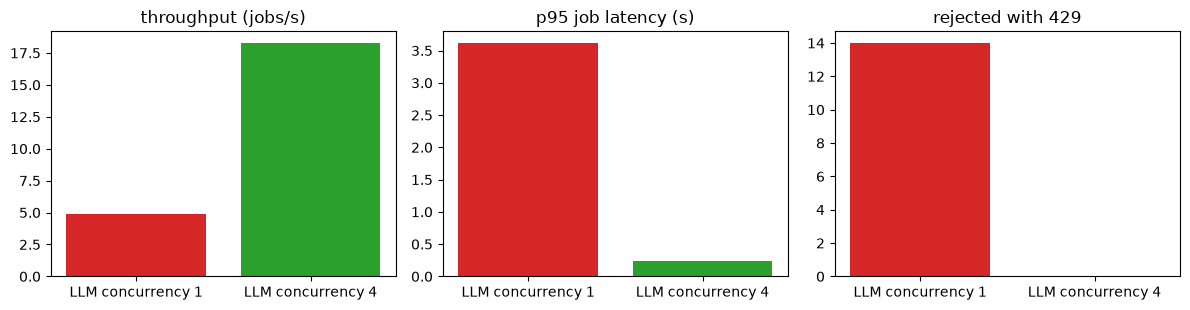

→ With 1 LLM call in flight the service could finish about 5 jobs/s against 20 arriving: the queue filled, 14 jobs got 429 + Retry-After, and p95 latency was 3.62s. With 4 in flight: 0 rejected, p95 0.23s, throughput 18.3 jobs/s. The peak in flight never exceeded the limit (1, 4).


In [38]:
async def load_test(base_url, tasks, n_jobs=40, rate_per_s=20.0):
    results = []
    limits = httpx.Limits(max_connections=n_jobs + 10, max_keepalive_connections=n_jobs + 10)
    async with httpx.AsyncClient(base_url=base_url, timeout=120, limits=limits) as http:
        async def one(i):
            await asyncio.sleep(i / rate_per_s)                        # open loop: job i is sent at i / rate seconds
            t0 = time.perf_counter()
            response = await http.post("/jobs", json=job_body(tasks[i % len(tasks)]))
            if response.status_code == 429:
                results.append({"job": i, "accepted": False, "retry_after": response.headers.get("retry-after")})
                return
            started, outcome = None, None
            async with http.stream("GET", f"/jobs/{response.json()['id']}/events") as stream:
                async for event in aparse_sse(stream.aiter_lines()):
                    if event["event"] == "started":
                        started = time.perf_counter() - t0
                    if event["event"] in ("finished", "failed", "cancelled"):
                        outcome = event["event"]
            results.append({"job": i, "accepted": True, "outcome": outcome, "queue_wait_s": started, "latency_s": time.perf_counter() - t0,
                            "done_at": time.perf_counter()})

        begin = time.perf_counter()
        await asyncio.gather(*(one(i) for i in range(n_jobs)))
        server_metrics = (await http.get("/metrics")).json()
    df = pd.DataFrame(results)
    done = df[df.accepted]
    return {"accepted": int(df.accepted.sum()), "rejected_429": int((~df.accepted).sum()),
            "throughput_jobs_per_s": len(done) / (done.done_at.max() - begin), "p50_latency_s": done.latency_s.quantile(0.5),
            "p95_latency_s": done.latency_s.quantile(0.95), "p95_queue_wait_s": done.queue_wait_s.quantile(0.95),
            "llm_peak_in_flight": server_metrics["llm_peak_in_flight"], "all_finished": bool((done.outcome == "finished").all())}


load_rows = {}
for llm_concurrency in (1, 4):
    env = {**SERVICE_ENV, "MODEL_MODE": "scripted", "SCRIPTED_LATENCY_S": "0.1", "WORKERS": "8", "LLM_CONCURRENCY": str(llm_concurrency), "QUEUE_MAX": "10"}
    with UvicornServer("supportkit.service:app", cwd=OUTPUT_DIR, env=env) as server:
        load_rows[f"LLM concurrency {llm_concurrency}"] = await load_test(server.base_url, DEV_TASKS)
load_df = pd.DataFrame(load_rows).T
print(load_df.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, column, title in zip(axes, ["throughput_jobs_per_s", "p95_latency_s", "rejected_429"], ["throughput (jobs/s)", "p95 job latency (s)", "rejected with 429"]):
    ax.bar(load_df.index, load_df[column].astype(float), color=["tab:red", "tab:green"])
    ax.set_title(title)
plt.tight_layout()
plt.show()
low, high = load_df.iloc[0], load_df.iloc[1]
print(f"→ With 1 LLM call in flight the service could finish about {1 / (2 * 0.1):.0f} jobs/s against 20 arriving: the queue filled, "
      f"{low.rejected_429} jobs got 429 + Retry-After, and p95 latency was {low.p95_latency_s:.2f}s. "
      f"With 4 in flight: {high.rejected_429} rejected, p95 {high.p95_latency_s:.2f}s, throughput {high.throughput_jobs_per_s:.1f} jobs/s. "
      f"The peak in flight never exceeded the limit ({low.llm_peak_in_flight}, {high.llm_peak_in_flight}).")

Backpressure is a feature: the 429s were **fast** and honest. Without a bounded queue, those jobs would have been accepted and waited far past any latency SLO, holding connections and memory. Clients should retry 429s with jittered backoff, honouring `Retry-After`. At scale, the same design becomes a durable queue (SQS, Redis Streams, Kafka, Postgres) with autoscaled workers and **per-tenant** concurrency limits, so one heavy customer can't starve the rest.

### ✍️ Your Turn

Write the admission decision. `admit(queue_depth, queue_max, drain_rate_per_s)` returns `(202, None)` when there is room (`queue_depth < queue_max`); otherwise `(429, retry_after)` where `retry_after` is the whole number of seconds until one slot frees up, `ceil(1 / drain_rate_per_s)`, and at least 1.

In [39]:
def admit(queue_depth, queue_max, drain_rate_per_s):
    return None  # TODO


check("admit", None if admit(0, 10, 5.0) is None else [admit(0, 10, 5.0), admit(10, 10, 5.0), admit(12, 10, 0.25), admit(9, 10, 0.1)],
      [(202, None), (429, 1), (429, 4), (202, None)], hint="if queue_depth < queue_max: (202, None); else (429, max(1, math.ceil(1 / drain_rate_per_s)))")

⏳ admit: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def admit(queue_depth, queue_max, drain_rate_per_s):
    if queue_depth < queue_max:
        return (202, None)
    return (429, max(1, math.ceil(1 / drain_rate_per_s)))


check("admit", [admit(0, 10, 5.0), admit(10, 10, 5.0), admit(12, 10, 0.25), admit(9, 10, 0.1)],
      [(202, None), (429, 1), (429, 4), (202, None)])
```

Real services also shed load **by priority** (reject free-tier batch jobs before paying interactive users) and cap the queue by *expected wait* (depth ÷ drain rate) rather than by a raw count.
</details>

> 💡 **Interview angle:** "How do you stream progress to users for a long-running agent?" — accept the task as a job (202 + id, idempotent submission), run it on background workers, and publish typed progress events (step started, tool called, partial answer, finished) over **SSE** with event ids so clients can resume with `Last-Event-ID`; poll `GET /jobs/{id}` as a fallback; send keep-alives; stop work when the client cancels. Protect the model with a concurrency limit and the service with a bounded queue that returns 429 + Retry-After.

## 7. Cost Engineering: Accounting, Cascades, Caching, Budgets 🟡

Agent cost = Σ over steps of (input tokens × input price + output tokens × output price), minus discounts for cached input. Four levers, in the order you should pull them:

1. **Measure per step** — where do the tokens go?
2. **Do less work per task** — route easy requests to cheap paths (rules, small models), escalate only when needed.
3. **Don't pay twice** — prompt caching (the provider reuses a stable prompt prefix) and response caching (you reuse whole answers).
4. **Cap the damage** — per-task and per-user budgets that stop runaway runs cleanly.

### Per-step token accounting

Every step re-sends the growing conversation, so input tokens dominate. The `gen_ai.usage.cache_read.input_tokens` attribute shows how much of each prompt the server served from its **prompt (KV) cache**: the stable prefix (system prompt + tool schemas + earlier turns) that [Context Engineering §8](02_Context_Engineering_and_Agent_Memory.ipynb) taught you to keep byte-identical. Hosted providers bill cached input at a discount.

In [40]:
chat_spans = BASELINE_SPANS[BASELINE_SPANS.op == "chat"].copy()
for column, key in [("step", "app.step"), ("input", GA.GEN_AI_USAGE_INPUT_TOKENS), ("cached", GA.GEN_AI_USAGE_CACHE_READ_INPUT_TOKENS), ("output", GA.GEN_AI_USAGE_OUTPUT_TOKENS)]:
    chat_spans[column] = chat_spans.attributes.map(lambda a, key=key: a.get(key, 0))
per_step = chat_spans.groupby("step").agg(calls=("input", "size"), input_tokens=("input", "mean"), cached_share=("cached", "sum"), output_tokens=("output", "mean"))
per_step["cached_share"] = per_step.cached_share / chat_spans.groupby("step").input.sum()
print(per_step.round(2).to_string())
totals = chat_spans[["input", "cached", "output"]].sum()
cost_with_cache = cost_usd(totals.input, totals.output, totals.cached)
cost_without_cache = cost_usd(totals.input, totals.output, 0)
print(f"\ninput tokens are {totals.input / (totals.input + totals.output):.0%} of all tokens and "
      f"{(totals.input - totals.cached) * EXAMPLE_PRICES['input'] / 1e6 / cost_with_cache:.0%} of the example cost (after cache discounts)")
print(f"prompt caching served {totals.cached / totals.input:.0%} of input tokens → example cost ${cost_with_cache:.4f} vs ${cost_without_cache:.4f} without it "
      f"({1 - cost_with_cache / cost_without_cache:.0%} cheaper) for the 12 baseline tasks")

      calls  input_tokens  cached_share  output_tokens
step                                                  
1        12        591.08          0.75          41.92
2        12        720.08          0.80          51.58
3         6        812.50          0.73          52.83

input tokens are 93% of all tokens and 27% of the example cost (after cache discounts)
prompt caching served 76% of input tokens → example cost $0.0224 vs $0.0402 without it (44% cheaper) for the 12 baseline tasks


### Model routing and cascades

A **cascade** tries the cheapest tier first and escalates only when a *confidence signal* says the answer can't be trusted. **FrugalGPT** and **RouteLLM** (see 📚) showed large savings on public benchmarks with learned routers. We don't have a second, smaller model on this server, so our tiers are honest stand-ins:

| Tier | What it is here | In production it would be |
|---|---|---|
| 0 · rules | regex intent + order id → call `get_order_details` → template reply; **no LLM** | rules, a classifier, or a FAQ lookup |
| 1 · cheap LLM | the baseline agent: gpt-oss-20b, `reasoning_effort="low"` | a small/fast model |
| 2 · strong LLM | the same model with `reasoning_effort="medium"` | a large model |

**Confidence signals must be observable at run time** (never the grade): tier 0 declines if it's unsure of the intent; tier 1 is accepted only if it ended with a final answer, saw no tool failures, and mentioned no order id that isn't in the request. To price the comparison we also run **tier 2 on every dev task** (these runs are the Section 8 candidate too).

In [41]:
from dataclasses import replace

MEDIUM_CONFIG = replace(AGENT_CONFIG, reasoning_effort="medium", prompt_version="v2")
SPANS.clear()
medium_rows = await asyncio.gather(*(run_task(t, config=MEDIUM_CONFIG) for t in DEV_TASKS))
medium = pd.DataFrame(medium_rows)
print(medium[["task", "category", "success", "stop", "llm_calls", "replayed", "tokens", "wall_s"]].to_string(index=False))

task category  success         stop  llm_calls  replayed  tokens  wall_s
 D01     info     True final_answer          2         2    1455    5.21
 D02     info     True final_answer          2         2    1499    7.89
 D03     info     True final_answer          2         2    1433    4.38
 D04   refund     True final_answer          3         3    2309    7.64
 D05   refund     True final_answer          3         3    2336    8.99
 D06   refund     True final_answer          3         3    2359    8.88
 D07 escalate     True final_answer          3         3    2474   12.27
 D08 escalate     True final_answer          3         3    2489   11.69
 D09 escalate     True final_answer          3         3    2482   11.97
 D10     deny     True final_answer          2         2    1435    5.46
 D11     deny     True final_answer          2         2    1438    4.76
 D12     deny     True final_answer          2         2    1469    5.25


In [42]:
ORDER_ID_RE = re.compile(r"#W\d{7}")
INFO_RE = re.compile(r"\b(status|tracking|where is)\b", re.I)
ACTION_RE = re.compile(r"\b(refund|return|money back|cancel)\b", re.I)


async def tier0_rules(task):
    """Handles plain order-status questions without an LLM. Returns a result row, or None to escalate."""
    order_ids = ORDER_ID_RE.findall(task.message)
    if len(order_ids) != 1 or not INFO_RE.search(task.message) or ACTION_RE.search(task.message):
        return None                                                   # not sure what the customer wants → next tier
    backend = store.SupportBackend(TEMPLATE_DB, task.customer_id)
    order = await backend.call("get_order_details", {"order_id": order_ids[0]})
    if "error" in order:
        backend.close()
        return None
    answer = (f"Your order {order['order_id']} is {order['status']}. "
              f"Tracking number: {', '.join(order['tracking_ids']) or 'not available yet'}.")
    row = {"task": task.task_id, "category": task.category, **store.grade(task, backend.end_state(), answer), "tokens": 0,
           "prompt_tokens": 0, "completion_tokens": 0, "cached_prompt_tokens": 0, "llm_calls": 0, "answer": answer}
    backend.close()
    return row


def confident(row, task):
    mentioned = set(ORDER_ID_RE.findall(row["answer"] or ""))
    return row["stop"] == "final_answer" and row["tool_failures"] == 0 and bool(row["answer"]) and mentioned <= set(ORDER_ID_RE.findall(task.message))


base_by_task, medium_by_task = baseline.set_index("task"), medium.set_index("task")
cascade_rows = []
for task in DEV_TASKS:
    row0 = await tier0_rules(task)
    if row0 is not None:
        cascade_rows.append({**row0, "tier": "0 rules"})
        continue
    row1 = base_by_task.loc[task.task_id].to_dict() | {"task": task.task_id}
    if confident(row1, task):
        cascade_rows.append({**row1, "tier": "1 low effort"})
        continue
    row2 = medium_by_task.loc[task.task_id].to_dict() | {"task": task.task_id}
    for key in ("tokens", "prompt_tokens", "completion_tokens", "cached_prompt_tokens", "llm_calls"):   # escalation pays for both tiers
        row2[key] = row1[key] + row2[key]
    cascade_rows.append({**row2, "tier": "2 medium effort"})
cascade = pd.DataFrame(cascade_rows)


def arm_summary(df, name):
    costs = [cost_usd(r.prompt_tokens, r.completion_tokens, r.cached_prompt_tokens) for r in df.itertuples()]
    return {"arm": name, "success": df.success.mean(), "LLM calls / task": df.llm_calls.mean(), "tokens / task": df.tokens.mean(),
            "example cost / task $": np.mean(costs)}


cost_table = pd.DataFrame([arm_summary(medium, "always tier 2 (medium effort)"), arm_summary(baseline, "always tier 1 (low effort)"),
                           arm_summary(cascade, "cascade: rules → low → medium")]).set_index("arm")
print(cost_table.round(5).to_string())
print("\ntasks handled per tier:", cascade.tier.value_counts().to_dict())
saving_vs_strong = 1 - cost_table.iloc[2]["example cost / task $"] / cost_table.iloc[0]["example cost / task $"]
saving_vs_cheap = 1 - cost_table.iloc[2]["example cost / task $"] / cost_table.iloc[1]["example cost / task $"]
print(f"→ On these 12 tasks the cascade cost {saving_vs_strong:.0%} less than always using tier 2 and {saving_vs_cheap:.0%} less than always using tier 1, "
      f"with success {cost_table.iloc[2].success:.0%} vs {cost_table.iloc[0].success:.0%} and {cost_table.iloc[1].success:.0%}.")
if (cascade.tier == "2 medium effort").sum() == 0:
    print("→ No task needed tier 2 on this run: every tier-1 answer passed the confidence checks. The tier exists for the ones that won't.")

                               success  LLM calls / task  tokens / task  example cost / task $
arm                                                                                           
always tier 2 (medium effort)      1.0               2.5     1931.50000                0.00269
always tier 1 (low effort)         1.0               2.5     1837.33333                0.00187
cascade: rules → low → medium      1.0               2.0     1486.00000                0.00154

tasks handled per tier: {'1 low effort': 9, '0 rules': 3}
→ On these 12 tasks the cascade cost 43% less than always using tier 2 and 17% less than always using tier 1, with success 100% vs 100% and 100%.
→ No task needed tier 2 on this run: every tier-1 answer passed the confidence checks. The tier exists for the ones that won't.


### Response caching: exact first, semantic with care

**Exact caching** reuses a previous answer when the *same* request comes again. The key must contain everything that changes the answer: who is asking, the normalized request, the **config id**, and a **data version** for the facts used. Never cache requests with side effects ("refund my order").

We replay 60 read-only requests (order questions and policy questions from the dev set, a few popular ones repeated, as in real traffic). Halfway through, the most popular order changes status, which bumps its data version.

In [43]:
readonly = [t for t in DEV_TASKS if t.category in ("info", "deny")]
weights = 1 / np.arange(1, len(readonly) + 1)
traffic = np.random.default_rng(SEED).choice(len(readonly), size=60, p=weights / weights.sum())
CHANGE_AT, changed_order = 30, readonly[int(np.bincount(traffic).argmax())].order_id


def replay_response_cache(include_data_version):
    cache, hits, stale, tokens_saved = {}, 0, 0, 0
    for i, index in enumerate(traffic):
        task = readonly[index]
        version = 2 if (task.order_id == changed_order and i >= CHANGE_AT) else 1
        key = (task.customer_id, " ".join(task.message.lower().split()), AGENT_CONFIG.config_id()) + ((version,) if include_data_version else ())
        if key in cache:
            hits += 1
            tokens_saved += int(base_by_task.loc[task.task_id, "tokens"])
            stale += cache[key] != version                             # served an answer computed from old data
        else:
            cache[key] = version
    return {"hit rate": hits / len(traffic), "tokens saved": tokens_saved, "stale answers served": stale}


cache_table = pd.DataFrame({"key without data version": replay_response_cache(False), "key with data version": replay_response_cache(True)}).T
print(cache_table.to_string())
print(f"→ Tokens without any cache: {sum(int(base_by_task.loc[readonly[i].task_id, 'tokens']) for i in traffic):,}. "
      "The data version costs a few hits and prevents stale answers.")

                          hit rate  tokens saved  stale answers served
key without data version  0.900000       75806.0                  13.0
key with data version     0.883333       74385.0                   0.0
→ Tokens without any cache: 84,181. The data version costs a few hits and prevents stale answers.


**Semantic caching** matches requests by *meaning* (embedding similarity) instead of exact text, so paraphrases hit too. The risk: requests that *look* alike but differ in one crucial detail. We embed real order questions with `all-MiniLM-L6-v2` and compare two kinds of pairs: **paraphrases about the same order** (a hit is correct) and **the same wording about a different order** (a hit returns someone else's order status).

In [44]:
from huggingface_hub.utils import logging as hf_logging
from sentence_transformers import SentenceTransformer

hf_logging.set_verbosity_error()                                   # hide the Hub's 'unauthenticated requests' notice (the model is public)
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cpu")
info_tasks_all = [t for t in DEV_TASKS + TEST_TASKS if t.category == "info"]
PARAPHRASES = ["Can you check order {oid} for me? I need its current status and the tracking number.",
               "Tracking number and delivery status for {oid}, please."]
same_order_pairs = [(t.message, p.format(oid=t.order_id), t.order_id, t.order_id) for t in info_tasks_all for p in PARAPHRASES]
other_order_pairs = [(a.message, a.message.replace(a.order_id, b.order_id), a.order_id, b.order_id)
                     for a in info_tasks_all for b in info_tasks_all if a.order_id != b.order_id]
texts = sorted({text for pair in same_order_pairs + other_order_pairs for text in pair[:2]})
vectors = dict(zip(texts, embedder.encode(texts, normalize_embeddings=True, show_progress_bar=False)))
similarity = lambda a, b: float(vectors[a] @ vectors[b])
same_sims = np.array([similarity(a, b) for a, b, _, _ in same_order_pairs])
other_sims = np.array([similarity(a, b) for a, b, _, _ in other_order_pairs])
semantic_rows = []
for threshold in (0.80, 0.85, 0.90, 0.95, 0.98):
    semantic_rows.append({"threshold": threshold, "paraphrase hits (good)": (same_sims >= threshold).mean(),
                          "different-order hits (WRONG answer)": (other_sims >= threshold).mean(),
                          "entity-aware: different-order hits": 0.0})      # key also requires the same order id → never matches
print(f"{len(same_order_pairs)} paraphrase pairs (similarity {same_sims.min():.2f}–{same_sims.max():.2f}) | "
      f"{len(other_order_pairs)} different-order pairs (similarity {other_sims.min():.2f}–{other_sims.max():.2f})")
print(pd.DataFrame(semantic_rows).to_string(index=False))
del embedder

16 paraphrase pairs (similarity 0.82–0.92) | 56 different-order pairs (similarity 0.90–0.98)
 threshold  paraphrase hits (good)  different-order hits (WRONG answer)  entity-aware: different-order hits
      0.80                  1.0000                             1.000000                                 0.0
      0.85                  0.6875                             1.000000                                 0.0
      0.90                  0.3750                             1.000000                                 0.0
      0.95                  0.0000                             0.410714                                 0.0
      0.98                  0.0000                             0.053571                                 0.0


Changing only the order number barely moves the embedding, so a text-only semantic cache would serve wrong orders at *any* threshold that still catches paraphrases. Fixes: put **entities and user id in the key** and use similarity only for the wording, restrict semantic caching to user-independent content (FAQs, policy text), and monitor hit correctness with sampled audits.

### Budgets and early termination

A runaway agent (a tool that keeps returning "try again", a model stuck re-checking) can burn hundreds of steps. A **budget** is checked before every LLM call and stops the run with a clear reason. Here is a stand-in "looping" model whose per-step token counts are taken from the baseline's measured growth, with and without a per-task token cap.

In [45]:
step1 = chat_spans[chat_spans.step == 1]
growth_per_step = (chat_spans.groupby("step").input.mean().diff().dropna().mean())
LOOP_SHAPE = {"first_prompt": int(step1.input.mean()), "growth": int(growth_per_step), "completion": int(chat_spans.output.mean())}


class LoopingLLM:
    """A stand-in model that never stops calling tools. Token counts follow the baseline's measured shape."""

    def __init__(self, first_prompt, growth, completion):
        self.first_prompt, self.growth, self.completion = first_prompt, growth, completion

    async def chat(self, messages, **kwargs):
        step = sum(m["role"] == "assistant" for m in messages)
        order_id = ORDER_ID_RE.search(messages[1]["content"]).group(0)
        message = {"role": "assistant", "content": None, "tool_calls": [{"id": f"loop_{step}", "type": "function",
                   "function": {"name": "get_order_details", "arguments": json.dumps({"order_id": order_id})}}]}
        return kit_llm.LLMReply(message, "tool_calls", self.first_prompt + self.growth * step, self.completion, 0, 0.0, 0.0)


class TokenCap:
    def __init__(self, max_tokens):
        self.max_tokens, self.used = max_tokens, 0

    def record(self, reply):
        self.used += reply.prompt_tokens + reply.completion_tokens

    def exceeded(self):
        return "task_token_budget" if self.used >= self.max_tokens else None


TOKEN_CAP = int(3 * baseline.tokens.max())                            # 3× the largest normal task
loop_task = TASK_BY_ID["D01"]
budget_rows = []
for label, budget in [("no budget (max_steps=25)", None), (f"TokenCap({TOKEN_CAP:,})", TokenCap(TOKEN_CAP))]:
    backend = store.SupportBackend(TEMPLATE_DB, loop_task.customer_id)
    result = await agent.run_agent(loop_task.message, llm=LoopingLLM(**LOOP_SHAPE), backend=backend, config=replace(AGENT_CONFIG, max_steps=25), budget=budget)
    backend.close()
    budget_rows.append({"run": label, "stop reason": result.stop_reason, "LLM calls": result.llm_calls, "tokens": result.tokens,
                        "example cost $": round(cost_usd(result.prompt_tokens, result.completion_tokens), 4)})
print(f"looping-model shape from the baseline: {LOOP_SHAPE}")
print(pd.DataFrame(budget_rows).to_string(index=False))
print(f"normal tasks used {baseline.tokens.min():,}–{baseline.tokens.max():,} tokens, so the cap would not have stopped any of the 12 baseline tasks "
      f"({int((baseline.tokens >= TOKEN_CAP).sum())} affected).")

looping-model shape from the baseline: {'first_prompt': 591, 'growth': 110, 'completion': 47}
                     run              stop reason  LLM calls  tokens  example cost $
no budget (max_steps=25)                max_steps         25   48950          0.0715
         TokenCap(6,924) budget:task_token_budget          8    8184          0.0135
normal tasks used 1,381–2,308 tokens, so the cap would not have stopped any of the 12 baseline tasks (0 affected).


Quadratic growth is why loops are expensive: each extra step re-sends everything before it. Set the cap from **measured** distributions (a multiple of p99 task tokens), stop *before* a call that would cross it, and return a partial answer or an escalation instead of an error. 🔧 builds a budget enforcer with per-task tokens, cost, calls and a per-user daily budget.

### ✍️ Your Turn

Expected cost per request of a 3-tier cascade. Every request pays tier 0 (`c0`). A share `h0` is handled there; the rest pay tier 1 (`c1`). Of those, a share `e` is escalated and also pays tier 2 (`c2`). Write `cascade_cost(c0, c1, c2, h0, e)`.

In [46]:
def cascade_cost(c0, c1, c2, h0, e):
    return None  # TODO


check("cascade_cost", None if cascade_cost(0.0001, 0.002, 0.02, 0.3, 0.1) is None else round(cascade_cost(0.0001, 0.002, 0.02, 0.3, 0.1), 6),
      0.0029, hint="c0 + (1 - h0) * (c1 + e * c2)")

⏳ cascade_cost: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def cascade_cost(c0, c1, c2, h0, e):
    return c0 + (1 - h0) * (c1 + e * c2)


check("cascade_cost", round(cascade_cost(0.0001, 0.002, 0.02, 0.3, 0.1), 6), 0.0029)
print("always tier 2:", 0.02, "| break-even escalation share:", round((0.02 - 0.0001 - 0.7 * 0.002) / (0.7 * 0.02), 3))
```

0.0001 + 0.7 × (0.002 + 0.1 × 0.02) = 0.0029, about 7× cheaper than sending everything to tier 2. The cascade stops paying off once escalations get so frequent that the cheap tier is mostly wasted work.
</details>

> 💡 **Interview angle:** "How do you control agent cost?" — measure tokens per step and per task by config; cut work with routing/cascades (rules or a small model first, escalate on observable low confidence); keep prompt prefixes stable for prompt caching; cache exact responses for read-only requests with the config id and data version in the key (semantic caching only with entities in the key); trim context and tool outputs; cap tokens/cost/steps per task and per user with clean stops; alert on cost per task. Report savings measured on a task set *with* success rates, never cost alone.

## 8. Versioning and Rollout: Configs, Eval Gates, Shadow, Canary, A/B 🟡

An agent's behaviour is defined by more than code: the **prompt**, the **tool schemas**, the **model** and its **settings**. Treat all of them as one **versioned config** with an id, put that id on every span, and release changes the way you release code:

```
 edit config ─► offline eval gate ─► shadow traffic ─► canary (1–5%) ─► ramp (25% → 50% → 100%) ─► done
                 (labelled task set)   (no side effects)  (guardrail metrics)   (A/B if the goal is a product metric)
                       │                    │                  │
                       └──── block ─────────┴──── rollback: move the alias back to the previous config id
```

In [47]:
CONFIG_DIR = OUTPUT_DIR / "configs"
CONFIG_DIR.mkdir(exist_ok=True)


def register_config(config, note):
    config_id = config.config_id()
    record = {**asdict(config), "config_id": config_id, "tool_schema_sha": store.sha256(store.canonical_json(store.TOOL_SPECS))[:12], "note": note}
    (CONFIG_DIR / f"{config.name}@{config_id}.json").write_text(json.dumps(record, indent=1))
    return config_id


ALIASES = {"production": register_config(AGENT_CONFIG, "baseline: effort low"),
           "candidate": register_config(MEDIUM_CONFIG, "candidate: effort medium")}
one_word = replace(AGENT_CONFIG, system_prompt=AGENT_CONFIG.system_prompt.replace("at most three sentences", "at most two sentences"))
print("aliases:", ALIASES)
print(f"changing ONE word of the prompt → new config id {one_word.config_id()} (was {AGENT_CONFIG.config_id()})")
print("registry:", sorted(p.name for p in CONFIG_DIR.glob("*.json")))

aliases: {'production': '24a92ff7dc4c', 'candidate': '1fd2191f6c95'}
changing ONE word of the prompt → new config id f36d715c429f (was 24a92ff7dc4c)
registry: ['support-agent@1fd2191f6c95.json', 'support-agent@24a92ff7dc4c.json']


### Eval gate before deploy

The candidate (`reasoning_effort="medium"`) must not be worse on the labelled dev set than production, and must stay within cost and latency limits. With 12 tasks the gate is a smoke test; [Agent Evaluation and Benchmarks](06_Agent_Evaluation_and_Benchmarks.ipynb) covers statistically sound gates (paired comparisons, pass^k, CIs) and CI integration.

In [48]:
GATE = {"max_tasks_lost": 0, "max_cost_ratio": 1.25, "max_p95_latency_ratio": 1.5}


def eval_gate(candidate_rows, baseline_rows, gate=GATE):
    cand, base = pd.DataFrame(candidate_rows).set_index("task"), pd.DataFrame(baseline_rows).set_index("task")
    lost = sorted(t for t in base.index if base.loc[t, "success"] and not cand.loc[t, "success"])
    cost = lambda df: np.mean([cost_usd(r.prompt_tokens, r.completion_tokens, r.cached_prompt_tokens) for r in df.itertuples()])
    checks = [("tasks production solved but candidate failed", len(lost), gate["max_tasks_lost"]),
              ("cost ratio (candidate / production)", cost(cand) / cost(base), gate["max_cost_ratio"]),
              ("p95 latency ratio", cand.wall_s.quantile(0.95) / base.wall_s.quantile(0.95), gate["max_p95_latency_ratio"])]
    table = pd.DataFrame([{"check": name, "value": round(float(value), 3), "limit": limit, "pass": value <= limit} for name, value, limit in checks])
    return ("✅ promote to shadow/canary" if table["pass"].all() else "⛔ block the release"), table, lost


decision, gate_table, lost_tasks = eval_gate(medium_rows, baseline_rows)
print(gate_table.to_string(index=False))
print(f"\ndecision: {decision} | lost tasks: {lost_tasks} | success production {baseline.success.mean():.0%} vs candidate {medium.success.mean():.0%}")

                                       check  value  limit  pass
tasks production solved but candidate failed  0.000   0.00  True
         cost ratio (candidate / production)  1.438   1.25 False
                           p95 latency ratio  1.570   1.50 False

decision: ⛔ block the release | lost tasks: [] | success production 100% vs candidate 100%


### Shadow traffic

In **shadow mode** the candidate processes a copy of real requests, but its side effects are **recorded, not executed** (our backend's `dry_run=True`), and users only ever see production's answer. You compare decisions before any customer is exposed. Here: the candidate shadows two refund tasks and one escalation, and we compare its intended writes with what production actually did in the baseline.

In [49]:
shadow_rows = []
for task in [t for t in DEV_TASKS if t.category == "refund"][:2] + [t for t in DEV_TASKS if t.category == "escalate"][:1]:
    shadow = await run_task(task, config=MEDIUM_CONFIG, dry_run=True, scope=f"shadow-{task.task_id}")
    production = base_by_task.loc[task.task_id, "end_state"]
    intended_refunds = sorted((w[1], w[2], w[3]) for w in shadow["shadow_writes"] if w[0] == "refund")
    intended_tickets = sorted(w[1] for w in shadow["shadow_writes"] if w[0] == "ticket")
    production_refunds = sorted((r[0], tuple(r[1]), r[2]) for r in production["refunds"])
    shadow_rows.append({"task": task.task_id, "candidate intends": shadow["shadow_writes"], "production did": production_refunds or production["tickets"],
                        "agree": intended_refunds == production_refunds and intended_tickets == sorted(production["tickets"]),
                        "ledger rows written by shadow": shadow["refunds"], "LLM calls": shadow["llm_calls"], "replayed": shadow["replayed"]})
shadow_df = pd.DataFrame(shadow_rows)
print(shadow_df.to_string(index=False))
print(f"→ shadow agreement {shadow_df.agree.mean():.0%} on {len(shadow_df)} tasks, and the shadow wrote {shadow_df['ledger rows written by shadow'].sum()} real ledger rows.")

task                            candidate intends                       production did  agree  ledger rows written by shadow  LLM calls  replayed
 D04  [(refund, #W6067464, (9624127908,), 158.9)]  [(#W6067464, (9624127908,), 158.9)]   True                              0          3         3
 D05 [(refund, #W9389413, (4127323219,), 251.82)] [(#W9389413, (4127323219,), 251.82)]   True                              0          3         3
 D07                        [(ticket, #W8209112)]                          [#W8209112]   True                              0          3         3
→ shadow agreement 100% on 3 tasks, and the shadow wrote 0 real ledger rows.


### Canary and A/B tests

A **canary** sends a small, *sticky* share of users to the candidate (the same user always gets the same version, so conversations don't flip between versions) and watches **guardrail metrics**: error rate, cost per task, escalation rate, latency. Breach a guardrail → roll back automatically. Assignment uses a hash of the user id and a salt, not `random()`.

In [50]:
def assign_bucket(user_id, salt="support-agent@canary-1"):
    return int(store.sha256(f"{salt}|{user_id}")[:8], 16) % 100


with sqlite3.connect(TEMPLATE_DB) as con:
    all_users = [u for (u,) in con.execute("SELECT user_id FROM users")]
in_canary = [u for u in all_users if assign_bucket(u) < 5]
print(f"5% canary → {len(in_canary)} of {len(all_users)} τ-bench users ({len(in_canary) / len(all_users):.1%}); "
      f"sticky: {all(assign_bucket(u) < 5 for u in in_canary)}; a new salt moves {sum((assign_bucket(u, 'canary-2') < 5) != (assign_bucket(u) < 5) for u in all_users)} users")

GUARDRAILS = {"error_rate": ("abs_increase", 0.02), "cost_per_task": ("ratio", 1.20), "escalation_rate": ("abs_increase", 0.05)}


def canary_decision(control, canary, guardrails=GUARDRAILS, min_tasks=200):
    if canary["tasks"] < min_tasks:
        return "⏳ wait: not enough canary traffic yet", []
    metrics = lambda c: {"error_rate": c["failures"] / c["tasks"], "cost_per_task": c["cost_usd"] / c["tasks"], "escalation_rate": c["escalations"] / c["tasks"]}
    ctl, can = metrics(control), metrics(canary)
    breaches = []
    for name, (kind, limit) in guardrails.items():
        change = can[name] - ctl[name] if kind == "abs_increase" else can[name] / ctl[name]
        if change > limit:
            breaches.append(f"{name}: {ctl[name]:.4f} → {can[name]:.4f}")
    return ("🔙 roll back: move the alias to the previous config" if breaches else "✅ ramp up to the next stage"), breaches


example_control = {"tasks": 9_500, "failures": 380, "cost_usd": 18.1, "escalations": 1_140}     # example dashboard counts after one hour
for label, example_canary in [("healthy candidate", {"tasks": 500, "failures": 21, "cost_usd": 1.02, "escalations": 61}),
                              ("costly candidate", {"tasks": 500, "failures": 22, "cost_usd": 1.61, "escalations": 58}),
                              ("too early", {"tasks": 120, "failures": 3, "cost_usd": 0.2, "escalations": 12})]:
    print(f"{label:18s} → {canary_decision(example_control, example_canary)}")

5% canary → 22 of 500 τ-bench users (4.4%); sticky: True; a new salt moves 46 users
healthy candidate  → ('✅ ramp up to the next stage', [])
costly candidate   → ('🔙 roll back: move the alias to the previous config', ['cost_per_task: 0.0019 → 0.0032'])
too early          → ('⏳ wait: not enough canary traffic yet', [])


A canary asks "is it **safe**?". An **A/B test** asks "is it **better** for users?", so it needs a pre-registered metric and enough samples. How many tasks per arm to detect a success-rate improvement from 85% to 90% (two-sided α = 0.05, power 80%)?

In [51]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

p_control, p_treatment, z_alpha, z_power = 0.85, 0.90, 1.959964, 0.841621
p_bar = (p_control + p_treatment) / 2
n_formula = ((z_alpha * math.sqrt(2 * p_bar * (1 - p_bar)) + z_power * math.sqrt(p_control * (1 - p_control) + p_treatment * (1 - p_treatment))) ** 2
             / (p_treatment - p_control) ** 2)
n_statsmodels = NormalIndPower().solve_power(effect_size=proportion_effectsize(p_treatment, p_control), alpha=0.05, power=0.8)
print(f"tasks per arm: {math.ceil(n_formula)} (classic two-proportion formula) | {math.ceil(n_statsmodels)} (statsmodels, arcsine effect size)")
print(f"→ Our 12-task gate can catch a disaster, not a 5-point improvement: that takes ~{math.ceil(n_formula) * 2:,} tasks across both arms.")

tasks per arm: 686 (classic two-proportion formula) | 681 (statsmodels, arcsine effect size)
→ Our 12-task gate can catch a disaster, not a 5-point improvement: that takes ~1,372 tasks across both arms.


### ✍️ Your Turn

Write `in_rollout(user_id, percent, salt)`: `True` when the user's bucket (`int(sha256(f"{salt}|{user_id}")[:8], 16) % 100`, use `store.sha256`) is **below** `percent`. Ramping from 5% to 25% must keep every 5% user in the rollout. The checker tests that and the share.

In [52]:
def in_rollout(user_id, percent, salt="support-agent@v2"):
    return None  # TODO


check("in_rollout", None if in_rollout(all_users[0], 5) is None else (
    all(in_rollout(u, 25) for u in all_users if in_rollout(u, 5)),                 # ramping up never removes anyone
    0.15 <= np.mean([in_rollout(u, 25) for u in all_users]) <= 0.35,               # roughly 25%
    in_rollout(all_users[1], 100) and not in_rollout(all_users[1], 0)),
    (True, True, True), hint="return int(store.sha256(f'{salt}|{user_id}')[:8], 16) % 100 < percent")

⏳ in_rollout: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def in_rollout(user_id, percent, salt="support-agent@v2"):
    return int(store.sha256(f"{salt}|{user_id}")[:8], 16) % 100 < percent


check("in_rollout", (
    all(in_rollout(u, 25) for u in all_users if in_rollout(u, 5)),
    0.15 <= np.mean([in_rollout(u, 25) for u in all_users]) <= 0.35,
    in_rollout(all_users[1], 100) and not in_rollout(all_users[1], 0)),
    (True, True, True))
```

Because the bucket is fixed per user and salt, "bucket < 5" is a subset of "bucket < 25": a ramp only ever adds users. Change the salt for a *new* experiment so the same users aren't always the guinea pigs.
</details>

> 💡 **Interview angle:** "How do you roll out a new prompt or model safely?" — version prompt + tools + model + settings as one config id on every span; run an offline eval gate on a labelled set (block on regressions, cost and latency limits); shadow real traffic with side effects disabled; canary 1–5% of users with sticky hashing and automatic rollback on guardrail breaches (errors, cost, escalations, latency); A/B test with a pre-registered metric and a power calculation if the goal is "better"; roll back by moving an alias, not by redeploying.

## 9. Operations: Escalation, Alerts, Runbooks, Retention 🟢

Production is a loop with humans in it: users give feedback, agents hand hard cases to people, alerts wake the on-call engineer, runbooks tell them what to do, and data policies decide what you keep.

### Human escalation and feedback capture

An **escalation** should carry everything a human needs so they don't start from zero: the request, what the agent tried, why it stopped, and the **trace id**. **Feedback** (thumbs up/down, corrections, a human's final resolution) must be stored **with the trace id and config id**, so it can be joined to traces, sliced by release, and turned into new evaluation tasks.

In [53]:
FEEDBACK_DB = OUTPUT_DIR / "feedback.sqlite"
FEEDBACK_DB.unlink(missing_ok=True)
with sqlite3.connect(FEEDBACK_DB) as con:
    con.execute("CREATE TABLE feedback(trace_id TEXT, config_id TEXT, task_id TEXT, source TEXT, rating INTEGER, comment TEXT, at TEXT DEFAULT CURRENT_TIMESTAMP)")

escalated_trace = BASELINE_SPANS[(BASELINE_SPANS.op == "execute_tool") &
                                 (BASELINE_SPANS.attributes.map(lambda a: a.get(GA.GEN_AI_TOOL_NAME)) == "transfer_to_human_agents")].iloc[0]
root = BASELINE_SPANS[(BASELINE_SPANS.trace_id == escalated_trace.trace_id) & (BASELINE_SPANS.op == "invoke_workflow")].iloc[0]
agent_span = BASELINE_SPANS[(BASELINE_SPANS.trace_id == escalated_trace.trace_id) & (BASELINE_SPANS.op == "invoke_agent")].iloc[0]
ticket = {"task_id": root.attributes["app.task.id"], "trace_id": root.trace_id, "config_id": agent_span.attributes["app.config.id"],
          "reason": "policy: refund over the automatic limit", "tools_called": BASELINE_SPANS[(BASELINE_SPANS.trace_id == root.trace_id) & (BASELINE_SPANS.op == "execute_tool")].name.tolist(),
          "user": agent_span.attributes["app.user.id"]}
print("escalation ticket:", json.dumps(ticket, indent=1))

with sqlite3.connect(FEEDBACK_DB) as con:                      # two example entries, typed in to show the plumbing (not real user feedback)
    con.execute("INSERT INTO feedback(trace_id, config_id, task_id, source, rating, comment) VALUES (?,?,?,?,?,?)",
                (ticket["trace_id"], ticket["config_id"], ticket["task_id"], "human_agent", 1, "resolved: refund approved by a supervisor"))
    con.execute("INSERT INTO feedback(trace_id, config_id, task_id, source, rating, comment) VALUES (?,?,?,?,?,?)",
                (BASELINE_SPANS.trace_id.iloc[0], ticket["config_id"], "n/a", "end_user", -1, "answer was too long"))
    joined = pd.read_sql_query("SELECT source, rating, comment, config_id, substr(trace_id, 1, 12) AS trace FROM feedback", con)
print(joined.to_string(index=False))

escalation ticket: {
 "task_id": "D07",
 "trace_id": "dd5cf9ccef91b5df0a8a8833b1f45fd9",
 "config_id": "24a92ff7dc4c",
 "reason": "policy: refund over the automatic limit",
 "tools_called": [
  "execute_tool check_return_policy",
  "execute_tool transfer_to_human_agents"
 ],
 "user": "u_d34257b2e3"
}
     source  rating                                   comment    config_id        trace
human_agent       1 resolved: refund approved by a supervisor 24a92ff7dc4c dd5cf9ccef91
   end_user      -1                       answer was too long 24a92ff7dc4c 9aa239ca7d97


### Alerts on SLO burn rate

Alerting on every failure pages people for noise; alerting on a daily average finds incidents hours late. The Google SRE workbook recommends **multi-window, multi-burn-rate alerts**. **Burn rate** = observed error rate ÷ error budget rate (a burn rate of 1 uses exactly the whole budget over the SLO window). Page only when **both** a long window and a short window burn fast: the long window proves it's significant, the short window proves it's still happening.

| Severity | Long window | Short window | Burn rate | Budget used when it fires (30-day SLO) |
|---|---|---|---|---|
| page | 1 h | 5 min | 14.4 | 2% |
| page | 6 h | 30 min | 6 | 5% |
| ticket | 3 days | 6 h | 1 | 10% |

We check these rules against a **controlled example timeline** (built on purpose to show the behaviour, not measured): a 99.9% success SLO, 1,000 tasks/minute, 0.05% background failures, a **sharp incident** (10% failures for 45 minutes) on day 3.5 and a **slow burn** (0.4% failures for 12 hours) on day 6.6. The timeline is 7.5 days long, so even the 3-day window is full when the incidents start.

In [54]:
SLO_TARGET = 0.999
minutes = np.arange(int(7.5 * 24 * 60))
INCIDENT, SLOW_BURN = (5_000, 45, 0.10), (9_500, 12 * 60, 0.004)                # (start minute, duration in minutes, failure rate)
error_rate = np.full(minutes.shape, 0.0005)
for start_minute, duration, rate in (INCIDENT, SLOW_BURN):
    error_rate[(minutes >= start_minute) & (minutes < start_minute + duration)] = rate
timeline = pd.DataFrame({"requests": 1_000.0, "errors": 1_000.0 * error_rate}, index=minutes)


def burn(window_minutes):
    rolling = timeline.rolling(window_minutes, min_periods=window_minutes).sum()     # only full windows count
    return (rolling.errors / rolling.requests) / (1 - SLO_TARGET)


def first_firing(firing, start_minute, end_minute):
    window = firing[(firing.index >= start_minute) & (firing.index < end_minute)]
    return int(window.idxmax() - start_minute) if window.any() else None


ALERT_RULES = [("page 1h/5m", 60, 5, 14.4), ("page 6h/30m", 360, 30, 6.0), ("ticket 3d/6h", 3 * 24 * 60, 360, 1.0)]
alert_rows = []
for name, long_w, short_w, threshold in ALERT_RULES:
    firing = (burn(long_w) >= threshold) & (burn(short_w) >= threshold)
    alert_rows.append({"rule": name, "sharp incident": first_firing(firing, INCIDENT[0], SLOW_BURN[0]),
                       "slow burn": first_firing(firing, SLOW_BURN[0], len(minutes)), "background noise": first_firing(firing, 0, INCIDENT[0])})
shown = pd.DataFrame([{k: (v if k == "rule" else ("did not fire" if v is None else f"fired after {v} min")) for k, v in row.items()} for row in alert_rows])
print(shown.to_string(index=False))
for row in alert_rows:
    caught = [label for label in ("sharp incident", "slow burn") if row[label] is not None]
    print(f"→ {row['rule']:13s} caught: {caught or 'nothing'}; fired on background noise: {row['background noise'] is not None}")

        rule     sharp incident           slow burn background noise
  page 1h/5m  fired after 8 min        did not fire     did not fire
 page 6h/30m fired after 19 min        did not fire     did not fire
ticket 3d/6h fired after 21 min fired after 617 min     did not fire
→ page 1h/5m    caught: ['sharp incident']; fired on background noise: False
→ page 6h/30m   caught: ['sharp incident']; fired on background noise: False
→ ticket 3d/6h  caught: ['sharp incident', 'slow burn']; fired on background noise: False


Read the table: fast-burn pages react to sharp incidents within minutes, the slow burn only trips the long-window ticket rule hours later, and background noise trips nothing. That is the design: page for what spends the budget fast, ticket for what spends it slowly. For agents, alert on **task success burn**, **p95 latency**, **cost per task** (a cost spike is an incident) and **tool error rate** per dependency.

### Runbooks

A runbook turns an alert into steps anyone on call can follow at 3 a.m. Four agent-specific ones:

| Incident | Detect (signal) | First actions (mitigate) | Diagnose with traces | Prevent |
|---|---|---|---|---|
| **Agent loops** | steps/task p95 jumps; budget stops ↑; cost per task ↑ | lower `max_steps`/token caps via config; roll back the last config | traces with most `chat` spans: repeated tool + args? empty tool results? truncated context? | repeated-action + no-progress guards (16/01), clear "not found" tool results |
| **Cost spike** | cost per task or per user above alert; token usage by config | enforce per-user caps; route traffic to the cheaper tier; disable a feature flag | group spans by config id, user, task type; look for long prompts, cache-hit drops (prefix changed?) | budgets, prompt-cache-friendly prefixes, cost gate in releases |
| **Provider outage** | LLM error rate / latency burn; circuit breaker open | fail over to a secondary model/provider (pre-tested config); shed low-priority jobs; show "degraded" status | error.type on `chat` spans (429 vs 5xx vs timeout); provider status page | multi-provider configs, breakers, queue with deadlines, graceful degradation |
| **Prompt-injection incident** | guardrail/red-team alerts; unusual tool calls (refunds to new payment ids, data exfiltration patterns) | disable affected tools (kill switch); require human approval for writes; preserve traces (legal hold) | find the injected content in tool results/retrieval spans; list affected users and actions | least privilege, dual-LLM/CaMeL-style data flow, allow-lists (16/07) |

### Trace retention, audit logs and user-data deletion

| Data | Typical retention | Why |
|---|---|---|
| captured prompt/tool **content** (redacted) | days to weeks | debugging only; highest privacy risk |
| spans **without** content (timings, tokens, ids) | weeks to months | SLOs, capacity, cost analysis |
| aggregated metrics | 13+ months | trends, year-over-year |
| **audit log** of consequential actions (refunds, config promotions, deletions) | as long as regulation requires | accountability; must be tamper-evident |

Two operations you must be able to run on demand: **delete one user's data** everywhere (a GDPR/CCPA-style request), and **prove the audit log wasn't edited**. Pseudonymous user ids on spans make the first possible; a **hash chain** (each entry stores the hash of the previous one) makes edits detectable.

In [55]:
user_pseudonym = agent.pseudonymize(DEMO_TASK.customer_id)
mlflow_client = mlflow.MlflowClient()
all_traces = mlflow.search_traces(locations=[mlflow_experiment.experiment_id], return_type="list")
user_trace_ids = [t.info.trace_id for t in all_traces if t.info.tags.get("app.user.id") == user_pseudonym]
deleted = mlflow_client.delete_traces(experiment_id=mlflow_experiment.experiment_id, trace_ids=user_trace_ids)
remaining = mlflow.search_traces(locations=[mlflow_experiment.experiment_id], return_type="list")
print(f"MLflow: {len(all_traces)} traces, {len(user_trace_ids)} tagged with user {user_pseudonym} → deleted {deleted}, "
      f"{len(remaining)} left, user's traces left: {sum(t.info.tags.get('app.user.id') == user_pseudonym for t in remaining)}")

span_store = [dict(row) for row in BASELINE_SPANS[["trace_id", "name", "attributes"]].to_dict("records")]
target_user = agent.pseudonymize(DEV_TASKS[0].customer_id)
user_traces = {s["trace_id"] for s in span_store if s["attributes"].get("app.user.id") == target_user}
kept = [s for s in span_store if s["trace_id"] not in user_traces]                  # delete whole traces, not just the tagged span
print(f"span store: {len(span_store)} spans → removed {len(span_store) - len(kept)} spans in {len(user_traces)} trace(s) of user {target_user}")


def append_audit(log, actor, action, details):
    entry = {"seq": len(log), "actor": actor, "action": action, "details": details, "prev_hash": log[-1]["hash"] if log else "0" * 64}
    entry["hash"] = store.sha256(store.canonical_json(entry))
    log.append(entry)


def verify_audit(log):
    """Index of the first entry whose hash or back-link doesn't check out, or None if the chain is intact."""
    for i, entry in enumerate(log):
        body = {k: v for k, v in entry.items() if k != "hash"}
        if entry["hash"] != store.sha256(store.canonical_json(body)) or entry["prev_hash"] != (log[i - 1]["hash"] if i else "0" * 64):
            return i
    return None


audit_log = []
d05_refund = base_by_task.loc["D05", "end_state"]["refunds"][0]
append_audit(audit_log, "agent:support-agent@" + AGENT_CONFIG.config_id(), "refund_issued", {"order_id": d05_refund[0], "amount": d05_refund[2]})
append_audit(audit_log, "release-bot", "config_alias_moved", {"alias": "candidate", "config_id": MEDIUM_CONFIG.config_id()})
append_audit(audit_log, "privacy-bot", "user_traces_deleted", {"user": user_pseudonym, "count": deleted})
print("audit chain intact:", verify_audit(audit_log) is None)
audit_log[0]["details"]["amount"] = 5.00                                            # someone quietly edits the refund amount…
print("after editing entry 0 → first broken entry:", verify_audit(audit_log))

MLflow: 2 traces, 1 tagged with user u_074f4f8255 → deleted 1, 1 left, user's traces left: 0
span store: 72 spans → removed 5 spans in 1 trace(s) of user u_abdcc923b5
audit chain intact: True
after editing entry 0 → first broken entry: 0


### ✍️ Your Turn

Write `burn_rate(errors, requests, slo)`: the observed error rate divided by the error budget rate `1 - slo`. Return `0.0` when there were no requests.

In [56]:
def burn_rate(errors, requests, slo):
    return None  # TODO


check("burn_rate", None if burn_rate(0, 0, 0.99) is None else [round(burn_rate(144, 10_000, 0.999), 6), round(burn_rate(5, 1_000, 0.99), 6), burn_rate(0, 0, 0.99)],
      [14.4, 0.5, 0.0], hint="(errors / requests) / (1 - slo), guarding requests == 0")

⏳ burn_rate: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def burn_rate(errors, requests, slo):
    if requests == 0:
        return 0.0
    return (errors / requests) / (1 - slo)


check("burn_rate", [round(burn_rate(144, 10_000, 0.999), 6), round(burn_rate(5, 1_000, 0.99), 6), burn_rate(0, 0, 0.99)], [14.4, 0.5, 0.0])
```

1.44% errors against a 0.1% budget is a burn rate of 14.4: sustained for one hour, it spends 2% of a 30-day budget (14.4 × 1 h ÷ 720 h), which is exactly the workbook's fast-page rule.
</details>

> 💡 **Interview angle:** "How do you handle a provider outage?" — detect it with LLM error-rate/latency burn alerts and circuit breakers; fail over to a pre-tested secondary model or provider config (with its own eval results), queue or shed low-priority work with deadlines, show a degraded mode (cached answers, "we'll email you") instead of hanging, make every in-flight job resumable from checkpoints, and run the runbook: communicate, mitigate, then fix forward. After the incident, add the scenario to fault-injection tests.

## 🔧 Build It From Scratch

Two components every production agent needs, without libraries, tested deterministically with a **fake clock** and **scripted failures**, and then used in the real agent and service.

### (a) A resilient tool executor

`ResilientExecutor.run()` has the same interface as `NaiveExecutor.run()`, so `run_agent` doesn't change. For each tool call it:

1. derives an **idempotency key** for side-effecting tools from the stable call identity, and checks a client-side **idempotency store** (a repeated call returns the stored result without touching the tool);
2. asks the tool's **circuit breaker** for permission (closed → open → half-open);
3. runs the call under a **timeout**;
4. on a **transient** error, sleeps a **full-jitter exponential backoff** and retries, up to `max_attempts`; permanent errors return immediately;
5. records every retry and breaker decision as span events.

In [57]:
%%writefile _outputs/prod_agents/supportkit/resilience.py
"""A resilient tool executor from scratch: timeouts, transient-only retries with full-jitter backoff, circuit breakers, idempotency keys."""
from __future__ import annotations

import random
from dataclasses import dataclass

from .agent import ToolOutcome, failure_result
from .store import WRITE_TOOLS, PermanentToolError, RealClock, ToolError, TransientToolError, canonical_json, sha256


@dataclass(frozen=True)
class RetryPolicy:
    max_attempts: int = 4
    base_s: float = 0.2
    cap_s: float = 2.0

    def ceiling(self, retry_number: int) -> float:
        """Upper bound of the wait before retry #retry_number (1, 2, 3 …)."""
        return min(self.cap_s, self.base_s * 2 ** (retry_number - 1))

    def delay(self, retry_number: int, rng: random.Random) -> float:
        return rng.uniform(0, self.ceiling(retry_number))              # "full jitter"


class CircuitOpenError(TransientToolError):
    error_type = "circuit_open"


class CircuitBreaker:
    CLOSED, OPEN, HALF_OPEN = "closed", "open", "half_open"

    def __init__(self, failure_threshold=5, cooldown_s=10.0, clock=None):
        self.failure_threshold, self.cooldown_s, self.clock = failure_threshold, cooldown_s, clock or RealClock()
        self.state, self.failures, self.opened_at, self.probe_in_flight = self.CLOSED, 0, None, False
        self.transitions = []                                            # (time, from, to)

    def _move(self, new_state):
        self.transitions.append((round(self.clock.now(), 3), self.state, new_state))
        self.state = new_state

    def allow(self) -> bool:
        if self.state == self.OPEN:
            if self.clock.now() - self.opened_at < self.cooldown_s:
                return False                                             # fail fast
            self._move(self.HALF_OPEN)
        if self.state == self.HALF_OPEN:
            if self.probe_in_flight:
                return False                                             # only one probe at a time
            self.probe_in_flight = True
        return True

    def record_success(self):
        self.failures, self.probe_in_flight = 0, False
        if self.state != self.CLOSED:
            self._move(self.CLOSED)

    def record_failure(self):
        self.probe_in_flight = False
        if self.state == self.HALF_OPEN:                                 # the probe failed → open again
            self.opened_at = self.clock.now()
            self._move(self.OPEN)
            return
        self.failures += 1
        if self.state == self.CLOSED and self.failures >= self.failure_threshold:
            self.opened_at = self.clock.now()
            self._move(self.OPEN)


class IdempotencyStore:
    """Client-side memory of completed side effects: key → (request hash, result)."""

    def __init__(self):
        self._done, self._in_progress, self.hits = {}, set(), 0

    def begin(self, key, request_hash):
        if key in self._done:
            stored_hash, result = self._done[key]
            if stored_hash != request_hash:
                raise PermanentToolError("idempotency key reused with different parameters")
            self.hits += 1
            return "replay", result
        if key in self._in_progress:
            return "in_progress", None
        self._in_progress.add(key)
        return "new", None

    def complete(self, key, request_hash, result):
        self._in_progress.discard(key)
        self._done[key] = (request_hash, result)

    def abandon(self, key):
        self._in_progress.discard(key)


class ResilientExecutor:
    name = "hardened"

    def __init__(self, *, timeout_s=2.0, retry=RetryPolicy(), breaker_threshold=5, breaker_cooldown_s=10.0, clock=None, rng=None):
        self.timeout_s, self.retry = timeout_s, retry
        self.breaker_threshold, self.breaker_cooldown_s = breaker_threshold, breaker_cooldown_s
        self.clock, self.rng = clock or RealClock(), rng or random.Random()
        self.breakers, self.idempotency = {}, IdempotencyStore()

    def breaker(self, tool) -> CircuitBreaker:
        if tool not in self.breakers:
            self.breakers[tool] = CircuitBreaker(self.breaker_threshold, self.breaker_cooldown_s, self.clock)
        return self.breakers[tool]

    def breaker_states(self):
        return {tool: b.state for tool, b in self.breakers.items()}

    async def run(self, backend, tool, args, *, call_key: str) -> ToolOutcome:
        start, events = self.clock.now(), []
        key = sha256(call_key)[:32] if tool in WRITE_TOOLS else None
        request_hash = sha256(canonical_json(args))
        if key is not None:
            status, stored = self.idempotency.begin(key, request_hash)
            if status == "replay":
                return ToolOutcome(True, stored, attempts=0, idempotency_key=key, events=[("idempotent_replay", {"key": key[:8]})])
            if status == "in_progress":
                return ToolOutcome(False, {"error": "temporary problem: the same action is already in progress"}, attempts=0,
                                   error_type="in_progress", idempotency_key=key)
        breaker, attempts, last_error, completed = self.breaker(tool), 0, None, False
        try:
            while attempts < self.retry.max_attempts:
                if not breaker.allow():
                    last_error = CircuitOpenError(f"{tool}: circuit open, failing fast")
                    events.append(("circuit_open", {"attempt": attempts + 1}))
                    break
                attempts += 1
                try:
                    result = await self.clock.wait_for(backend.call(tool, args, idempotency_key=key), self.timeout_s)
                except ToolError as exc:
                    last_error = exc
                    if not exc.transient:
                        breaker.record_success()                          # the dependency answered; the request was wrong
                        break
                    breaker.record_failure()
                    if attempts >= self.retry.max_attempts:
                        break
                    delay = self.retry.delay(attempts, self.rng)
                    events.append(("retry", {"attempt": attempts, "error.type": exc.error_type, "delay_s": round(delay, 3)}))
                    await self.clock.sleep(delay)
                    continue
                breaker.record_success()
                if key is not None and "error" not in result:
                    self.idempotency.complete(key, request_hash, result)
                    completed = True
                return ToolOutcome(True, result, attempts=attempts, seconds=self.clock.now() - start, idempotency_key=key, events=events)
            return ToolOutcome(False, failure_result(last_error), attempts=attempts, error_type=last_error.error_type,
                               seconds=self.clock.now() - start, idempotency_key=key, events=events)
        finally:
            if key is not None and not completed:
                self.idempotency.abandon(key)

Overwriting _outputs/prod_agents/supportkit/resilience.py


**Tests with a scripted backend and a fake clock.** Each outcome in the script is one physical call: `ok`, `transient` (503), `permanent` (400), `slow` (takes 5 s), or `lost` (the effect commits, then the reply is lost). Like a well-behaved payments API, the scripted backend deduplicates effects by idempotency key.

In [58]:
import supportkit.resilience as resilience


class ScriptedBackend:
    def __init__(self, script, clock, slow_s=5.0):
        self.script, self.clock, self.slow_s = list(script), clock, slow_s
        self.calls, self.effects, self.results_by_key = 0, 0, {}

    async def call(self, tool, args, idempotency_key=None):
        self.calls += 1
        outcome = self.script.pop(0) if self.script else "ok"
        if outcome == "transient":
            raise store.TransientToolError("503 (scripted)")
        if outcome == "permanent":
            raise store.PermanentToolError("400 invalid request (scripted)")
        if outcome == "slow":
            await self.clock.sleep(self.slow_s)
        if idempotency_key is not None and idempotency_key in self.results_by_key:
            return self.results_by_key[idempotency_key]
        self.effects += tool in store.WRITE_TOOLS
        result = {"ok": True, "effect_no": self.effects}
        if idempotency_key is not None:
            self.results_by_key[idempotency_key] = result
        if outcome == "lost":
            raise store.TransientToolError("reply lost after commit (scripted)")
        return result


def make_executor(**kwargs):
    clock = store.FakeClock()
    return resilience.ResilientExecutor(clock=clock, rng=random.Random(7), timeout_s=1.0, **kwargs), clock


READ_ARGS, WRITE_ARGS = {"order_id": "#W1"}, {"order_id": "#W1", "item_ids": ["1"], "payment_method_id": "paypal_1"}
test_log = []

ex, clock = make_executor()
backend_ = ScriptedBackend(["transient", "transient", "ok"], clock)
out = await ex.run(backend_, "get_order_details", READ_ARGS, call_key="t1")
assert out.ok and out.attempts == 3 and backend_.calls == 3 and len(clock.sleeps) == 2
assert all(0 <= s <= ex.retry.ceiling(i + 1) for i, s in enumerate(clock.sleeps)), clock.sleeps
test_log.append(("transient ×2 then ok → retried with jittered waits", out.attempts, [round(s, 3) for s in clock.sleeps]))

ex, clock = make_executor()
backend_ = ScriptedBackend(["permanent"], clock)
out = await ex.run(backend_, "get_order_details", READ_ARGS, call_key="t2")
assert not out.ok and out.attempts == 1 and clock.sleeps == [] and out.error_type == "invalid_request"
test_log.append(("permanent error → not retried", out.attempts, clock.sleeps))

ex, clock = make_executor()
backend_ = ScriptedBackend(["slow", "ok"], clock)
out = await ex.run(backend_, "get_order_details", READ_ARGS, call_key="t3")
assert out.ok and out.attempts == 2 and out.events[0][1]["error.type"] == "timeout"
test_log.append(("slow reply → timeout at 1 s → retried", out.attempts, [round(s, 3) for s in clock.sleeps]))

ex, clock = make_executor()
backend_ = ScriptedBackend(["transient"] * 10, clock)
out = await ex.run(backend_, "get_order_details", READ_ARGS, call_key="t4")
assert not out.ok and out.attempts == 4 and backend_.calls == 4 and out.result["error"].startswith("temporary problem")
test_log.append(("always failing → gives up after max_attempts", out.attempts, [round(s, 3) for s in clock.sleeps]))

ex, clock = make_executor()
backend_ = ScriptedBackend(["lost", "ok"], clock)
out = await ex.run(backend_, "issue_refund", WRITE_ARGS, call_key="job-9|issue_refund|args")
again = await ex.run(backend_, "issue_refund", WRITE_ARGS, call_key="job-9|issue_refund|args")
assert out.ok and out.attempts == 2 and backend_.effects == 1 and out.idempotency_key is not None
assert again.ok and again.attempts == 0 and backend_.calls == 2 and again.result == out.result
test_log.append(("lost reply → retry with the same key → ONE effect; repeat call → served from the store", out.attempts, backend_.effects))

idem = resilience.IdempotencyStore()
assert idem.begin("k", "hash-1") == ("new", None) and idem.begin("k", "hash-1") == ("in_progress", None)
idem.complete("k", "hash-1", {"refund_id": 1})
try:
    idem.begin("k", "hash-2")
    raise AssertionError("a reused key with different parameters must be rejected")
except store.PermanentToolError:
    test_log.append(("same key, different parameters → rejected", 0, None))

ex, clock = make_executor(retry=resilience.RetryPolicy(max_attempts=1), breaker_threshold=3, breaker_cooldown_s=10.0)
backend_ = ScriptedBackend(["transient", "transient", "transient", "ok", "transient", "ok"], clock)
for i in range(3):
    await ex.run(backend_, "get_order_details", READ_ARGS, call_key=f"b{i}")
assert ex.breaker_states() == {"get_order_details": "open"}
fast = await ex.run(backend_, "get_order_details", READ_ARGS, call_key="b3")
assert not fast.ok and fast.error_type == "circuit_open" and backend_.calls == 3          # no call reached the backend
await clock.sleep(10.0)
probe = await ex.run(backend_, "get_order_details", READ_ARGS, call_key="b4")
assert probe.ok and ex.breaker_states() == {"get_order_details": "closed"}
breaker = ex.breaker("get_order_details")
for i in range(3):
    await ex.run(ScriptedBackend(["transient"], clock), "get_order_details", READ_ARGS, call_key=f"c{i}")
await clock.sleep(10.0)
await ex.run(ScriptedBackend(["transient"], clock), "get_order_details", READ_ARGS, call_key="probe-fails")
assert breaker.state == "open" and [t[1:] for t in breaker.transitions] == [
    ("closed", "open"), ("open", "half_open"), ("half_open", "closed"), ("closed", "open"), ("open", "half_open"), ("half_open", "open")]
test_log.append(("breaker: closed → open → fail fast → half-open probe → closed; failed probe → open", len(breaker.transitions), breaker.state))

for name, attempts, detail in test_log:
    print(f"✅ {name:88s} attempts={attempts} {detail if detail is not None else ''}")

✅ transient ×2 then ok → retried with jittered waits                                       attempts=3 [0.065, 0.06]
✅ permanent error → not retried                                                            attempts=1 []
✅ slow reply → timeout at 1 s → retried                                                    attempts=2 [5.0, 0.065]
✅ always failing → gives up after max_attempts                                             attempts=4 [0.065, 0.06, 0.521]
✅ lost reply → retry with the same key → ONE effect; repeat call → served from the store   attempts=2 1
✅ same key, different parameters → rejected                                                attempts=0 
✅ breaker: closed → open → fail fast → half-open probe → closed; failed probe → open       attempts=6 open


**Does it match the library?** Same scripted failures, same random seed: our retry decisions and every backoff wait must equal tenacity's `wait_random_exponential` + `retry_if_exception_type(TransientToolError)`.

In [59]:
for script in (["transient", "transient", "transient", "ok"], ["transient", "permanent"], ["transient"] * 6):
    ours_clock = store.FakeClock()
    ours = resilience.ResilientExecutor(clock=ours_clock, rng=random.Random(11), timeout_s=1.0, breaker_threshold=1_000)
    ours_backend = ScriptedBackend(script, ours_clock)
    await ours.run(ours_backend, "get_order_details", READ_ARGS, call_key="cmp")

    lib_clock, lib_backend = store.FakeClock(), ScriptedBackend(script, store.FakeClock())
    random.seed(11)                                                   # tenacity draws from the global random module
    try:
        await with_retries(lambda: lib_backend.call("get_order_details", READ_ARGS), lib_clock, max_attempts=4, base_s=0.2, cap_s=2.0)
    except store.ToolError:
        pass
    assert (ours_backend.calls, ours_clock.sleeps) == (lib_backend.calls, lib_clock.sleeps), (ours_clock.sleeps, lib_clock.sleeps)
    print(f"✅ script {script}: calls {ours_backend.calls} = {lib_backend.calls}, waits {[round(s, 3) for s in ours_clock.sleeps]} identical to tenacity")

✅ script ['transient', 'transient', 'transient', 'ok']: calls 4 = 4, waits [0.09, 0.224, 0.739] identical to tenacity
✅ script ['transient', 'permanent']: calls 2 = 2, waits [0.09] identical to tenacity
✅ script ['transient', 'transient', 'transient', 'transient', 'transient', 'transient']: calls 4 = 4, waits [0.09, 0.224, 0.739] identical to tenacity


And on the Section 4 fault-injection experiment at 30% failures, the from-scratch executor (breaker disabled, since the tenacity variant had none) must give **exactly** the same per-task outcomes, attempts and zero duplicates:

In [60]:
async def replay_with_executor(task, rate, trial):
    clock = store.FakeClock()
    backend = store.SupportBackend(TEMPLATE_DB, task.customer_id, faults=store.FaultPlan(rate=rate, seed=trial), scope=task.task_id, clock=clock)
    executor = resilience.ResilientExecutor(clock=clock, rng=random.Random(trial), timeout_s=1.0, breaker_threshold=1_000)
    attempts = 0

    async def call(tool, args):
        nonlocal attempts
        outcome = await executor.run(backend, tool, args, call_key=f"{task.task_id}|{tool}|{store.canonical_json(args)}")
        attempts += outcome.attempts
        if not outcome.ok:
            raise store.TransientToolError(outcome.result["error"])
        return outcome.result

    try:
        await execute_plan(task, call)
        completed = True
    except store.ToolError:
        completed = False
    graded = store.grade(task, backend.end_state(), (" ".join(task.must_mention) or "done") if completed else "")
    backend.close()
    return {"task": task.task_id, "trial": trial, "success": graded["success"], "duplicates": graded["duplicates"], "attempts": attempts}


scratch = pd.DataFrame([await replay_with_executor(task, 0.3, trial) for trial in range(25) for task in DEV_TASKS])
library = fault_df[(fault_df.rate == 0.3) & (fault_df.variant == "resilient")][["task", "trial", "success", "duplicates", "attempts"]]
merged = scratch.merge(library, on=["task", "trial"], suffixes=("_scratch", "_tenacity"))
assert len(merged) == 300 and (merged.success_scratch == merged.success_tenacity).all() and (merged.attempts_scratch == merged.attempts_tenacity).all()
assert merged.duplicates_scratch.sum() == 0
print(f"✅ 300 replays: success {merged.success_scratch.mean():.1%} (from scratch) = {merged.success_tenacity.mean():.1%} (tenacity), "
      f"identical attempts, 0 duplicates")

✅ 300 replays: success 98.3% (from scratch) = 98.3% (tenacity), identical attempts, 0 duplicates


### (b) A token / cost budget enforcer

`BudgetEnforcer` plugs into `run_agent` (`record()` after each LLM call, `exceeded()` before the next). It tracks tokens, example cost and calls per task, plus the user's spend today, checks limits in priority order, can **reserve** room for the next call so it stops *before* crossing a cap, and reports why it stopped.

In [61]:
%%writefile _outputs/prod_agents/supportkit/budget.py
"""Budgets that stop an agent run cleanly and say why: per-task tokens, cost and LLM calls, and a per-user daily cost budget."""
from __future__ import annotations

from dataclasses import dataclass, field

EXAMPLE_PRICES = {"input": 1.25, "cached_input": 0.125, "output": 10.00}   # ⚠️ illustrative $ per 1M tokens, not a real price list


@dataclass
class BudgetEnforcer:
    max_task_tokens: int | None = None
    max_task_cost_usd: float | None = None
    max_llm_calls: int | None = None
    user_daily_cost_usd: float | None = None
    user_spent_today_usd: float = 0.0
    reserve_tokens: int = 0                  # stop BEFORE a call that could cross the token cap (≈ next prompt + max output)
    prices: dict = field(default_factory=lambda: dict(EXAMPLE_PRICES))
    tokens: int = 0
    cost_usd: float = 0.0
    llm_calls: int = 0
    stop_reason: str | None = None

    def record(self, reply):
        self.llm_calls += 1
        self.tokens += reply.prompt_tokens + reply.completion_tokens
        uncached = reply.prompt_tokens - reply.cached_prompt_tokens
        self.cost_usd += (uncached * self.prices["input"] + reply.cached_prompt_tokens * self.prices["cached_input"]
                          + reply.completion_tokens * self.prices["output"]) / 1e6

    def exceeded(self):
        checks = [  # highest priority first: the user's money, then this task's cost, tokens, calls
            ("user_daily_budget", self.user_daily_cost_usd is not None and self.user_spent_today_usd + self.cost_usd >= self.user_daily_cost_usd),
            ("task_cost_budget", self.max_task_cost_usd is not None and self.cost_usd >= self.max_task_cost_usd),
            ("task_token_budget", self.max_task_tokens is not None and (self.tokens >= self.max_task_tokens
                                                                        or self.tokens + self.reserve_tokens > self.max_task_tokens)),
            ("llm_call_budget", self.max_llm_calls is not None and self.llm_calls >= self.max_llm_calls),
        ]
        for reason, hit in checks:
            if hit:
                self.stop_reason = reason
                return reason
        return None

    def report(self):
        left = lambda limit, used: None if limit is None else round(max(0, limit - used), 6)
        return {"stop_reason": self.stop_reason, "tokens": self.tokens, "cost_usd": round(self.cost_usd, 6), "llm_calls": self.llm_calls,
                "remaining": {"task_tokens": left(self.max_task_tokens, self.tokens), "task_cost_usd": left(self.max_task_cost_usd, self.cost_usd),
                              "llm_calls": left(self.max_llm_calls, self.llm_calls),
                              "user_daily_usd": left(self.user_daily_cost_usd, self.user_spent_today_usd + self.cost_usd)}}

Overwriting _outputs/prod_agents/supportkit/budget.py


In [62]:
import supportkit.budget as budget_mod


def scripted_reply(prompt, completion, cached=0):
    return kit_llm.LLMReply({"role": "assistant", "content": "…"}, "stop", prompt, completion, cached, 0.0, 0.0)


def calls_allowed(enforcer, replies):
    """Check before each call, record after it. Returns how many calls ran before the budget said stop."""
    for n, reply in enumerate(replies):
        if enforcer.exceeded():
            return n
        enforcer.record(reply)
    return len(replies)


growing = [scripted_reply(900, 100), scripted_reply(1000, 100), scripted_reply(1100, 100), scripted_reply(1200, 100), scripted_reply(1300, 100)]
b1 = budget_mod.BudgetEnforcer(max_task_tokens=3000)
assert calls_allowed(b1, growing) == 3 and b1.stop_reason == "task_token_budget" and b1.tokens == 3300      # crossed on call 3, stopped before 4
b2 = budget_mod.BudgetEnforcer(max_task_tokens=3000, reserve_tokens=1200)
assert calls_allowed(b2, growing) == 2 and b2.tokens == 2100                                                 # stops BEFORE crossing
b3 = budget_mod.BudgetEnforcer(max_task_cost_usd=0.004)
assert calls_allowed(b3, growing) == 2 and b3.stop_reason == "task_cost_budget"                               # 2 calls ≈ $0.00438 at example prices
b4 = budget_mod.BudgetEnforcer(max_task_tokens=100_000, user_daily_cost_usd=1.00, user_spent_today_usd=0.998)
assert calls_allowed(b4, growing) == 1 and b4.stop_reason == "user_daily_budget"                             # the user's money wins
b5 = budget_mod.BudgetEnforcer(max_llm_calls=4)
assert calls_allowed(b5, growing) == 4 and b5.stop_reason == "llm_call_budget"
assert b2.report()["remaining"] == {"task_tokens": 900, "task_cost_usd": None, "llm_calls": None, "user_daily_usd": None}
for label, b in [("token cap", b1), ("token cap + reserve", b2), ("task cost cap", b3), ("user daily cap", b4), ("LLM call cap", b5)]:
    print(f"✅ {label:20s} → stop={b.stop_reason:18s} after {b.llm_calls} call(s), {b.tokens:,} tokens, ${b.cost_usd:.5f}")

backend = store.SupportBackend(TEMPLATE_DB, loop_task.customer_id)
loop_budget = budget_mod.BudgetEnforcer(max_task_tokens=TOKEN_CAP, reserve_tokens=LOOP_SHAPE["first_prompt"] + AGENT_CONFIG.max_tokens)
looped = await agent.run_agent(loop_task.message, llm=LoopingLLM(**LOOP_SHAPE), backend=backend, config=replace(AGENT_CONFIG, max_steps=25), budget=loop_budget)
backend.close()
print(f"✅ looping model with BudgetEnforcer → stop={looped.stop_reason}, {looped.llm_calls} calls, {looped.tokens:,} tokens "
      f"(the simple TokenCap in Section 7 used {budget_rows[1]['tokens']:,}); report: {loop_budget.report()}")

✅ token cap            → stop=task_token_budget  after 3 call(s), 3,300 tokens, $0.00675
✅ token cap + reserve  → stop=task_token_budget  after 2 call(s), 2,100 tokens, $0.00438
✅ task cost cap        → stop=task_cost_budget   after 2 call(s), 2,100 tokens, $0.00438
✅ user daily cap       → stop=user_daily_budget  after 1 call(s), 1,000 tokens, $0.00213
✅ LLM call cap         → stop=llm_call_budget    after 4 call(s), 4,600 tokens, $0.00925
✅ looping model with BudgetEnforcer → stop=budget:task_token_budget, 6 calls, 5,478 tokens (the simple TokenCap in Section 7 used 8,184); report: {'stop_reason': 'task_token_budget', 'tokens': 5478, 'cost_usd': 0.009315, 'llm_calls': 6, 'remaining': {'task_tokens': 1446, 'task_cost_usd': None, 'llm_calls': None, 'user_daily_usd': None}}


### Both in the real agent

Now the real model, real tasks, and **30% injected tool faults**. With the resilient executor the model never sees the transient failures, so its requests are identical to the fault-free baseline (the cache replays them) while the executor quietly retries. Then a deliberately tight budget shows a clean stop *before* the refund.

In [63]:
HARD_FAULTS = store.FaultPlan(rate=0.3, seed=7)
hardened_rows = []
for task in [TASK_BY_ID["D04"], TASK_BY_ID["D05"], TASK_BY_ID["D08"], TASK_BY_ID["D02"]]:
    executor = resilience.ResilientExecutor(timeout_s=2.0)
    row = await run_task(task, faults=HARD_FAULTS, executor=executor, budget=budget_mod.BudgetEnforcer(max_task_tokens=12_000))
    hardened_rows.append({"task": task.task_id, "success": row["success"], "duplicates": row["duplicates"], "tool calls": row["tool_calls"],
                          "physical attempts": row["tool_attempts"], "failures seen by model": row["tool_failures"],
                          "LLM calls": row["llm_calls"], "replayed": row["replayed"]})
print(pd.DataFrame(hardened_rows).to_string(index=False))

tight = budget_mod.BudgetEnforcer(max_task_tokens=1_000, reserve_tokens=800)
tight_row = await run_task(TASK_BY_ID["D05"], budget=tight, scope="tight-budget")
print(f"\ntight budget on D05 → stop={tight_row['stop']} | refunds issued {tight_row['refunds']} | report {tight.report()}")
print("→ The run stopped before the second model call, so no refund was issued half-way; a production service would return a "
      "'needs a human' result with the budget report instead of an error.")

task  success  duplicates  tool calls  physical attempts  failures seen by model  LLM calls  replayed
 D04     True           0           2                  2                       0          3         3
 D05     True           0           2                  3                       0          3         3
 D08     True           0           2                  2                       0          3         3
 D02     True           0           1                  1                       0          2         2



tight budget on D05 → stop=budget:task_token_budget | refunds issued 0 | report {'stop_reason': 'task_token_budget', 'tokens': 635, 'cost_usd': 0.000546, 'llm_calls': 1, 'remaining': {'task_tokens': 365, 'task_cost_usd': None, 'llm_calls': None, 'user_daily_usd': None}}
→ The run stopped before the second model call, so no refund was issued half-way; a production service would return a 'needs a human' result with the budget report instead of an error.


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Retrying every exception

`retry_if_exception_type(Exception)` looks "robust". It retries a 400 that can never succeed, adds latency, and hides a bug.

In [64]:
for label, retry_on in [("❌ retry on any Exception", Exception), ("✅ retry on TransientToolError only", store.TransientToolError)]:
    clock, fn = store.FakeClock(), ScriptedFailures([store.PermanentToolError("item_ids must be a list")] * 10)
    retrying = tenacity.AsyncRetrying(stop=tenacity.stop_after_attempt(6), wait=tenacity.wait_random_exponential(multiplier=0.5, max=8),
                                      retry=tenacity.retry_if_exception_type(retry_on), sleep=clock.sleep, reraise=True)
    random.seed(SEED)
    try:
        async for attempt in retrying:
            with attempt:
                await fn()
    except store.ToolError as exc:
        print(f"{label:38s} → {fn.calls} calls, {clock.now():5.2f}s waiting, then {type(exc).__name__}")

❌ retry on any Exception               → 6 calls,  7.68s waiting, then PermanentToolError
✅ retry on TransientToolError only     → 1 calls,  0.00s waiting, then PermanentToolError


### ❌ Pitfall 2 — Backoff without jitter

1,000 clients hit the same 503 at the same moment. With plain exponential backoff they all come back at *exactly* the same moments, which is a new spike each time. Full jitter spreads them out.

In [65]:
clients, herd_rng = 1_000, random.Random(SEED)
retry_times = {"❌ exponential, no jitter": [], "✅ exponential + full jitter": []}
for _ in range(clients):
    t_plain = t_jitter = 0.0
    for retry_number in range(1, 4):
        t_plain += backoff_ceiling(retry_number, base_s=0.5, cap_s=8.0)
        t_jitter += herd_rng.uniform(0, backoff_ceiling(retry_number, base_s=0.5, cap_s=8.0))
        retry_times["❌ exponential, no jitter"].append(t_plain)
        retry_times["✅ exponential + full jitter"].append(t_jitter)
for label, times in retry_times.items():
    per_bucket = Counter(int(t / 0.05) for t in times)                 # retries arriving in each 50 ms window
    print(f"{label:30s} → busiest 50 ms window: {max(per_bucket.values()):5d} retries | windows used: {len(per_bucket)}")

❌ exponential, no jitter       → busiest 50 ms window:  1000 retries | windows used: 3
✅ exponential + full jitter    → busiest 50 ms window:   165 retries | windows used: 66


### ❌ Pitfall 3 — Retries at every layer

The OpenAI SDK already retries (our client: `max_retries=2`, so 3 attempts), your executor retries, and the job runner retries the whole job. Against a dead dependency, the attempts **multiply**.

In [66]:
print(f"our OpenAI client retries by itself: max_retries={client.max_retries}")
dead_calls = 0


def dead_dependency():
    global dead_calls
    dead_calls += 1
    raise store.TransientToolError("503")


def with_attempts(fn, attempts):
    for i in range(attempts):
        try:
            return fn()
        except store.TransientToolError:
            if i == attempts - 1:
                raise


for label, layers in [("❌ SDK (3) × executor (4) × job runner (2)", (3, 4, 2)), ("✅ one retrying layer (executor, 4)", (1, 4, 1))]:
    dead_calls = 0
    try:
        with_attempts(lambda: with_attempts(lambda: with_attempts(dead_dependency, layers[0]), layers[1]), layers[2])
    except store.TransientToolError:
        pass
    print(f"{label:42s} → {dead_calls:2d} calls to the dead dependency for ONE logical request")

our OpenAI client retries by itself: max_retries=2
❌ SDK (3) × executor (4) × job runner (2)  → 24 calls to the dead dependency for ONE logical request
✅ one retrying layer (executor, 4)         →  4 calls to the dead dependency for ONE logical request


### ❌ Pitfall 4 — A new random idempotency key on every attempt

`uuid4()` inside the retry loop gives each attempt a different key, so the server can't recognise the retry, and the refund happens twice. The key must be derived from the request's stable identity.

In [67]:
import uuid

for label, make_key in [("❌ uuid4() per attempt", lambda: uuid.uuid4().hex), ("✅ key_for(job, tool, args)", lambda: key_for(DEMO_TASK.task_id, "issue_refund", refund_args))]:
    b = store.SupportBackend(TEMPLATE_DB, DEMO_TASK.customer_id, faults=LOST_REPLY, scope="idempotency")
    for _ in range(3):
        try:
            await b.call("issue_refund", refund_args, idempotency_key=make_key())
            break
        except store.TransientToolError:
            continue
    print(f"{label:28s} → ledger rows: {len(b.end_state()['refunds'])}")
    b.close()

❌ uuid4() per attempt        → ledger rows: 2
✅ key_for(job, tool, args)   → ledger rows: 1


### ❌ Pitfall 5 — Reporting the wrong latency

Two common mistakes on the real baseline spans: quoting **LLM-call** latency as the user's latency (a task makes several calls plus tool time), and **averaging per-group percentiles** (percentiles don't average).

In [68]:
chat_p95 = BASELINE_SPANS[BASELINE_SPANS.op == "chat"].duration_s.quantile(0.95)
task_p95 = BASELINE_TM.latency_s.quantile(0.95)
mean_of_group_p95 = BASELINE_TM.groupby("category").latency_s.quantile(0.95).mean()
print(f"❌ p95 of single LLM calls        : {chat_p95:5.2f}s  (not what a user waits for)")
print(f"❌ mean of per-category task p95s  : {mean_of_group_p95:5.2f}s  (not a percentile of anything)")
print(f"✅ p95 over all task latencies     : {task_p95:5.2f}s  (from workflow spans, end to end)")

❌ p95 of single LLM calls        :  2.78s  (not what a user waits for)
❌ mean of per-category task p95s  :  5.75s  (not a percentile of anything)
✅ p95 over all task latencies     :  7.71s  (from workflow spans, end to end)


Percentiles must be computed from the raw distribution (or from mergeable histograms/sketches such as HDR histograms or t-digest), per SLO window, over the unit the user experiences: the task.

## 🏋️ Practice Exercises

All six are deterministic (no LLM), so the checkers are exact. Try each before opening the solution.

### 🟢 Exercise 1 — Full-jitter backoff bounds

`backoff_bounds(base_s, cap_s, retries)` returns, for retries 1…`retries`, the `(low, high)` range of a full-jitter wait: `low = 0.0`, `high = min(cap_s, base_s × 2^(retry − 1))`.

In [69]:
def backoff_bounds(base_s, cap_s, retries):
    return None  # TODO


check("backoff_bounds", backoff_bounds(0.5, 4.0, 5), [(0.0, 0.5), (0.0, 1.0), (0.0, 2.0), (0.0, 4.0), (0.0, 4.0)],
      hint="[(0.0, min(cap_s, base_s * 2 ** (n - 1))) for n in range(1, retries + 1)]")

⏳ backoff_bounds: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def backoff_bounds(base_s, cap_s, retries):
    return [(0.0, min(cap_s, base_s * 2 ** (n - 1))) for n in range(1, retries + 1)]


check("backoff_bounds", backoff_bounds(0.5, 4.0, 5), [(0.0, 0.5), (0.0, 1.0), (0.0, 2.0), (0.0, 4.0), (0.0, 4.0)])
```

The cap matters: without it, retry 10 would wait up to 256 s, longer than any request deadline.
</details>

### 🟢 Exercise 2 — An SLO check from spans

`spans` mixes workflow spans (`op == "invoke_workflow"`, one per task, with `success`) and chat spans. Return `(p95_latency, success_rate, slo_met)` over **tasks only**, where p95 uses the **nearest-rank** method (sort, take rank `ceil(0.95 × n)`), and the SLO is met when p95 ≤ 10 s **and** success ≥ 0.9.

In [70]:
task_latencies = [3.1, 4.0, 2.2, 9.5, 5.0, 3.3, 12.0, 4.4, 3.8, 6.1]
task_success = [True, True, True, False, True, True, False, True, True, True]
spans = ([{"trace_id": f"t{i}", "op": "invoke_workflow", "duration_s": d, "success": s} for i, (d, s) in enumerate(zip(task_latencies, task_success))]
         + [{"trace_id": f"t{i}", "op": "chat", "duration_s": 15.0 + i} for i in range(3)])


def slo_from_spans(spans, p95_target=10.0, success_target=0.9):
    return None  # TODO


check("slo_from_spans", slo_from_spans(spans), (12.0, 0.8, False),
      hint="tasks = [s for s in spans if s['op'] == 'invoke_workflow']; ordered = sorted(latencies); p95 = ordered[math.ceil(0.95 * n) - 1]")

⏳ slo_from_spans: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
task_latencies = [3.1, 4.0, 2.2, 9.5, 5.0, 3.3, 12.0, 4.4, 3.8, 6.1]
task_success = [True, True, True, False, True, True, False, True, True, True]
spans = ([{"trace_id": f"t{i}", "op": "invoke_workflow", "duration_s": d, "success": s} for i, (d, s) in enumerate(zip(task_latencies, task_success))]
         + [{"trace_id": f"t{i}", "op": "chat", "duration_s": 15.0 + i} for i in range(3)])


def slo_from_spans(spans, p95_target=10.0, success_target=0.9):
    tasks = [s for s in spans if s["op"] == "invoke_workflow"]
    ordered = sorted(s["duration_s"] for s in tasks)
    p95 = ordered[math.ceil(0.95 * len(ordered)) - 1]
    success = sum(s["success"] for s in tasks) / len(tasks)
    return (p95, success, p95 <= p95_target and success >= success_target)


check("slo_from_spans", slo_from_spans(spans), (12.0, 0.8, False))
```

Including the chat spans would have made p95 = 17 s, the latency of an LLM call rather than of a task (⚠️ Pitfall 5).
</details>

### 🟢 Exercise 3 — Cost of a task

`calls` lists `(input_tokens, cached_input_tokens, output_tokens)` for each LLM call of one task. Using the price dict ($ per **million** tokens; cached tokens are part of the input tokens), return the task cost in dollars, rounded to 8 decimals.

In [71]:
task_calls = [(1200, 0, 80), (1350, 1200, 95), (1500, 1350, 60)]
prices = {"input": 1.25, "cached_input": 0.125, "output": 10.0}


def task_cost(calls, prices):
    return None  # TODO


check("task_cost", task_cost(task_calls, prices), 0.00454375, hint="Σ ((inp - cached) * input + cached * cached_input + out * output) / 1e6")

⏳ task_cost: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
task_calls = [(1200, 0, 80), (1350, 1200, 95), (1500, 1350, 60)]
prices = {"input": 1.25, "cached_input": 0.125, "output": 10.0}


def task_cost(calls, prices):
    total = sum((inp - cached) * prices["input"] + cached * prices["cached_input"] + out * prices["output"] for inp, cached, out in calls)
    return round(total / 1e6, 8)


check("task_cost", task_cost(task_calls, prices), 0.00454375)
```

Output tokens are 8× the price of input here, so the 235 output tokens cost more than the 4,050 input tokens. Reasoning tokens are billed as output: effort settings are a cost lever.
</details>

### 🟡 Exercise 4 — Circuit-breaker state machine

Implement `breaker_trace(events, threshold, cooldown_s)`. `events` is a list of `(time, "ok" | "fail")` call results *if the call is made*. Rules:
- **closed**: a failure increments a counter; reaching `threshold` → **open** (remember the time). A success resets the counter.
- **open**: if `time − opened_at < cooldown_s`, the call is **not made**: output `"rejected"`. Otherwise the call is a **half-open probe**: `ok` → closed (counter reset), `fail` → open again with `opened_at = time`.

Return, for each event, the state after it (`"closed"` / `"open"`) or `"rejected"`.

In [72]:
def breaker_trace(events, threshold, cooldown_s):
    return None  # TODO


breaker_events = [(0, "fail"), (1, "fail"), (2, "ok"), (6, "fail"), (8, "ok"), (11, "ok"), (12, "fail"), (13, "ok"), (14, "fail"), (15, "fail")]
check("breaker_trace", breaker_trace(breaker_events, threshold=2, cooldown_s=5),
      ["closed", "open", "rejected", "open", "rejected", "closed", "closed", "closed", "closed", "open"],
      hint="Keep state, failures, opened_at. In 'open', compare time - opened_at with the cooldown before deciding.")

⏳ breaker_trace: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def breaker_trace(events, threshold, cooldown_s):
    state, failures, opened_at, out = "closed", 0, None, []
    for t, result in events:
        if state == "open":
            if t - opened_at < cooldown_s:
                out.append("rejected")
                continue
            if result == "ok":                     # half-open probe succeeded
                state, failures = "closed", 0
            else:
                opened_at = t                      # probe failed: open again
            out.append(state)
            continue
        if result == "ok":
            failures = 0
        else:
            failures += 1
            if failures >= threshold:
                state, opened_at = "open", t
        out.append(state)
    return out


breaker_events = [(0, "fail"), (1, "fail"), (2, "ok"), (6, "fail"), (8, "ok"), (11, "ok"), (12, "fail"), (13, "ok"), (14, "fail"), (15, "fail")]
check("breaker_trace", breaker_trace(breaker_events, threshold=2, cooldown_s=5),
      ["closed", "open", "rejected", "open", "rejected", "closed", "closed", "closed", "closed", "open"])
```

Event (8, "ok") is rejected even though the dependency may be healthy: the failed probe at t=6 restarted the cooldown. That is the breaker's price, bought to protect the dependency.
</details>

### 🟡 Exercise 5 — Idempotent request handling

Implement the server side. `handle(store_, key, payload, ledger)`: if `key` is new, append `payload` to `ledger`, respond `{"refund_id": len(ledger)}`, remember `(canonical payload, response)` under the key, and return `("created", response)`. If the key exists with the **same** payload (key order doesn't matter) return `("replayed", stored_response)` without touching the ledger; with a **different** payload return `("conflict", None)`.

In [73]:
def handle(store_, key, payload, ledger):
    return None  # TODO


idem_store, idem_ledger = {}, []
requests_seq = [("k1", {"order": "#W1", "amount": 10}), ("k1", {"amount": 10, "order": "#W1"}), ("k2", {"order": "#W2", "amount": 5}),
                ("k1", {"order": "#W1", "amount": 99})]
responses = [handle(idem_store, k, p, idem_ledger) for k, p in requests_seq]
check("handle", None if responses[0] is None else (responses, len(idem_ledger)),
      ([("created", {"refund_id": 1}), ("replayed", {"refund_id": 1}), ("created", {"refund_id": 2}), ("conflict", None)], 2),
      hint="canonical = json.dumps(payload, sort_keys=True); compare it with the stored canonical payload.")

⏳ handle: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def handle(store_, key, payload, ledger):
    canonical = json.dumps(payload, sort_keys=True, separators=(",", ":"))
    if key in store_:
        stored_payload, response = store_[key]
        return ("replayed", response) if stored_payload == canonical else ("conflict", None)
    ledger.append(payload)
    response = {"refund_id": len(ledger)}
    store_[key] = (canonical, response)
    return ("created", response)


idem_store, idem_ledger = {}, []
requests_seq = [("k1", {"order": "#W1", "amount": 10}), ("k1", {"amount": 10, "order": "#W1"}), ("k2", {"order": "#W2", "amount": 5}),
                ("k1", {"order": "#W1", "amount": 99})]
responses = [handle(idem_store, k, p, idem_ledger) for k, p in requests_seq]
check("handle", (responses, len(idem_ledger)),
      ([("created", {"refund_id": 1}), ("replayed", {"refund_id": 1}), ("created", {"refund_id": 2}), ("conflict", None)], 2))
```

In a real database the check, the effect and the key record must happen in **one transaction** (or behind a unique constraint), otherwise two concurrent retries can both see "new" (that's what `run_idempotent` in `store.py` does).
</details>

### 🔴 Exercise 6 — Multi-level budget check (interview-style)

`check_budgets(usage, limits)` gets `usage = {"user_today_usd", "task_cost_usd", "task_tokens", "llm_calls"}` and `limits = {"user_daily_usd", "task_cost_usd", "task_tokens", "llm_calls"}` (a limit may be `None` = no limit). Check in priority order **user daily → task cost → task tokens → LLM calls**; a limit is hit when usage ≥ limit. Return `(first_hit_reason_or_None, remaining)`, where `remaining` has one entry per non-`None` limit: `max(0, limit − used)` rounded to 6 decimals (`user_daily_usd` compares with `user_today_usd`).

In [74]:
def check_budgets(usage, limits):
    return None  # TODO


all_limits = {"user_daily_usd": 1.0, "task_cost_usd": 0.02, "task_tokens": 8000, "llm_calls": 8}
budget_cases = [
    ({"user_today_usd": 0.40, "task_cost_usd": 0.011, "task_tokens": 5000, "llm_calls": 4}, all_limits),
    ({"user_today_usd": 1.20, "task_cost_usd": 0.025, "task_tokens": 9000, "llm_calls": 9}, all_limits),
    ({"user_today_usd": 0.20, "task_cost_usd": 0.019, "task_tokens": 8000, "llm_calls": 3},
     {"user_daily_usd": None, "task_cost_usd": 0.02, "task_tokens": 8000, "llm_calls": None}),
]
check("check_budgets", None if check_budgets(*budget_cases[0]) is None else [check_budgets(u, l) for u, l in budget_cases], [
    (None, {"user_daily_usd": 0.6, "task_cost_usd": 0.009, "task_tokens": 3000, "llm_calls": 4}),
    ("user_daily_usd", {"user_daily_usd": 0.0, "task_cost_usd": 0.0, "task_tokens": 0, "llm_calls": 0}),
    ("task_tokens", {"task_cost_usd": 0.001, "task_tokens": 0}),
], hint="pairs = [('user_daily_usd', 'user_today_usd'), ('task_cost_usd', 'task_cost_usd'), ...]; loop in that order.")

⏳ check_budgets: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def check_budgets(usage, limits):
    order = [("user_daily_usd", "user_today_usd"), ("task_cost_usd", "task_cost_usd"), ("task_tokens", "task_tokens"), ("llm_calls", "llm_calls")]
    reason, remaining = None, {}
    for limit_key, usage_key in order:
        limit = limits.get(limit_key)
        if limit is None:
            continue
        used = usage[usage_key]
        remaining[limit_key] = round(max(0, limit - used), 6)
        if reason is None and used >= limit:
            reason = limit_key
    return reason, remaining


all_limits = {"user_daily_usd": 1.0, "task_cost_usd": 0.02, "task_tokens": 8000, "llm_calls": 8}
budget_cases = [
    ({"user_today_usd": 0.40, "task_cost_usd": 0.011, "task_tokens": 5000, "llm_calls": 4}, all_limits),
    ({"user_today_usd": 1.20, "task_cost_usd": 0.025, "task_tokens": 9000, "llm_calls": 9}, all_limits),
    ({"user_today_usd": 0.20, "task_cost_usd": 0.019, "task_tokens": 8000, "llm_calls": 3},
     {"user_daily_usd": None, "task_cost_usd": 0.02, "task_tokens": 8000, "llm_calls": None}),
]
check("check_budgets", [check_budgets(u, l) for u, l in budget_cases], [
    (None, {"user_daily_usd": 0.6, "task_cost_usd": 0.009, "task_tokens": 3000, "llm_calls": 4}),
    ("user_daily_usd", {"user_daily_usd": 0.0, "task_cost_usd": 0.0, "task_tokens": 0, "llm_calls": 0}),
    ("task_tokens", {"task_cost_usd": 0.001, "task_tokens": 0}),
])
```

Interview follow-ups: where does `user_today_usd` come from (a counter in Redis/Postgres updated atomically per call), what about concurrent tasks of the same user (reserve before the call, reconcile after), and what the user sees when a budget stops a task (a partial answer or a handoff, never a silent failure).
</details>

## 🚀 Mini Project: Production-ize the Support Agent

**Goal:** serve the support agent from the FastAPI service (job queue, SSE progress, tracing) and prove, with a fault-injection + load experiment, what the hardened configuration buys over the naive one.

| | **naive service** | **hardened service** |
|---|---|---|
| tool executor | `NaiveExecutor`: one attempt, no timeout, errors go to the model | `ResilientExecutor`: 2 s timeout, 4 attempts with full-jitter backoff (transient only), circuit breakers, idempotency keys |
| budget | none (max 6 steps) | `BudgetEnforcer`: 12,000 tokens per task (max 6 steps) |
| everything else | identical: 4 workers, 2 LLM calls in flight, queue of 32, tracing to JSONL, same model and prompt | |

**Experiment:** the **20 test tasks** (5 per category, orders and users never used above), all submitted at once (concurrency 4 workers), **20% of tool calls fail** with the same fault seed for both services (503s, lost replies after a committed refund, 3 s slow replies). Measured: task success (graded on the ledger and tickets), duplicate side effects, p50/p95 latency, what the model saw, tokens and example cost.

**Steps:** 1 configure → 2 run the naive service → 3 run the hardened service → 4 grade and compute metrics from traces → 5 compare → 6 SLO report and runbook.

### Step 1 — Configure the experiment

In [75]:
MINI_TASKS = TEST_TASKS
MINI_BASE_ENV = {**SERVICE_ENV, "FAULT_RATE": "0.2", "FAULT_SEED": "2026", "WORKERS": "4", "LLM_CONCURRENCY": "2", "QUEUE_MAX": "32", "JOB_TIMEOUT_S": "240"}
SERVICE_VARIANTS = {"naive": {"EXECUTOR": "naive", "TOKEN_BUDGET": "0"}, "hardened": {"EXECUTOR": "hardened", "TOKEN_BUDGET": "12000"}}
print(f"{len(MINI_TASKS)} test tasks: {Counter(t.category for t in MINI_TASKS)} | fault rate {MINI_BASE_ENV['FAULT_RATE']} | "
      f"workers {MINI_BASE_ENV['WORKERS']} | LLM concurrency {MINI_BASE_ENV['LLM_CONCURRENCY']}")


async def run_service_experiment(name):
    spans_path = OUTPUT_DIR / f"mini_spans_{name}.jsonl"
    spans_path.unlink(missing_ok=True)
    env = {**MINI_BASE_ENV, **SERVICE_VARIANTS[name], "SPANS_PATH": str(spans_path.resolve())}
    with UvicornServer("supportkit.service:app", cwd=OUTPUT_DIR, env=env) as server:
        async with httpx.AsyncClient(base_url=server.base_url, timeout=300) as http:
            async def one(task):
                t0 = time.perf_counter()
                submitted = await http.post("/jobs", json=job_body(task), headers={"Idempotency-Key": f"{name}-{task.task_id}"})
                job_id, first_progress = submitted.json()["id"], None
                async with http.stream("GET", f"/jobs/{job_id}/events") as stream:
                    async for event in aparse_sse(stream.aiter_lines()):
                        if first_progress is None and event["event"] == "tool_call":
                            first_progress = time.perf_counter() - t0         # first visible progress beyond "queued/started"
                        if event["event"] in ("finished", "failed", "cancelled"):
                            break
                return task, (await http.get(f"/jobs/{job_id}")).json(), time.perf_counter() - t0, first_progress

            begin = time.perf_counter()
            outcomes = await asyncio.gather(*(one(t) for t in MINI_TASKS))
            wall = time.perf_counter() - begin
            server_metrics = (await http.get("/metrics")).json()
    rows = []
    for task, job, latency, first_progress in outcomes:
        result = job["result"] or {}
        end = result.get("end_state") or {"refunds": [], "tickets": []}
        end = {"refunds": [(r[0], tuple(r[1]), r[2], r[3]) for r in end["refunds"]], "tickets": list(end["tickets"])}   # JSON lists → tuples
        graded = store.grade(task, end, result.get("answer")) if job["status"] == "succeeded" else \
            {"success": False, "state_ok": False, "duplicates": 0, "facts_ok": False}
        rows.append({"service": name, "task": task.task_id, "category": task.category, "job_status": job["status"], **graded,
                     "stop": result.get("stop_reason"), "latency_s": latency, "first_progress_s": first_progress,
                     **{k: result.get(k, 0) for k in ("llm_calls", "replayed_calls", "tool_calls", "tool_failures", "tool_attempts",
                                                       "prompt_tokens", "completion_tokens", "cached_prompt_tokens", "provider_replays")},
                     "answer": result.get("answer"), "tools": result.get("tools")})
    return pd.DataFrame(rows), server_metrics, spans_path, wall

20 test tasks: Counter({'info': 5, 'refund': 5, 'escalate': 5, 'deny': 5}) | fault rate 0.2 | workers 4 | LLM concurrency 2


### Step 2 — Run the naive service

In [76]:
MINI = {}
MINI["naive"] = await run_service_experiment("naive")
naive_df = MINI["naive"][0]
print(f"naive: {len(naive_df)} jobs in {MINI['naive'][3]:.0f}s | job statuses {naive_df.job_status.value_counts().to_dict()} | "
      f"LLM calls real {MINI['naive'][1]['llm_real_calls']}, replayed {MINI['naive'][1]['llm_replayed_calls']}")
print(naive_df[["task", "category", "success", "duplicates", "stop", "llm_calls", "tool_failures", "tool_attempts", "latency_s"]].round(2).to_string(index=False))

naive: 20 jobs in 60s | job statuses {'succeeded': 20} | LLM calls real 0, replayed 51
task category  success  duplicates         stop  llm_calls  tool_failures  tool_attempts  latency_s
 T01     info     True           0 final_answer          2              0              1      45.08
 T02     info     True           0 final_answer          2              0              1       5.68
 T03     info     True           0 final_answer          2              0              1       5.44
 T04     info     True           0 final_answer          2              0              1       7.02
 T05     info     True           0 final_answer          2              0              1       7.25
 T06   refund     True           0 final_answer          3              0              2      18.67
 T07   refund     True           0 final_answer          3              0              2      18.26
 T08   refund     True           0 final_answer          3              0              2      21.51
 T09   refund

### Step 3 — Run the hardened service

Same tasks, same fault seed. Wherever the resilient executor absorbs a failure, the model sees exactly the requests a fault-free run would, so any request the naive service already sent is **replayed** from the shared cache with its recorded latency (the `replayed` count below). Where the two runs diverge, the model is called for real.

In [77]:
MINI["hardened"] = await run_service_experiment("hardened")
hardened_df = MINI["hardened"][0]
print(f"hardened: {len(hardened_df)} jobs in {MINI['hardened'][3]:.0f}s | job statuses {hardened_df.job_status.value_counts().to_dict()} | "
      f"LLM calls real {MINI['hardened'][1]['llm_real_calls']}, replayed {MINI['hardened'][1]['llm_replayed_calls']} | breakers {MINI['hardened'][1]['breakers']}")
print(hardened_df[["task", "category", "success", "duplicates", "stop", "llm_calls", "tool_failures", "tool_attempts", "latency_s"]].round(2).to_string(index=False))

hardened: 20 jobs in 57s | job statuses {'succeeded': 20} | LLM calls real 0, replayed 50 | breakers {'check_return_policy': 'closed', 'issue_refund': 'closed', 'transfer_to_human_agents': 'closed', 'get_order_details': 'closed'}
task category  success  duplicates         stop  llm_calls  tool_failures  tool_attempts  latency_s
 T01     info     True           0 final_answer          2              0              1      56.77
 T02     info     True           0 final_answer          2              0              1      24.95
 T03     info     True           0 final_answer          2              0              1      29.44
 T04     info     True           0 final_answer          2              0              1      32.39
 T05     info     True           0 final_answer          2              0              1      33.97
 T06   refund     True           0 final_answer          3              0              2      40.17
 T07   refund     True           0 final_answer          3            

### Step 4 — Grade and compute metrics from the service's traces

The service wrote its spans to JSONL. We load them into the same frame shape as Section 3, attach the grade to each workflow span (joined on the task id), and reuse `trace_metrics` and `sli_summary` unchanged.

In [78]:
def jsonl_frame(path, graded_rows):
    records = [json.loads(line) for line in path.read_text().splitlines()]
    frame = pd.DataFrame([{"trace_id": r["trace_id"], "span_id": r["span_id"], "parent_id": r["parent_id"], "name": r["name"],
                           "op": r["attributes"].get(GA.GEN_AI_OPERATION_NAME), "start": r["start"], "end": r["end"],
                           "duration_s": r["end"] - r["start"], "status": r["status"], "error_type": r["attributes"].get("error.type"),
                           "events": [e["name"] for e in r["events"]], "attributes": r["attributes"]} for r in records])
    by_task = graded_rows.set_index("task")
    for attributes in frame[frame.op == "invoke_workflow"].attributes:
        task_id = attributes["app.task.id"]
        attributes["app.task.success"] = bool(by_task.loc[task_id, "success"])
        attributes["app.task.category"] = by_task.loc[task_id, "category"]
    return frame


MINI_FRAMES, MINI_TM = {}, {}
for name in SERVICE_VARIANTS:
    MINI_FRAMES[name] = jsonl_frame(MINI[name][2], MINI[name][0])
    MINI_TM[name] = trace_metrics(MINI_FRAMES[name])
    retry_events = sum(e == "retry" for events in MINI_FRAMES[name].events for e in events)
    print(f"{name:8s}: {len(MINI_FRAMES[name])} spans in {MINI_FRAMES[name].trace_id.nunique()} traces | tool spans with error.type "
          f"{int(MINI_FRAMES[name][MINI_FRAMES[name].op == 'execute_tool'].error_type.notna().sum())} | retry events {retry_events}")
assert all(MINI_TM[n].success.sum() == MINI[n][0].success.sum() for n in SERVICE_VARIANTS), "span-derived success must equal graded success"

naive   : 122 spans in 20 traces | tool spans with error.type 3 | retry events 0
hardened: 120 spans in 20 traces | tool spans with error.type 0 | retry events 4


### Step 5 — Compare

                                           naive      hardened
task success                                 0.9           1.0
success 95% CI                      [0.70, 0.97]  [0.84, 1.00]
duplicate side effects                         1             0
p50 latency s                          35.669508     33.178345
p95 latency s                          59.557949     56.573678
tool failures seen by model / task          0.15           0.0
retries absorbed / task                      0.0           0.2
LLM calls / task                            2.55           2.5
tokens / task                            1884.95        1839.8
example cost / task $                   0.001905      0.001823
budget stops                                   0             0
throughput tasks/min                   19.962908     21.135934
LLM calls real / replayed                 0 / 51        0 / 50



success by category:
service   hardened  naive
category                 
deny           1.0    1.0
escalate       1.0    0.6
info           1.0    1.0
refund         1.0    1.0


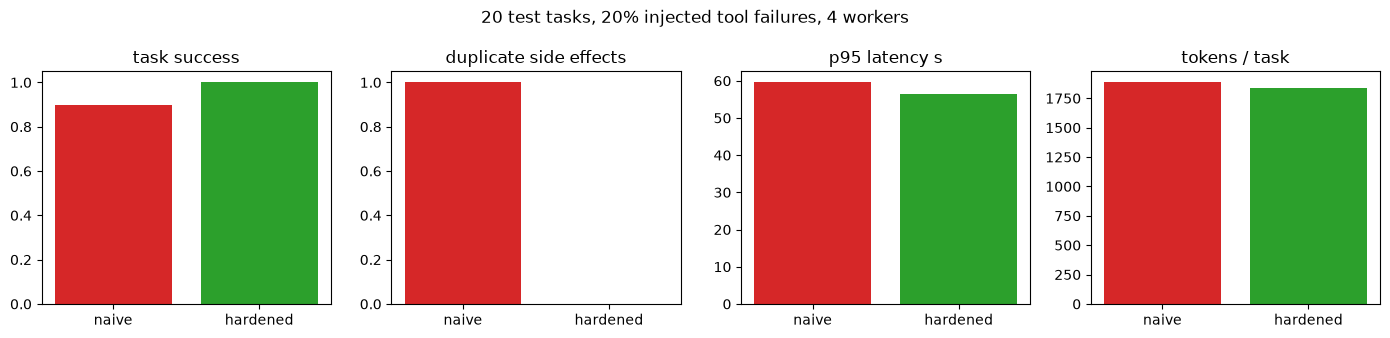

In [79]:
def service_summary(name):
    df, metrics, _, wall = MINI[name]
    low, high = wilson_ci(int(df.success.sum()), len(df))
    costs = [cost_usd(r.prompt_tokens, r.completion_tokens, r.cached_prompt_tokens) for r in df.itertuples()]
    return {"task success": df.success.mean(), "success 95% CI": f"[{low:.2f}, {high:.2f}]", "duplicate side effects": int(df.duplicates.sum()),
            "p50 latency s": df.latency_s.quantile(0.5), "p95 latency s": df.latency_s.quantile(0.95),
            "tool failures seen by model / task": df.tool_failures.mean(), "retries absorbed / task": (df.tool_attempts - df.tool_calls).mean(),
            "LLM calls / task": df.llm_calls.mean(), "tokens / task": (df.prompt_tokens + df.completion_tokens).mean(),
            "example cost / task $": float(np.mean(costs)), "budget stops": int(df.stop.fillna("").str.startswith("budget").sum()),
            "throughput tasks/min": len(df) / wall * 60, "LLM calls real / replayed": f"{metrics['llm_real_calls']} / {metrics['llm_replayed_calls']}"}


comparison = pd.DataFrame({name: service_summary(name) for name in SERVICE_VARIANTS})
print(comparison.to_string())
print("\nsuccess by category:\n" + pd.concat([MINI[n][0].assign(service=n) for n in SERVICE_VARIANTS])
      .pivot_table(index="category", columns="service", values="success", aggfunc="mean").round(2).to_string())

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, metric in zip(axes, ["task success", "duplicate side effects", "p95 latency s", "tokens / task"]):
    ax.bar(comparison.columns, comparison.loc[metric].astype(float), color=["tab:red", "tab:green"])
    ax.set_title(metric)
plt.suptitle(f"{len(MINI_TASKS)} test tasks, 20% injected tool failures, 4 workers")
plt.tight_layout()
plt.show()

### Step 6 — SLO report and runbook, from the measured numbers

In [80]:
for name in SERVICE_VARIANTS:
    print(f"── SLO report: {name} service ──")
    print(slo_report(sli_summary(MINI_TM[name], MINI_FRAMES[name])).to_string(index=False))
    print()

naive_s, hard_s = comparison["naive"], comparison["hardened"]
print(f"""RUNBOOK — support-agent service, hardened config {AGENT_CONFIG.config_id()} (thresholds derived from this run)
1. Task success burn: success was {hard_s['task success']:.0%} here vs {naive_s['task success']:.0%} for the naive config under 20% tool failures.
   Page when the 1 h success burn rate exceeds 14.4× the SLO budget; first check tool error rates and recent config changes.
2. Dependency failing: normal retries absorbed ≈ {hard_s['retries absorbed / task']:.2f} per task, failures reaching the model ≈ {hard_s['tool failures seen by model / task']:.2f} per task.
   Ticket if retries absorbed exceed {max(0.5, 2 * hard_s['retries absorbed / task']):.2f}/task for 30 min; page if a circuit breaker stays open > 5 min → fail over or degrade.
3. Duplicate side effects: {hard_s['duplicate side effects']} with the hardened config vs {naive_s['duplicate side effects']} naive. Any duplicate is a page:
   freeze refunds (kill switch), reconcile the ledger by idempotency key, check executor version.
4. Latency: p95 {hard_s['p95 latency s']:.1f}s for a burst of {len(MINI_TASKS)} tasks on 2 LLM slots. Alert on p95 > {1.5 * hard_s['p95 latency s']:.0f}s; check queue depth and LLM in-flight in /metrics.
5. Cost: {hard_s['tokens / task']:,.0f} tokens and ${hard_s['example cost / task $']:.4f} per task at example prices. Alert at 2× that per hour;
   budget stops this run: {hard_s['budget stops']}.""")

notebook_llm_calls = sum(c.real_calls for c in LLM_CLIENTS)
service_llm_calls = DEMO_SERVICE_LLM_CALLS + sum(MINI[n][1]["llm_real_calls"] for n in SERVICE_VARIANTS)
print(f"\nLLM calls sent to the server in this notebook run: {notebook_llm_calls + AUTOLOG_CALLS + service_llm_calls} "
      f"(notebook {notebook_llm_calls}, MLflow autolog {AUTOLOG_CALLS}, services {service_llm_calls}); "
      f"replayed from the cache: {sum(c.replayed_calls for c in LLM_CLIENTS) + sum(MINI[n][1]['llm_replayed_calls'] for n in SERVICE_VARIANTS) + demo_metrics['llm_replayed_calls']} "
      f"| notebook wall time so far: {(time.perf_counter() - NOTEBOOK_START) / 60:.1f} min")

── SLO report: naive service ──
                               SLI   target  measured met
                      success_rate   >= 0.9    0.9000   ✅
                     p95_latency_s  <= 30.0   17.9567   ✅
             p95_ttft_s (LLM call)   <= 5.0    1.7085   ✅
                   tool_error_rate  <= 0.02    0.0968   ❌
                    steps_per_task   <= 4.0    2.5500   ✅
cost_per_task_usd (example prices) <= 0.004    0.0019   ✅

── SLO report: hardened service ──
                               SLI   target  measured met
                      success_rate   >= 0.9    1.0000   ✅
                     p95_latency_s  <= 30.0   14.9395   ✅
             p95_ttft_s (LLM call)   <= 5.0    1.5640   ✅
                   tool_error_rate  <= 0.02    0.0000   ✅
                    steps_per_task   <= 4.0    2.5000   ✅
cost_per_task_usd (example prices) <= 0.004    0.0018   ✅

RUNBOOK — support-agent service, hardened config 24a92ff7dc4c (thresholds derived from this run)
1. Task success burn: 

**Stretch goals**

1. **Kill the service mid-run.** Add a SQLite job table and a LangGraph checkpointer per job, restart the server while jobs run, and show they resume with zero duplicates (Section 5 inside the service).
2. **Provider outage drill.** Point one service at a wrong `LLM_BASE_URL` for 30 s: measure how many jobs fail vs wait, and add a fallback model config.
3. **Open-loop load test with the real model** at a fixed arrival rate, and plot p95 latency vs arrival rate to find the knee.
4. **Per-tenant fairness.** Give each customer a concurrency limit and show one heavy customer can't starve the others.
5. **Send the JSONL spans to a real backend** (Jaeger, Phoenix or Langfuse via an OTLP exporter) and rebuild the dashboard there.

### 🗣️ How to talk about this in an interview

- "I wrapped a tool-using support agent over τ-bench retail data in a FastAPI job service: 202 + job id with idempotent submission, a bounded asyncio queue with 429 backpressure, workers with an LLM concurrency limit, SSE progress events, cancellation, and OpenTelemetry GenAI spans exported to JSONL."
- "Under 20% injected tool failures on 20 held-out tasks, I compared a naive executor with a hardened one (timeouts, transient-only jittered retries, circuit breakers, idempotency keys, token budgets) and measured success, duplicate refunds, p95 latency and cost from traces. The table above has the numbers."
- "The key insight: retries alone raise success but create duplicate side effects when a reply is lost after a commit; idempotency keys make the retries safe, and because the executor absorbs failures, the model's context stays clean."
- "Everything was computed from spans, so the same queries become production dashboards and SLO burn-rate alerts, and I derived the runbook thresholds from the measured baseline."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What changes when you take an agent from a demo to production?**

<details><summary>Show answer</summary>

- **30-second answer:** The loop stays; the wrapper changes. You need observability (traces for every LLM and tool call, tied to config versions), reliability (timeouts, transient-only retries, idempotent side effects, circuit breakers, fallbacks), durability (checkpoints and resume), serving (async jobs, streaming progress, backpressure), cost control (accounting, routing, caching, budgets), safe releases (eval gates, canaries, rollback) and operations (SLOs, alerts, runbooks, escalation, data retention).
- **Go deeper:** Quote a failure mode you measured: a lost reply after a committed refund plus a retry produced a duplicate refund; 30% tool faults dropped success from 100% to ~60% without retries. Frame production readiness as a checklist with evidence (tests, dashboards, load-test numbers).
- **❌ Common wrong answer:** "Use a bigger model and add more instructions to the prompt."

</details>

**Q2. What do you trace in an agent, and why?**

<details><summary>Show answer</summary>

- **30-second answer:** One trace per task with spans for the workflow, the agent run, each LLM call (model, settings, input/output/cached tokens, latency, time to first token, finish reason, errors) and each tool call (name, redacted arguments, attempts, errors, idempotency). Put the config/prompt version and a user pseudonym on spans. That lets you debug one bad run, compute SLOs, attribute cost, and compare releases.
- **Go deeper:** Follow OpenTelemetry's GenAI semantic conventions (`invoke_agent`, `chat`, `execute_tool`, `gen_ai.usage.*`; still Development status) so Langfuse, Phoenix, MLflow or Datadog can all read the data. Content capture is opt-in; redact before export (MLflow span processors run client-side); set retention limits. Saved traces become evaluation datasets.
- **❌ Common wrong answer:** "Log the final answer" or "log full prompts forever for debugging."

</details>

**Q3. What metrics and SLOs would you put on an agent?**

<details><summary>Show answer</summary>

- **30-second answer:** Task success rate, p50/p95 end-to-end latency, time to first token/progress, steps and tool calls per task, tool error rate per dependency, escalation rate, cost per task, all sliced by config version and task type. SLOs go on the few users feel (success, p95 latency, TTFT), managed with an error budget and burn-rate alerts.
- **Go deeper:** Compute them from spans, so dashboards and debugging share one source of truth. Percentiles need raw distributions or mergeable histograms; never average percentiles. Success needs a grader: end-state checks where possible, sampled human review or calibrated LLM judges otherwise (see 16/06). Watch escalation rate in both directions: too low can mean unsafe automation.
- **❌ Common wrong answer:** "Average latency and total token count."

</details>

**Q4. Retries vs idempotency: what's the difference and how do they work together?**

<details><summary>Show answer</summary>

- **30-second answer:** Retries recover from *transient* failures (timeouts, 429, 5xx) with capped exponential backoff and jitter. Idempotency makes retries *safe* for side effects: the client sends a stable key, and the server stores key + result atomically with the effect and returns the stored result for repeats. Retries give at-least-once delivery; idempotency makes it effectively once.
- **Go deeper:** Never retry permanent errors (400/401/403/404/422). Retry at one layer only (SDKs already retry). Derive keys from the job + step + canonical arguments, never `uuid4()` per attempt. For a write whose outcome is unknown and has no key, check the outcome or escalate. Measured here: blind retries raised success but produced 6–7 duplicate side effects per 100 tasks at 30% faults; keyed retries produced none.
- **❌ Common wrong answer:** "Idempotency means the function always returns the same output" or "just retry everything three times."

</details>

**Q5. How do you make a long-running agent reliable and resumable?**

<details><summary>Show answer</summary>

- **30-second answer:** Run it as a background job with a durable checkpointer (Postgres/SQLite in LangGraph, or a workflow engine like Temporal, DBOS or Inngest) that persists state after every step; on a crash, a new worker resumes the thread from the last checkpoint. Because the in-flight step re-runs, make every side-effecting step idempotent. Add job deadlines, heartbeats/leases for dead workers, and progress events.
- **Go deeper:** In the notebook's kill test, a checkpointer without keys still duplicated the refund that was in flight; keys without a checkpointer avoided duplicates but redid all finished work (re-paying LLM calls); both together gave zero duplicates and one re-executed step. `durability="exit"` saves nothing on a SIGKILL. Temporal replays deterministic workflow code from an event history and retries activities; DBOS commits step checkpoints in Postgres transactions.
- **❌ Common wrong answer:** "Wrap the whole run in try/except and restart from the beginning."

</details>

**Q6. How do you control agent cost?**

<details><summary>Show answer</summary>

- **30-second answer:** Measure tokens per step and task by config; cut work with routing/cascades; keep stable prompt prefixes for prompt caching; cache exact responses for read-only requests (with config id and data version in the key); trim context and tool outputs; enforce per-task and per-user budgets with clean stops; alert on cost per task.
- **Go deeper:** Input tokens dominate because each step re-sends history, so fewer steps and cached prefixes matter most; reasoning tokens bill as output, so effort settings are a lever. Semantic caching is risky: entities like order ids barely move embeddings (measured here), so put entities in the key. Always report savings together with success rates on the same task set.
- **❌ Common wrong answer:** "Switch everything to the cheapest model" without measuring quality.

</details>

**Q7. What are model routing and cascades, and what can go wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Routing picks a model/path per request up front (classifier or rules); a cascade tries a cheap tier first and escalates when a confidence signal fails. Both send most traffic to cheap paths and reserve expensive models for hard cases (FrugalGPT, RouteLLM).
- **Go deeper:** Confidence signals must be observable at run time: validation failures, tool errors, low classifier probability, self-consistency disagreement, not the ground truth. Risks: overconfident cheap tiers that never escalate (quality drops silently), double cost for escalated requests, latency added by the failed tier, and router drift. Evaluate per-tier accuracy and escalation rate on labelled data, and monitor the route mix.
- **❌ Common wrong answer:** "Ask the cheap model whether it is confident."

</details>

**Q8. How do you stream progress to users for a long-running agent?**

<details><summary>Show answer</summary>

- **30-second answer:** Accept the task as a job (202 + job id, idempotent submission), run it on workers, and publish typed progress events (step started, tool called, partial answer, done) over Server-Sent Events with event ids so a reconnecting client resumes with `Last-Event-ID`. Provide `GET /jobs/{id}` for polling and `POST /jobs/{id}/cancel`.
- **Go deeper:** SSE is one-way over plain HTTP and easy to proxy; WebSockets fit two-way chat. Send keep-alive comments, disable proxy buffering, store events so another server instance can serve the stream (Redis/Postgres), and stop work (and token spend) on cancel. Measure time to first progress event as its own SLI.
- **❌ Common wrong answer:** "Keep the HTTP request open until the agent finishes."

</details>

### 💻 Coding

**Q9. Sketch a retry wrapper for tool calls.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  async def call_with_retries(fn, *, deadline, max_attempts=4, base=0.2, cap=2.0, per_call_timeout=2.0):
      for attempt in range(1, max_attempts + 1):
          timeout = min(per_call_timeout, deadline - time.monotonic())
          if timeout <= 0:
              raise TimeoutError("deadline exceeded")
          try:
              return await asyncio.wait_for(fn(), timeout)
          except (TimeoutError, TransientError):
              if attempt == max_attempts:
                  raise
              await asyncio.sleep(random.uniform(0, min(cap, base * 2 ** (attempt - 1))))
  ```
- **Go deeper:** Permanent errors propagate immediately; side-effecting calls pass a stable idempotency key; honour `Retry-After` for 429; add a circuit breaker per dependency; emit retry events on the span. Test with a fake clock and scripted failures, and compare with tenacity (`wait_random_exponential`, `retry_if_exception_type`).
- **❌ Common wrong answer:** `for _ in range(3): try: return fn() except Exception: time.sleep(1)`.

</details>

**Q10. Implement idempotency for a `POST /refunds` endpoint.**

<details><summary>Show answer</summary>

- **30-second answer:** Require an `Idempotency-Key` header. In one database transaction: look the key up; if it exists with the same request hash, return the stored response; with a different hash, return 422; otherwise perform the refund, insert the key with the request hash and response, commit. A unique constraint on the key protects against concurrent duplicates.
- **Go deeper:** Store an "in progress" marker for long operations (return 409 to concurrent retries), expire keys after the retry window, scope keys per customer, and make the downstream payment call idempotent too (pass the key along). The notebook's `run_idempotent` writes the ledger row and the key in one transaction.
- **❌ Common wrong answer:** "Check if a refund exists for this order first" (a race, and it blocks legitimate second refunds).

</details>

### 🐛 Debugging Scenarios

**Q11. p95 latency of your agent tripled overnight. How do you debug it?**

<details><summary>Show answer</summary>

- **30-second answer:** Localize with traces and metrics sliced by time: was there a deploy or config change (config id on spans)? Which span type got slower: queue wait, LLM calls (TTFT vs generation), or a tool? Did steps per task rise (loops, a prompt change) or input tokens grow (context bloat, cache-miss because the prefix changed)? Check traffic volume and LLM in-flight/queue depth for saturation, and provider status.
- **Go deeper:** Compare the slowest traces before and after. TTFT up with the same tokens suggests provider load or lost prompt-cache hits; more `chat` spans per task suggests loops or retries surfacing to the model; tool spans with retry events point at a flaky dependency. Mitigate first (roll back the config, raise concurrency limits only if the model server has headroom, shed load), then fix.
- **❌ Common wrong answer:** "Increase timeouts" or "add more workers" without finding which span got slower.

</details>

**Q12. Cost per task doubled after a release, but success is unchanged. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Group token usage by config id: input vs output vs cached tokens, steps per task, and task mix. Typical causes: a prompt or tool-schema change that breaks the cached prefix (cached share drops), higher reasoning effort or max tokens, a tool returning much larger outputs, more steps (a model looping or re-checking), or a router sending more traffic to the expensive tier.
- **Go deeper:** Replay a fixed task set against both configs to confirm, then fix: restore prefix stability, truncate tool outputs, cap steps and tokens with budgets, add a cost check to the release gate. Add an alert on cost per task so the next spike pages within an hour, not at the monthly invoice.
- **❌ Common wrong answer:** "Traffic must have grown" (that raises total cost, not cost per task).

</details>

### 🏗️ Design

**Q13. Design a service that serves an agent to 10,000 users with long-running tasks (minutes each).**

<details><summary>Show answer</summary>

- **30-second answer:** Stateless API tier accepting jobs (202 + id, idempotency keys, auth, per-tenant rate limits) → durable queue (SQS/Kafka/Redis Streams/Postgres) → autoscaled worker pool running agents with a checkpointer (Postgres) and resilient tool executors → LLM gateway enforcing concurrency, per-tenant quotas, provider fallback and cost accounting → progress events in Redis/Postgres streamed via SSE → traces/metrics to an OTel backend with SLO alerts. Human escalation queue for handoffs.
- **Go deeper:** Capacity: concurrent tasks = arrival rate × duration (10k users × e.g. 0.5 tasks/hour × 3 min ≈ 250 concurrent), each holding LLM concurrency, so the model's throughput is the bottleneck: size LLM slots, use cascades to cut load, and shed or delay low-priority jobs with backpressure. Leases/heartbeats let another worker resume jobs of dead workers. Budgets per task and per tenant; data retention and deletion by user pseudonym.
- **❌ Common wrong answer:** "A FastAPI endpoint that awaits the agent, behind a load balancer with a long timeout."

</details>

**Q14. How do you roll out a new prompt or model safely?**

<details><summary>Show answer</summary>

- **30-second answer:** Version prompt + tools + model + settings as one config id on every span; run an offline eval gate on a labelled task set (block on regressions, cost and latency limits); shadow real traffic with side effects disabled and compare decisions; canary 1–5% of users with sticky hashing and automatic rollback on guardrail metrics (errors, cost, escalations, latency); ramp up; roll back by moving an alias.
- **Go deeper:** A/B tests answer "is it better?" and need a pre-registered metric and power analysis: 85% → 90% success needs roughly 700 tasks per arm. Keep the previous config warm for instant rollback, record config promotions in an audit log, and add the incident's failing tasks to the eval set.
- **❌ Common wrong answer:** "Test it on a few examples and deploy to everyone."

</details>

**Q15. Your LLM provider has an outage. What should your agent service do?**

<details><summary>Show answer</summary>

- **30-second answer:** Detect fast (LLM error-rate and latency burn alerts, circuit breaker opens), stop hammering it (breaker, backoff), fail over to a pre-evaluated secondary model/provider config, degrade gracefully (cached answers, "we'll finish this later" for background jobs, human handoff for urgent cases), keep jobs checkpointed so they resume when it recovers, and communicate status.
- **Go deeper:** Pre-test fallbacks with the same eval gate (a fallback that silently halves quality is its own incident); keep per-provider quotas and timeouts; queue work with deadlines so recovery doesn't trigger a thundering herd (jittered resumes); post-incident, add the scenario to fault-injection tests and the runbook.
- **❌ Common wrong answer:** "Retry until it comes back."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Each answer was verified by running it in this notebook's environment.)

**1.** Full-jitter backoff with `base = 0.5 s` and `cap = 8 s`: what is the *largest* possible wait before retry #5, `min(8.0, 0.5 * 2 ** (5 - 1))`?
<details><summary>Answer</summary>

`8.0` — the uncapped ceiling would also be 8.0 (0.5 × 16); retry #6 would be capped at 8.0 instead of 16.0. Full jitter draws the actual wait uniformly from 0 to that ceiling.
</details>

**2.** A 99.9% availability SLO over 30 days allows how many minutes of complete outage: `round((1 - 0.999) * 30 * 24 * 60, 1)`?
<details><summary>Answer</summary>

`43.2` minutes. That is the whole error budget. A burn rate of 14.4 spends 2% of it (about 52 seconds of full outage) in one hour.
</details>

**3.** A circuit breaker has threshold 3 and cooldown 10 s. Calls fail at t = 0, 1 and 2 s. What happens to a call at t = 5 s, and to one at t = 13 s?
<details><summary>Answer</summary>

At t = 5 s the breaker is **open** (opened at t = 2, only 3 s ago), so the call is rejected immediately without reaching the dependency. At t = 13 s the cooldown has passed (11 s), so the call goes through as the **half-open probe**: success closes the breaker, failure re-opens it.
</details>

**4.** The first refund call loses its reply after committing. The caller retries with a fresh `uuid.uuid4().hex` idempotency key each attempt. How many ledger rows?
<details><summary>Answer</summary>

**2** — each attempt looks like a new request to the provider (⚠️ Pitfall 4 printed it). With a key derived from the job, tool and arguments, it's 1.
</details>

**5.** `json.dumps({"b": 1, "a": 2}, sort_keys=True, separators=(",", ":"))`
<details><summary>Answer</summary>

`'{"a":2,"b":1}'` — canonical JSON: sorted keys, no spaces. It's what makes idempotency keys, fault draws and repeated-action detection independent of key order.
</details>

## 📚 Resources

### 📖 Official Docs
- [GitHub — open-telemetry/semantic-conventions-genai: gen-ai-spans.md](https://github.com/open-telemetry/semantic-conventions-genai/blob/main/docs/gen-ai/gen-ai-spans.md) — span names, kinds and attributes for inference and tool spans (Development status)
- [GitHub — open-telemetry/semantic-conventions-genai: gen-ai-agent-spans.md](https://github.com/open-telemetry/semantic-conventions-genai/blob/main/docs/gen-ai/gen-ai-agent-spans.md) — `invoke_agent` and `invoke_workflow` spans
- [OpenTelemetry Blog — Inside the LLM Call: GenAI Observability with OpenTelemetry](https://opentelemetry.io/blog/2026/genai-observability/) — the conventions in practice
- [OpenTelemetry — Python](https://opentelemetry.io/docs/languages/python/) — SDK, exporters, metrics
- [MLflow — LLM Tracing and Agent Observability](https://mlflow.org/docs/latest/genai/tracing/) — tracing, OpenTelemetry compatibility, UI
- [MLflow — Redacting Sensitive Data from Traces](https://mlflow.org/docs/latest/genai/tracing/observe-with-traces/masking/) — `mlflow.tracing.configure(span_processors=...)`
- [Persistence — Docs by LangChain](https://docs.langchain.com/oss/python/langgraph/persistence) — LangGraph checkpointers, threads, resuming
- [FastAPI — Server-Sent Events (SSE)](https://fastapi.tiangolo.com/tutorial/server-sent-events/) — `EventSourceResponse` and `ServerSentEvent`
- [Temporal — Understanding Temporal](https://docs.temporal.io/evaluate/understanding-temporal) — durable execution with workflows and activities
- [DBOS Docs — Workflows](https://docs.dbos.dev/python/tutorials/workflow-tutorial) — Postgres-backed durable workflows, workflow IDs as idempotency keys
- [Inngest Docs — How Inngest Functions Execute](https://www.inngest.com/docs/learn/how-functions-are-executed) — memoized steps and per-step retries
- [Langfuse — Open Source AI Engineering Platform](https://langfuse.com/docs) · [Arize — What is Arize Phoenix?](https://arize.com/docs/phoenix) · [LangSmith Observability — Docs by LangChain](https://docs.langchain.com/langsmith/observability) — the tracing platforms described in Section 2

### 🎥 Videos
- [AI Engineer — Everything You Need To Know About Agent Observability (Danny Gollapalli & Zubin Koticha, Raindrop)](https://www.youtube.com/watch?v=-aM2EDTiaMs) (~50 min) — what to monitor in production agents, where agents fail silently
- [AI Engineer — OpenAI + Temporal: Building Durable, Production Ready Agents (Cornelia Davis, Temporal)](https://www.youtube.com/watch?v=k8cnVCMYmNc) (~78 min) — a hands-on workshop on durable execution for agents, the Section 5 ideas at scale
- [MLflow — MLflow Tracing: Introduction & Tutorial](https://www.youtube.com/watch?v=X5P-zvGGE0g) (~26 min) — the official walkthrough of MLflow tracing for GenAI apps

### 📄 Papers
- [Yao, Shinn, Razavi & Narasimhan (2024) — τ-bench: A Benchmark for Tool-Agent-User Interaction in Real-World Domains](https://arxiv.org/abs/2406.12045) — the retail data behind this notebook's tasks
- [Chen, Zaharia & Zou (2023) — FrugalGPT: How to Use Large Language Models While Reducing Cost and Improving Performance](https://arxiv.org/abs/2305.05176) — LLM cascades and cost reduction
- [Ong et al. (2024) — RouteLLM: Learning to Route LLMs with Preference Data](https://arxiv.org/abs/2406.18665) — learned routers between strong and weak models

### 📘 Books & Courses
- [Google SRE — Defining SLOs (Site Reliability Engineering book, "Service Level Objectives")](https://sre.google/sre-book/service-level-objectives/) — SLIs, SLOs, error budgets
- [Google SRE — Prometheus Alerting: Turn SLOs into Alerts (SRE Workbook, "Alerting on SLOs")](https://sre.google/workbook/alerting-on-slos/) — the multi-window, multi-burn-rate rules used in Section 9
- [Google SRE — Cascading Failures: Reducing System Outage (SRE book)](https://sre.google/sre-book/addressing-cascading-failures/) — retries, deadlines, load shedding
- [AWS Builder Center — Timeouts, retries, and backoff with jitter (Amazon Builders' Library, Marc Brooker)](https://aws.amazon.com/builders-library/timeouts-retries-and-backoff-with-jitter/) — why retry at one layer, jitter, idempotent APIs
- [AWS Architecture Blog — Exponential Backoff And Jitter](https://aws.amazon.com/blogs/architecture/exponential-backoff-and-jitter/) — the full-jitter analysis
- [Stripe — Designing robust and predictable APIs with idempotency](https://stripe.com/blog/idempotency) — idempotency keys in a real payments API
- [Martin Fowler — Circuit Breaker](https://martinfowler.com/bliki/CircuitBreaker.html) — the pattern, with states and code

### 🏋️ Practice
- [GitHub — sierra-research/tau-bench](https://github.com/sierra-research/tau-bench) — extend the task set (airline domain, multi-turn users) and rerun the fault-injection experiment
- [Google SRE — Prometheus Alerting: Turn SLOs into Alerts](https://sre.google/workbook/alerting-on-slos/) — work through the alerting examples with your own agent's numbers

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Trace / span | the story of one task as timed steps | OTel `TracerProvider` → `SpanProcessor` → exporter; `start_as_current_span` |
| GenAI conventions | shared names for agent telemetry | `invoke_workflow` / `invoke_agent` / `chat {model}` / `execute_tool {tool}`; `gen_ai.usage.*`, `error.type` |
| Content capture | prompts and tool I/O in spans | opt-in, redact before export (`mlflow.tracing.configure(span_processors=[...])`), short retention |
| MLflow tracing | tracing store + UI | `mlflow.start_span`, `@mlflow.trace`, `mlflow.openai.autolog()`, `search_traces`, `delete_traces` |
| SLIs / SLOs | measure what users feel | success, p95 latency, TTFT, steps, tool errors, escalations, cost; error budget; burn-rate alerts (14.4 / 6 / 1) |
| Timeouts | never wait forever | every layer; `min(call cap, deadline − now)` |
| Retries | recover transient failures | transient only, capped exponential backoff + **full jitter**, one layer, within a deadline |
| Idempotency key | effects exactly once | stable key (job + step + canonical args), stored atomically with the effect; conflict → 422 |
| Circuit breaker | stop calling a dead dependency | closed → open (N failures) → half-open probe (after cooldown) → closed/open |
| Fallbacks | degrade, don't break | retry → cached (with age) → other model → human |
| Durable execution | survive crashes | checkpoint per step (`SqliteSaver`, `durability="sync"`), resume the thread, idempotent steps |
| Async job API | serve long tasks | 202 + id, `Idempotency-Key`, queue + workers, `GET /jobs/{id}`, cancel |
| SSE progress | push events | `EventSourceResponse` + `ServerSentEvent(id=…)`, `Last-Event-ID`, keep-alives |
| Backpressure | refuse work you can't do in time | bounded queue → 429 + `Retry-After`; LLM concurrency semaphore |
| Cost control | fewer, cheaper tokens | per-step accounting, cascades, prompt + exact response caching (config id + data version), budgets |
| Rollout | change safely | config id, eval gate, shadow (dry-run), sticky canary + guardrails, A/B power analysis, alias rollback |
| Operations | humans in the loop | escalation tickets with trace ids, feedback linked to traces, runbooks, audit hash chain, deletion by pseudonym |

## ➡️ What's Next

**🎓 This completes the Agentic AI module.** Here is what you can now do:

| # | Notebook | You can now… |
|---|---|---|
| 01 | [Agent Architectures and Workflow Patterns](01_Agent_Architectures_and_Workflow_Patterns.ipynb) | choose between workflows and agents with measured accuracy, cost and latency |
| 02 | [Context Engineering and Agent Memory](02_Context_Engineering_and_Agent_Memory.ipynb) | budget context, compact history, cache prompts, and design memory |
| 03 | [Code Agents, Browser Agents and Computer Use](03_Code_Agents_Browser_Agents_and_Computer_Use.ipynb) | design agent–computer interfaces and sandbox code execution |
| 04 | [Multi-Agent Systems and A2A](04_Multi_Agent_Systems_and_A2A.ipynb) | decide when multiple agents help and connect agents with A2A |
| 05 | [Agent Frameworks Compared](05_Agent_Frameworks_Compared.ipynb) | pick a framework from evidence, not hype |
| 06 | [Agent Evaluation and Benchmarks](06_Agent_Evaluation_and_Benchmarks.ipynb) | evaluate trajectories and outcomes, and gate releases |
| 07 | [Agent Security and Guardrails](07_Agent_Security_and_Guardrails.ipynb) | threat-model agents and measure defenses against injection |
| 08 | **Production Agents: Observability, Reliability, Cost** | trace, harden, serve, budget, roll out and operate agents |

**Practice it:** [Agentic AI System Design](../15_Interview_Prep/08_Agentic_AI_System_Design.ipynb) drills the agent system-design interview round with these building blocks, and [Multi-Agent System Project](../13_Capstone_Projects/05_Multi_Agent_System_Project.ipynb) (coming soon) is a résumé-grade capstone where you ship one end to end.

**Next module → [Generative Models: VAEs, GANs and Diffusion](../17_Multimodal_and_Generative_Models/01_Generative_Models_VAEs_GANs_Diffusion.ipynb)** — you've learned to build, run and operate systems *around* language models; next you'll look inside the other big family of generative models, which create images and audio, and see how VAEs, GANs and diffusion models learn to generate data.